In [3]:
import pandas as pd
import numpy as np
import scipy.stats as stats

import matplotlib.pyplot as plt

import pymc as pm
import arviz as az

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, minmax_scale

from gurobipy import *
import pytensor.tensor as pt

import joblib
from joblib import Parallel, delayed
import multiprocessing as mp
from collections import Counter
import collections
import random
from tqdm import tqdm
from scipy.special import expit

## Utils


In [24]:
# --- 1. PRE-COMPUTATION HELPERS ---
def get_valid_formations():
    """
    Pre-calculates all valid formations (sum to 10 + 1 GK)
    so we don't recalculate them inside the loop.
    """
    valid = []
    def_sizes = [i for i in range(3,6)]
    mid_sizes = [i for i in range(2,5)]
    fwd_sizes = [i for i in range(1,4)]

    for d in def_sizes:
        for m in mid_sizes:
            for f in fwd_sizes:
                if d + m + f == 10:
                    valid.append(np.array([d, m, f]))
    return valid

def calibrate_p_vectors(p_vectors, costs, budget, formation_avg=[1, 4, 4, 2]):
    """
    Adjusts probabilities so the Expected Cost of a team matches the Budget range.
    Handles both Over-Budget (too expensive) and Under-Budget (too cheap) scenarios.
    """
    positions = ['GK', 'DEF', 'MID', 'FWD']
    # formation_avg = formation_avg.tolist()
    # formation_avg = formation_avg.insert(0,1)
    formation_avg = np.insert(formation_avg, 0,1)

    # NEW: Hard limit on the exponent to prevent numerical instability and over-skewing
    MAX_ABS_EXPONENT = 6.0

    # Helper to calculate the current expected cost of a team
    def get_expected_cost(current_p_vectors):
        total_expected_cost = 0
        for i, pos in enumerate(positions):
            # Expected cost = Sum(Probability * Cost) * Number of players in that pos
            pos_expected_val = np.sum(current_p_vectors[pos] * costs[i])
            total_expected_cost += pos_expected_val * formation_avg[i]
        return total_expected_cost

    current_cost = get_expected_cost(p_vectors)
    print(f"📊 Initial Expected Team Cost: {current_cost:.2f} (Budget: {budget})")

    # Define the "Sweet Spot" for acceptance
    # Teams must be > budget_lower_bound (usually 0.9) and < budget (1.0)
    # We target the middle of this range to maximize acceptance.
    TARGET_MIN = budget * 0.94
    TARGET_MAX = budget * 1.01

    if TARGET_MIN <= current_cost <= TARGET_MAX:
        print("✅ Probabilities are already well-calibrated.")
        return p_vectors

    print(f"⚠️ Cost {current_cost} out of optimal range ({TARGET_MIN:.1f}-{TARGET_MAX:.1f}). Calibrating...")

    exponent = 0.0
    # Direction:
    # If cost is too high (e.g. 105), we need positive exponent to punish expensive (1/cost^x)
    # If cost is too low (e.g. 73), we need negative exponent to reward expensive (cost^x)
    direction = 1.0 if current_cost > TARGET_MAX else -1.0
    step_size = 0.1 * direction

    # # --- ADAPTIVE STEP IMPROVEMENT ---
    # TARGET_MID = (TARGET_MIN + TARGET_MAX) / 2.0

    # # Calculate initial step based on relative error from the midpoint
    # relative_error = (current_cost - TARGET_MID) / TARGET_MID

    # # Use a large initial step, clamped between 0.05 and MAX_ABS_EXPONENT
    # initial_step = np.clip(abs(relative_error) * 0.5, 0.05, MAX_ABS_EXPONENT)

    # # Determine direction: 1.0 if too expensive, -1.0 if too cheap
    # direction = 1.0 if current_cost > TARGET_MID else -1.0

    # # Start the exponent at the initial calculated step, moving in the correct direction
    # exponent = initial_step * direction

    # # Use a smaller step size for fine-tuning after the first guess
    # fine_tune_step = 0.05 * direction

    for attempt in range(50):
        exponent += step_size

        # if attempt > 0:
        #     exponent += fine_tune_step

        #  # Check against the new maximum exponent limit
        # if abs(exponent) > MAX_ABS_EXPONENT + abs(fine_tune_step):
        #     print(f"❌ Aborted! Reached max stable exponent of {MAX_ABS_EXPONENT:.2f}. Using last stable distribution.")
        #     break

        new_p_vectors = {}

        for i, pos in enumerate(positions):
            # Safety clamp for costs to prevent math errors
            safe_costs = np.maximum(costs[i], 0.5)

            # Calibration Formula:
            # New_Weight = Old_Weight * (Cost ^ -exponent)
            # Exponent > 0: (1 / Cost^x) -> Reduces weight of expensive players
            # Exponent < 0: (Cost^x)     -> Increases weight of expensive players
            weights = p_vectors[pos] * np.power(safe_costs, -exponent)

            # Normalize
            w_sum = np.sum(weights)
            if w_sum > 0:
                weights /= w_sum
            else:
                weights = np.ones_like(weights) / len(weights)

            new_p_vectors[pos] = weights

        new_cost = get_expected_cost(new_p_vectors)

        # Check if we landed in the zone
        if TARGET_MIN <= new_cost <= TARGET_MAX:
            print(f"✅ Calibrated! Factor: {exponent:.2f} | New Expected Cost: {new_cost:.2f}")
            return new_p_vectors

        # Check if we overshot the target (crossed from low to high or high to low)
        if direction > 0 and new_cost < TARGET_MIN:
             print(f"⚠️ Calibration settling (overshot slightly). Cost: {new_cost:.2f}")
             return new_p_vectors
        if direction < 0 and new_cost > TARGET_MAX:
             print(f"⚠️ Calibration settling (overshot slightly). Cost: {new_cost:.2f}")
             return new_p_vectors

    print(f"⚠️ Max calibration attempts reached. Final Cost: {new_cost:.2f}")
    return new_p_vectors

def calculate_p_vectors(feature_matrices, beta_estimates):
    """
    Calculates p_vectors using the Mean-Field approximation for Alphas.
    """
    print("📊 Calculating raw p_vectors from Beta estimates...")
    p_vectors = {}
    positions = ['GK', 'DEF', 'MID', 'FWD']

    is_dict = isinstance(feature_matrices, dict)

    for i, pos in enumerate(positions):
        if is_dict:
            X = feature_matrices[pos]
        else:
            X = feature_matrices[i]

        beta = beta_estimates[pos]

        # 1. Calculate Alphas: Mean of the exponentiated predictions
        alpha = np.exp(X @ beta.T).mean(axis=1)

        # 2. Sample Dirichlet once to get the base distribution
        try:
            p_vectors[pos] = np.random.dirichlet(alpha)
        except ValueError:
            # Fallback if alphas are too huge/small causing numerical issues
            p_vectors[pos] = alpha / alpha.sum()

    return p_vectors

def is_feasible_fast(portfolio_indices, flat_costs, flat_team_ints, budget, budget_lb):
    """
    Optimized constraint checker.
    """
    # 1. Budget Check (Vectorized sum)
    total_cost = np.sum(flat_costs[portfolio_indices])
    # print(portfolio_indices)
    print('costs: ', flat_costs[portfolio_indices], 'total_cost: ', total_cost)

    if total_cost > budget or total_cost < budget_lb:
        return False

    # 2. Team Count Check (Max 3 players per team)
    selected_teams = flat_team_ints[portfolio_indices]
    team_counts = np.bincount(selected_teams, minlength=50)

    if np.any(team_counts > 3):
        return False

    return True

def generate_batch_optimized(
    n_samples,
    flat_costs,
    flat_team_ints,
    pos_offsets,
    pos_counts,
    xp_preds_dict,
    pos_teams_dict,
    q,
    budget,
    budget_lb,
    xp_threshold ,
    beta_estimates, feature_matrices, costs,
    p_vectors=None,
):

    # Inside generate_batch_optimized, at the very top
    if np.random.rand() < 0.001: # Print only occasionally
        print(f"DEBUG WORKER: Budget={budget}, LB={budget_lb}, Cost_Sample={flat_costs[0]}")

    """
    Generates a BATCH of teams locally.
    """

    # Helper for numerical stability check before np.random.choice
    def safe_normalize_p_vector(p_vec):
        # 1. Ensure all values are non-negative
        p_vec = np.maximum(p_vec, 0)
        # 2. Check sum and normalize
        p_sum = np.sum(p_vec)
        if p_sum == 0:
            # Fallback to uniform distribution if sum is zero
            return np.ones_like(p_vec) / len(p_vec)
        return p_vec / p_sum

    for _ in range(n_samples):
        # --- Formation ---
        VALID_FORMATIONS = get_valid_formations()
        valid_batch_indices = []
        form_idx = np.random.randint(len(VALID_FORMATIONS))
        formation = VALID_FORMATIONS[form_idx]


        # --- 1. PROBABILITY CALCULATION & CALIBRATION ---
        if p_vectors is None:
            print('Starting to Calibrate: ............ probs')
            # 1. Calculate Base Probabilities (Statistical Model)
            p_vectors = calculate_p_vectors(feature_matrices, beta_estimates)

            # 2. Calibrate for Budget (Feasibility Optimization)
            # We pass the cost arrays for each position [cost_gk, cost_def, cost_mid, cost_fwd]
            p_vectors = calibrate_p_vectors(p_vectors, costs, budget, formation)


            # print(p_vectors)

        # --- SELECTION ---
        # sel_gk = np.random.choice(pos_counts['GK'], 1, replace=False, p=p_vectors['GK'])
        # sel_def = np.random.choice(pos_counts['DEF'], formation[0], replace=False, p=p_vectors['DEF'])
        # sel_mid = np.random.choice(pos_counts['MID'], formation[1], replace=False, p=p_vectors['MID'])
        # sel_fwd = np.random.choice(pos_counts['FWD'], formation[2], replace=False, p=p_vectors['FWD'])

         # --- Random Player Selection using Calibrated Probabilities (with stability guard) ---
        try:
            p_gk = safe_normalize_p_vector(p_vectors['GK'])
            sel_gk = np.random.choice(pos_counts['GK'], 1, replace=False, p=p_gk)

            p_def = safe_normalize_p_vector(p_vectors['DEF'])
            sel_def = np.random.choice(pos_counts['DEF'], formation[0], replace=False, p=p_def)

            # p_mid = safe_normalize_p_vector(p_vectors['MID'])
            # sel_mid = np.random.choice(pos_counts['MID'], formation[1], replace=False, p=p_mid)

            # p_fwd = safe_normalize_p_vector(p_vectors['FWD'])
            # sel_fwd = np.random.choice(pos_counts['FWD'], formation[2], replace=False, p=p_fwd)

            # --- FWD STAR PLAYER HEURISTIC ---
            p_fwd = safe_normalize_p_vector(p_vectors['FWD'])
            fwd_slots = formation[2]

            # print('[[[[[[[[[[[[[[[[[[[[[[[',prices,  flat_costs)
            print(formation)

            costs_fwd = prices[3]
            # Identify high-cost FWD players (Top 10% cost)
            fwd_cost_threshold = np.percentile(costs_fwd, 90)

            # Filter for star players who also have high probability (value)
            star_fwd_indices = np.where(
                (p_fwd > p_fwd.mean()) & (costs_fwd >= fwd_cost_threshold)
            )[0]

            star_fwd = np.array([], dtype=int)
            remaining_fwd_slots = fwd_slots

            if fwd_slots > 0 and len(star_fwd_indices) > 0:
                # Force selection of one FWD star player
                star_fwd = np.random.choice(star_fwd_indices, 1, replace=False)
                remaining_fwd_slots -= 1

                # Exclude the selected star from the remaining pool
                remaining_pool = np.setdiff1d(np.arange(pos_counts['FWD']), star_fwd)
            else:
                remaining_pool = np.arange(pos_counts['FWD'])

            # Sample remaining FWDs from the non-star pool using calibrated probs
            if remaining_fwd_slots > 0 and len(remaining_pool) > 0:
                remaining_p_fwd = safe_normalize_p_vector(p_vectors['FWD'][remaining_pool])
                sel_fwd_rem = np.random.choice(
                    remaining_pool,
                    remaining_fwd_slots,
                    replace=False,
                    p=remaining_p_fwd
                )
                sel_fwd = np.concatenate([star_fwd, sel_fwd_rem])
            else:
                sel_fwd = star_fwd

            # --- MID STAR PLAYER HEURISTIC ---
            p_mid = safe_normalize_p_vector(p_vectors['MID'])
            mid_slots = formation[1]
            costs_mid = prices[2]
            mid_cost_threshold = np.percentile(costs_mid, 90)
            star_mid_indices = np.where(
                (p_mid > p_mid.mean()) & (costs_mid >= mid_cost_threshold)
            )[0]

            star_mid = np.array([], dtype=int)
            remaining_mid_slots = mid_slots

            if mid_slots > 0 and len(star_mid_indices) > 0:
                # Force selection of one MID star player
                star_mid = np.random.choice(star_mid_indices, 1, replace=False)
                remaining_mid_slots -= 1

                # Exclude the selected star from the remaining pool
                remaining_pool = np.setdiff1d(np.arange(pos_counts['MID']), star_mid)
            else:
                remaining_pool = np.arange(pos_counts['MID'])

            # Sample remaining MIDs from the non-star pool using calibrated probs
            if remaining_mid_slots > 0 and len(remaining_pool) > 0:
                remaining_p_mid = safe_normalize_p_vector(p_vectors['MID'][remaining_pool])
                sel_mid_rem = np.random.choice(
                    remaining_pool,
                    remaining_mid_slots,
                    replace=False,
                    p=remaining_p_mid
                )
                sel_mid = np.concatenate([star_mid, sel_mid_rem])
            else:
                sel_mid = star_mid

            # Check if selection sizes match formation slots (important if star selection failed, or player pools are too small)
            if len(sel_mid) != mid_slots or len(sel_fwd) != fwd_slots:
                # Fallback to pure probabilistic if heuristic resulted in incorrect counts
                p_mid = safe_normalize_p_vector(p_vectors['MID'])
                sel_mid = np.random.choice(pos_counts['MID'], formation[1], replace=False, p=p_mid)
                p_fwd = safe_normalize_p_vector(p_vectors['FWD'])
                sel_fwd = np.random.choice(pos_counts['FWD'], formation[2], replace=False, p=p_fwd)
        except ValueError as e:
            # If the safe normalization fails (e.g., player count too low for formation slot)
            print(f"Sampling Error: {e}. Skipping sample.")
            continue

        # --- STACKING LOGIC ---
        is_stacker = np.random.binomial(1, q) == 1


        if is_stacker:
            # FWD-MID Stack
            if len(sel_fwd) > 0 and len(sel_mid) > 0:
                fwd_vals = xp_preds_dict['FWD'][sel_fwd]
                best_fwd_local_idx = sel_fwd[np.argmax(fwd_vals)]

                if xp_preds_dict['FWD'][best_fwd_local_idx] >= xp_threshold:
                    anchor_team = pos_teams_dict['FWD'][best_fwd_local_idx]

                    all_mids = np.arange(pos_counts['MID'])
                    team_mask = (pos_teams_dict['MID'] == anchor_team)
                    selected_mask = np.zeros(pos_counts['MID'], dtype=bool)
                    selected_mask[sel_mid] = True

                    avail_mask = team_mask & (~selected_mask)
                    available_indices = all_mids[avail_mask]

                    if len(available_indices) > 0:
                        teammate_probs = p_vectors['MID'][available_indices]
                        prob_sum = np.sum(teammate_probs)
                        if prob_sum > 0:
                            norm_probs = teammate_probs / prob_sum
                            chosen_teammate = np.random.choice(available_indices, size=1, p=norm_probs)[0]
                            mid_vals = xp_preds_dict['MID'][sel_mid]
                            worst_idx_rel = np.argmin(mid_vals)
                            sel_mid[worst_idx_rel] = chosen_teammate

            # DEF-GK Stack
            if len(sel_def) > 0:
                def_vals = xp_preds_dict['DEF'][sel_def]
                best_def_local_idx = sel_def[np.argmax(def_vals)]

                if xp_preds_dict['DEF'][best_def_local_idx] >= xp_threshold:
                    anchor_team = pos_teams_dict['DEF'][best_def_local_idx]

                    all_gks = np.arange(pos_counts['GK'])
                    team_mask = (pos_teams_dict['GK'] == anchor_team)
                    if pos_teams_dict['GK'][sel_gk[0]] != anchor_team:
                         avail_mask = team_mask
                    else:
                         avail_mask = np.zeros(pos_counts['GK'], dtype=bool)

                    available_indices = all_gks[avail_mask]

                    if len(available_indices) > 0:
                        teammate_probs = p_vectors['GK'][available_indices]
                        prob_sum = np.sum(teammate_probs)
                        if prob_sum > 0:
                            norm_probs = teammate_probs / prob_sum
                            chosen_gk = np.random.choice(available_indices, size=1, p=norm_probs)[0]
                            sel_gk[0] = chosen_gk


        # --- GLOBAL INDEX MAPPING ---
        global_gk = sel_gk + pos_offsets['GK']
        global_def = sel_def + pos_offsets['DEF']
        global_mid = sel_mid + pos_offsets['MID']
        global_fwd = sel_fwd + pos_offsets['FWD']

        candidate_indices = np.concatenate([global_gk, global_def, global_mid, global_fwd])
        # print(candidate_indices)
        # --- FEASIBILITY CHECK ---
        if is_feasible_fast(candidate_indices, flat_costs, flat_team_ints, budget, budget_lb):
            print('is_feasible')
            # We store indices directly in the list
            candidate_indices.sort() # Sort for easier uniqueness checking later
            valid_batch_indices.append(candidate_indices)

    return valid_batch_indices

def sample_opponent_portfolios_optimized(
    O, batch_size, beta_estimates, feature_matrices, ids, costs, budget, teams, xp_preds,
    p_vectors=None,
    q=0.35, Blb_ratio=0.9
):
    print(f"\n🚀 Preparing Optimized Data Structures (Batch Mode)...")

    # --- 2. DATA FLATTENING ---
    flat_costs = players_preds['value'].values # np.concatenate(costs)

    total_num_players = len(flat_costs)

    flat_teams_str = np.concatenate(teams)
    unique_teams, flat_team_ints = np.unique(flat_teams_str, return_inverse=True)

    lengths = [len(sub) for sub in ids]
    offsets_arr = np.cumsum([0] + lengths[:-1])

    pos_offsets = {
        'GK': offsets_arr[0], 'DEF': offsets_arr[1],
        'MID': offsets_arr[2], 'FWD': offsets_arr[3]
    }
    pos_counts = {
        'GK': lengths[0], 'DEF': lengths[1],
        'MID': lengths[2], 'FWD': lengths[3]
    }
    xp_preds_dict = {
        'GK': np.array(xp_preds[0]), 'DEF': np.array(xp_preds[1]),
        'MID': np.array(xp_preds[2]), 'FWD': np.array(xp_preds[3])
    }
    pos_teams_dict = {
        'GK': np.array(teams[0]), 'DEF': np.array(teams[1]),
        'MID': np.array(teams[2]), 'FWD': np.array(teams[3])
    }

    all_xp = np.concatenate([x for x in xp_preds_dict.values()])
    xp_threshold = np.percentile(all_xp, 75)
    budget_lower_bound = budget * Blb_ratio

    n_cores = mp.cpu_count()
    print(f"⚙️ Using {n_cores} cores. Target: {O} unique portfolios.")

    teams_per_core_call = max(50, batch_size // n_cores)

    # --- 3. GENERATION LOOP ---
    portfolios = set()
    attempts = 0

    while len(portfolios) < O:
        needed = O - len(portfolios)
        # Since calibration is now active, rejection should be low.
        # We can request closer to the actual number needed.
        target_attempts = int(needed * 1.5) + 50

        n_tasks = max(n_cores, target_attempts // teams_per_core_call)
        n_tasks = min(n_tasks, n_cores * 4)

        samples_per_task = max(50, target_attempts // n_tasks)

        results_batches  = generate_batch_optimized(
                samples_per_task,
                flat_costs,
                flat_team_ints,
                pos_offsets,
                pos_counts,
                # p_vectors,
                xp_preds_dict,
                pos_teams_dict,
                q,
                budget,
                budget_lower_bound,
                xp_threshold,
                beta_estimates, feature_matrices, costs
            )

        print('==============', results_batches)

        # results_batches = Parallel(n_jobs=-1)(
        #     delayed(generate_batch_optimized)(
        #         samples_per_task,
        #         flat_costs,
        #         flat_team_ints,
        #         pos_offsets,
        #         pos_counts,
        #         # p_vectors,
        #         xp_preds_dict,
        #         pos_teams_dict,
        #         q,
        #         budget,
        #         budget_lower_bound,
        #         xp_threshold,
        #         beta_estimates, feature_matrices, costs
        #     )
        #     for _ in range(n_tasks)
        # )



        # for batch in results_batches:
        #     print(batch)
        for team_indices in results_batches: #batch:
            print(team_indices)
            tup = tuple(team_indices)
            if tup not in portfolios:
                portfolios.add(tup)
                if len(portfolios) >= O:
                    break
            if len(portfolios) >= O:
                break

        attempts += (n_tasks * samples_per_task)
        print('New attempt')

        # Progress bar
        if len(portfolios) > 0:
             print(f"   ...Valid teams: {len(portfolios)}/{O} (Rejection Rate: {1.0 - (len(portfolios)/attempts):.1%})")

    print(f"✅ Done! Generated {len(portfolios)} unique portfolios.")

    # --- 4. OUTPUT ---
    final_output = []
    for indices_tuple in portfolios:
        arr = np.zeros(total_num_players, dtype=int)
        arr[list(indices_tuple)] = 1
        final_output.append(arr)

    return final_output

In [25]:
def clean_data(players_preds, valid_player_ids):
    print('starting to clean data...')
    players_preds = players_preds[players_preds['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)

    # Adding new features
    players_preds['gw'] = players_preds['event']
    players_preds['team'] = players_preds['player_team']
    players_preds['opponent_team'] = players_preds.apply(lambda row: row['a_team'] if row['was_home'] == 1 else row['h_team'], axis=1)
    players_preds[['h_team', 'a_team', 'was_home', 'team', 'opponent_team', 'player_team', 'gw', 'event']]

    gk_data = players_preds[players_preds['position'] == 'GK'][feats_cols_gk] #[data_cols_gk]
    def_data = players_preds[players_preds['position'] == 'DEF'][feats_cols_def]#[data_cols]
    mid_data = players_preds[players_preds['position'] == 'MID'][feats_cols_mid].dropna()#[data_cols]
    fwd_data = players_preds[players_preds['position'] == 'FWD'][feats_cols_fwd].dropna()#[data_cols]


    data = [gk_data, def_data, mid_data, fwd_data]

    gk_data = gk_data.dropna()
    def_data = def_data.dropna()
    mid_data = mid_data.dropna()
    fwd_data = fwd_data.dropna()

    gk_names = gk_data['fpl_name']
    def_names = def_data['fpl_name']
    mid_names = mid_data['fpl_name']
    fwd_names = fwd_data['fpl_name']

    gk_data.drop(columns=['fpl_name'], inplace=True)
    def_data.drop(columns=['fpl_name'], inplace=True)
    mid_data.drop(columns=['fpl_name'], inplace=True)
    fwd_data.drop(columns=['fpl_name'], inplace=True)

    names = [gk_names, def_names, mid_names, fwd_names]


    # GK
    gk_data['transfers_in_log'] = gk_data['transfers_in'].apply(lambda x: np.log(x + 1))
    gk_data['transfers_out_log'] = gk_data['transfers_out'].apply(lambda x: np.log(x + 1))

    # xg_times_transfers = xG_5 * transfers_in
    gk_data['saves_times_transfers'] = gk_data['saves_5_ewm'] * gk_data['transfers_in_log']
    # points1_times_transfers = 'pts_bps_1 * transfers_in
    gk_data['points1_times_transfers'] = gk_data['pts_bps_5_ewm'] * gk_data['transfers_in_log']
    gk_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)


    # DEF data
    def_data['transfers_in_log'] = def_data['transfers_in'].apply(lambda x: np.log(x + 1))
    def_data['transfers_out_log'] = def_data['transfers_out'].apply(lambda x: np.log(x + 1))

    # xg_times_transfers = xA_5 * transfers_in
    def_data['xa_times_transfers'] = def_data['xA_5_ewm'] * def_data['transfers_in_log']
    # points1_times_transfers = 'pts_bps_1 * transfers_in
    def_data['points1_times_transfers'] = def_data['pts_bps_5_ewm'] * def_data['transfers_in_log']
    def_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)


    # MID data
    mid_data['transfers_in_log'] = mid_data['transfers_in'].apply(lambda x: np.log(x + 1))
    mid_data['transfers_out_log'] = mid_data['transfers_out'].apply(lambda x: np.log(x + 1))

    # xg_times_transfers = xG_5 * transfers_in
    mid_data['npxg_times_transfers'] = mid_data['npxG_5_ewm'] * mid_data['transfers_in_log']
    # points1_times_transfers = pts_bps_5_ewm * transfers_in
    mid_data['points1_times_transfers'] = mid_data['pts_bps_5_ewm'] * mid_data['transfers_in_log']
    mid_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)


    # FWD data
    fwd_data['transfers_in_log'] = fwd_data['transfers_in'].apply(lambda x: np.log(x + 1))
    fwd_data['transfers_out_log'] = fwd_data['transfers_out'].apply(lambda x: np.log(x + 1))

    # xg_times_transfers = xG_5 * transfers_in
    fwd_data['npxg_times_transfers'] = fwd_data['npxG_5_ewm'] * fwd_data['transfers_in_log']
    # points1_times_transfers = pts_bps_5_ewm * transfers_in
    fwd_data['points1_times_transfers'] = fwd_data['pts_bps_5_ewm'] * fwd_data['transfers_in_log']
    fwd_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)



    # Get attributes
    g_prices = gk_data['value'].tolist() #*10
    d_prices = def_data['value'].tolist() #*10
    m_prices = mid_data['value'].tolist() #*10
    f_prices = fwd_data['value'].tolist() #*10
    prices = [g_prices, d_prices, m_prices, f_prices]
    # print(g_prices, len(d_prices), len(m_prices), len(f_prices))
    # print(len(g_prices), len(d_prices), len(m_prices), len(f_prices))

    g_xPts = players_preds[players_preds['position'] == 'GK']['xP_pred'].tolist()
    d_xPts = players_preds[players_preds['position'] == 'DEF']['xP_pred'].tolist()
    m_xPts = players_preds[players_preds['position'] == 'MID']['xP_pred'].tolist()
    f_xPts = players_preds[players_preds['position'] == 'FWD']['xP_pred'].tolist()
    xPts = [g_xPts, d_xPts, m_xPts, f_xPts]

    g_teams = players_preds[players_preds['position'] == 'GK']['player_team'].tolist()
    d_teams = players_preds[players_preds['position'] == 'DEF']['player_team'].tolist()
    m_teams = players_preds[players_preds['position'] == 'MID']['player_team'].tolist()
    f_teams = players_preds[players_preds['position'] == 'FWD']['player_team'].tolist()
    teams = [g_teams, d_teams, m_teams, f_teams]

    g_positions = players_preds[players_preds['position'] == 'GK']['position'].tolist()
    d_positions = players_preds[players_preds['position'] == 'DEF']['position'].tolist()
    m_positions = players_preds[players_preds['position'] == 'MID']['position'].tolist()
    f_positions = players_preds[players_preds['position'] == 'FWD']['position'].tolist()
    positions = [g_positions, d_positions, m_positions, f_positions]

    # g_ids = players_preds[players_preds['position'] == 'GK']['FPL_ID'].tolist()
    # d_ids = players_preds[players_preds['position'] == 'DEF']['FPL_ID'].tolist()
    # m_ids = players_preds[players_preds['position'] == 'MID']['FPL_ID'].tolist()
    # f_ids = players_preds[players_preds['position'] == 'FWD']['FPL_ID'].tolist()

    g_ids = players_preds.index[players_preds['position']=='GK'].tolist()
    d_ids = players_preds.index[players_preds['position']=='DEF'].tolist()
    m_ids = players_preds.index[players_preds['position']=='MID'].tolist()
    f_ids = players_preds.index[players_preds['position']=='FWD'].tolist()

    ids = [g_ids, d_ids, m_ids, f_ids]

    gk_data = gk_data.select_dtypes(include=[np.number])
    gk_data = pd.DataFrame(minmax_scale(gk_data), columns=gk_data.columns, index=gk_data.index)

    def_data = def_data.select_dtypes(include=[np.number])
    def_data = pd.DataFrame(minmax_scale(def_data), columns=def_data.columns, index=def_data.index)

    mid_data = mid_data.select_dtypes(include=[np.number])
    mid_data = pd.DataFrame(minmax_scale(mid_data), columns=mid_data.columns, index=mid_data.index)

    fwd_data = fwd_data.select_dtypes(include=[np.number])
    fwd_data = pd.DataFrame(minmax_scale(fwd_data), columns=fwd_data.columns, index=fwd_data.index)

    # Selection percentages
    gk_select_by = gk_data['selected_by_percent']
    def_select_by = def_data['selected_by_percent']
    mid_select_by = mid_data['selected_by_percent']
    fwd_select_by = fwd_data['selected_by_percent']

    gk_data = gk_data.drop(columns='selected_by_percent')
    def_data = def_data.drop(columns='selected_by_percent')
    mid_data = mid_data.drop(columns='selected_by_percent')
    fwd_data = fwd_data.drop(columns='selected_by_percent')



    # Normalise the select_percts to get the working probs
    gk_probs = gk_select_by/np.sum(gk_select_by)
    def_probs = def_select_by/np.sum(def_select_by)
    mid_probs = mid_select_by/np.sum(mid_select_by)
    fwd_probs = fwd_select_by/np.sum(fwd_select_by)



    # 1. Define a small constant (epsilon) to replace the zeros
    epsilon = 1e-9 # A very small number

    # 2. Replace all zeros with this small number
    gk_probs[gk_probs == 0] = epsilon
    def_probs[def_probs == 0] = epsilon
    mid_probs[mid_probs == 0] = epsilon
    fwd_probs[fwd_probs == 0] = epsilon

    probs = [gk_probs, def_probs, mid_probs, fwd_probs]


    # print(gk_data.shape)

    X_gk = pd.DataFrame(scaler_gk.transform(gk_data.values), columns=gk_data.columns)
    X_def = pd.DataFrame(scaler_def.transform(def_data.values), columns=def_data.columns)
    X_mid = pd.DataFrame(scaler_mid.transform(mid_data.values), columns=mid_data.columns)
    X_fwd = pd.DataFrame(scaler_fwd.transform(fwd_data.values), columns=fwd_data.columns)

    # print(X_mid.columns)

    # # 3. Fit PCA and transform
    # X_gk_pca = pd.DataFrame(pca_gk.transform(X_gk))
    # X_def_pca = pd.DataFrame(pca_def.transform(X_def))
    # X_mid_pca = pd.DataFrame(pca_mid.transform(X_mid))
    # X_fwd_pca = pd.DataFrame(pca_fwd.transform(X_fwd))

    X = [X_gk, X_def, X_mid, X_fwd]

    print('data successfully cleaned...')

    return data, prices, xPts, positions ,teams, ids, X, names, probs

def generate_probs(X_pca, betas):
    print('starting to generate selction probabilities')
    def safe_alpha(X_pca, beta):
        raw_scores = pm.math.dot(X_pca, beta.T)
        raw_scores -= pm.math.max(raw_scores)
        alpha = pm.math.exp(raw_scores) + 1e-3
        alpha = pm.math.clip(alpha, 1e-3, 1e3)
        return alpha


    alpha_g = safe_alpha(X_pca[0], betas[0].T)
    alpha_d = safe_alpha(X_pca[1], betas[1].T)
    alpha_m = safe_alpha(X_pca[2], betas[2].T)
    alpha_f = safe_alpha(X_pca[3], betas[3].T)

    with pm.Model():
        pg = pm.Dirichlet("pg", a=alpha_g)  # Ensure correct shape
        pd_ = pm.Dirichlet("pd_", a=alpha_d)  # Ensure correct shape
        pmid = pm.Dirichlet("pm", a=alpha_m)  # Ensure correct shape
        pf = pm.Dirichlet("pf", a=alpha_f)  # Ensure correct shape

        trace = pm.sample()

    # Extract posterior means
    pgk, pdef, pmid, pfwd = (
        trace.posterior["pg"].mean(dim=("chain", "draw")).values,
        trace.posterior["pd_"].mean(dim=("chain", "draw")).values,
        trace.posterior["pm"].mean(dim=("chain", "draw")).values,
        trace.posterior["pf"].mean(dim=("chain", "draw")).values)

    return pgk, pdef, pmid, pfwd

def is_feasible(portfolio, budget, budget_lower_bound, costs, teams):
    """
    Placeholder function to check if a portfolio is feasible.
    [span_6](start_span)[span_7](start_span)This checks the budget constraint and other linear constraints represented by W[span_6](end_span)[span_7](end_span).
    In a real scenario, this would include checks for positional limits (e.g., exactly 1 QB).
    """
    costs_ = []
    for sublist in costs:
        costs_.extend(sublist)

    costs = costs_
    # print(portfolio, costs)
    total_cost = np.dot(portfolio, costs)
    print('*************', total_cost)

    # teams = pd.concat(teams).values
    # print(teams)
    if total_cost > budget or total_cost < budget_lower_bound:
        return False
    # Add other positional/diversity constraint checks here
    print(total_cost, budget_lower_bound)

    # --- Max 3 players per team ---
    team_counts = {}
    teams_ = []
    for sublist in teams:
        teams_.extend(sublist)

    teams = teams_

    team_idx = [idx for idx, _ in enumerate(portfolio) if portfolio[idx] == 1]
    selected_teams = [teams[i] for i in team_idx]

    if any(team >3 for team in Counter(selected_teams).values()):
        return False
    print(total_cost)
    return True

def get_random_fpl_formation():
    """
    Generates all valid 11-player FPL formations and returns one at random.
    """
    def_sizes = [3, 4, 5]
    mid_sizes = [2, 3, 4, 5]
    fwd_sizes = [1, 2, 3]

    valid_formations = []

    # Iterate through all combinations to find those that sum to 10 (plus 1 GK)
    for def_ in def_sizes:
        for mid in mid_sizes:
            for fwd in fwd_sizes:
                if def_ + mid + fwd == 10:
                    valid_formations.append([def_, mid, fwd])

    # Return a single random choice from the list
    return random.choice(valid_formations)

def generate_one_team(ids, beta_estimates, num_dirichlet_samples, p_vectors, positional_teams, q, xp_pred, costs, budget, Blb_ratio, total_num_players, teams, temperature=0.3):
    """
    Generates a single FPL team using Bayesian sampled p_vectors and
    FPL-specific formation and stacking rules.

    Args:
        ids (list of lists): Global player indices from the DataFrame,
                             grouped as [gk_ids, def_ids, mid_ids, fwd_ids].
        beta_estimates (dict): MCMC traces for each position.
        p_vectors (dict): Dirichlet sampled probability vectors for each position.
        positional_teams (dict): Team IDs for players in each position group.
        q (float): Probability that this opponent is a 'stacker'.
        xp_pred (dict): Expected points for players in each position group.
        costs (np.ndarray): Array of costs for all players in the global pool.
        budget (float): Maximum allowed budget.
        Blb_ratio (float): Budget Lower Bound ratio (e.g., 0.85).
        total_num_players (int): Total count of players in the full pool.
        teams (np.ndarray): Team IDs for all players in the global pool.
    """
    budget_lower_bound = budget * Blb_ratio

    # 1. Select a valid FPL Formation
    # get_random_fpl_formation should return (n_def, n_mid, n_fwd)
    # e.g., (4, 4, 2)
    random_formation = get_random_fpl_formation()

    # 2. Probabilistic Player Selection (Base Team)
    selected_pos_indices = {}
    positions = ['GK', 'DEF', 'MID', 'FWD']
    # Formation counts: GK is always 1, followed by DEF, MID, FWD counts
    counts = [1] + list(random_formation)

    for pos, count in zip(positions, counts):
        p = p_vectors[pos]
        # Safety check: normalize p-vector if it was corrupted or zeroed
        if np.sum(p) <= 0:
            p = np.ones(len(p)) / len(p)
        else:
            p = p / np.sum(p)

        # Select player indices relative to the positional group
        selected_pos_indices[pos] = np.random.choice(
            np.arange(len(p)),
            size=count,
            replace=False,
            p=p
        )

    # for pos, count in zip(positions, counts):
    #     p_raw = np.array(p_vectors[pos])

    #     # --- ELITE FILTERING ---
    #     # Only keep players in the top 40% of the model's predicted ownership
    #     # This removes the 'noise' players that have 1e-12 probabilities
    #     threshold = np.percentile(p_raw, 60)
    #     p_filtered = np.where(p_raw >= threshold, p_raw, 0)

    #     # --- SHARPENING (Temperature Scaling) ---
    #     p_sharpened = np.power(p_filtered, 1.0 / temperature)

    #     # Normalize
    #     if np.sum(p_sharpened) <= 0:
    #         p_final = np.ones(len(p_raw)) / len(p_raw)
    #     else:
    #         p_final = p_sharpened / np.sum(p_sharpened)

    #     # Sample players
    #     try:
    #         selected_pos_indices[pos] = np.random.choice(
    #             np.arange(len(p_final)),
    #             size=count,
    #             replace=False,
    #             p=p_final
    #         )
    #     except ValueError:
    #         # Fallback if filtering was too aggressive
    #         p_fallback = p_raw / p_raw.sum()
    #         selected_pos_indices[pos] = np.random.choice(np.arange(len(p_fallback)), size=count, replace=False, p=p_fallback)


    # 3. Implement Stacking Logic (The "Correlated" Opponent)
    is_stacker = np.random.random() < q
    if is_stacker:
        all_xp = np.concatenate(list(xp_pred.values()))
        XP_THRESHOLD = np.percentile(all_xp, 75)

        # A. MID-FWD Stack (Attacking Correlation)
        if len(selected_pos_indices['FWD']) > 0:
            best_fwd_idx = max(selected_pos_indices['FWD'], key=lambda i: xp_pred['FWD'][i])
            if xp_pred['FWD'][best_fwd_idx] >= XP_THRESHOLD:
                anchor_team = positional_teams['FWD'][best_fwd_idx]
                teammates = [i for i, t in enumerate(positional_teams['MID'])
                             if t == anchor_team and i not in selected_pos_indices['MID']]
                if teammates:
                    worst_mid = min(selected_pos_indices['MID'], key=lambda i: xp_pred['MID'][i])
                    probs = p_vectors['MID'][teammates]
                    # chosen_teammate = np.random.choice(teammates, p=probs/probs.sum())
                    chosen_teammate = max(teammates, key=lambda i: xp_pred['MID'][i])
                    mid_list = list(selected_pos_indices['MID'])
                    if xp_pred['MID'][chosen_teammate] > xp_pred['MID'][worst_mid]:
                        mid_list.remove(worst_mid)
                        mid_list.append(chosen_teammate)
                        selected_pos_indices['MID'] = np.array(mid_list)

        # B. GK-DEF Stack (Clean Sheet Correlation)
        best_def_idx = max(selected_pos_indices['DEF'], key=lambda i: xp_pred['DEF'][i])
        if xp_pred['DEF'][best_def_idx] >= XP_THRESHOLD:
            anchor_team = positional_teams['DEF'][best_def_idx]
            gk_teammates = [i for i, t in enumerate(positional_teams['GK']) if t == anchor_team]
            chosen_gk = max(gk_teammates, key=lambda i: xp_pred['GK'][i])
            selected_pos_indices['GK'] = np.array([chosen_gk])
            current_gk = selected_pos_indices['GK'][0]
            if xp_pred['GK'][chosen_gk] > xp_pred['GK'][current_gk]:
                selected_pos_indices['GK'] = np.array([chosen_gk])
            # if gk_teammates:
            #     # Replace the current GK with a teammate GK
            #     selected_pos_indices['GK'] = np.array([np.random.choice(gk_teammates)])

    # 4. Map Positional Selections back to Global DataFrame Indices
    candidate_portfolio = np.zeros(total_num_players, dtype=int)
    squad_df_indices = []

    for i, pos in enumerate(positions):
        # ids[i] contains the global DF indices for this position
        pos_global_ids = np.array(ids[i])
        selected_global_ids = pos_global_ids[selected_pos_indices[pos]]
        squad_df_indices.extend(selected_global_ids.tolist())

    # Update binary portfolio mask using global indices
    candidate_portfolio[squad_df_indices] = 1

    # 5. Constraints Check (Budget, 3-per-team, etc.)
    # is_feasible must check:
    # - sum(costs * portfolio) within [budget_lower, budget]
    # - sum(portfolio for each team) <= 3
    if is_feasible(candidate_portfolio, budget, budget_lower_bound, costs, teams):
        return squad_df_indices

    return None # Rejected due to constraint violation

def sample_opponent_portfolios(O, batch_size, beta_estimates, feature_matrices, ids, costs, budget, teams, xp_preds, p_vectors, q=0.5, Blb_ratio=1):
    """
    Args:
        O (int): Number of opponent portfolios to generate.
        beta_estimates (dict): A dictionary mapping position ('QB', 'RB', etc.) to its estimated beta coefficients.
        feature_matrices (dict): A dictionary mapping position to its feature matrix X.
        costs (np.ndarray): An array of costs for all players.
        budget (float): The total salary cap.
        q (float): The probability of a "stacker" contestant.
        Blb_ratio (float): The minimum budget usage ratio.

    Returns:
        list: A list of O feasible opponent portfolios (as numpy arrays).
    """
    print(f"\nGenerating {O} opponent portfolios...")
    xp_pred = {
        'GK': xp_preds[0],
        'DEF': xp_preds[1],
        'MID': xp_preds[2],
        'FWD': xp_preds[3],
    }

    positional_teams = {
        'GK': teams[0],
        'DEF': teams[1],
        'MID': teams[2],
        'FWD': teams[3],
    }

    opponent_portfolios = set()
    attempts = 0
    max_attempts = O * 1  # prevents infinite loop

    # pre-sample a few hundred per position and reuse them
    num_dirichlet_samples = O  # try 200–1000 depending on O
    precomputed_p_vectors = {
        pos: [np.random.dirichlet(np.exp(X_feat @ beta) * 0.4 + 1e-6)
            for beta in beta_estimates[pos][np.random.randint(0, len(beta_estimates[pos]), num_dirichlet_samples)]]
        for pos, X_feat in zip(['GK', 'DEF', 'MID', 'FWD'], feature_matrices)
    }

    total_num_players = len(np.concatenate(costs))
    num_to_generate = O * 1
    num_cores = mp.cpu_count()
    print(f"⚙️ Using {num_cores} cores to generate {num_to_generate} teams...")

    print(len(teams[0]))


    portfolios = set()
    attempts = 0

    while len(portfolios) < O:
        batch = Parallel(n_jobs=num_cores)(
            delayed(generate_one_team)(
                ids, beta_estimates, num_dirichlet_samples, p_vectors,
                positional_teams, q, xp_pred, costs, budget, Blb_ratio, total_num_players, teams, temperature=0.3
            )
            for _ in range(batch_size)
        )

        # Filter out None
        batch_valid = [r for r in batch if r is not None]
        unique_results = []
        seen = set()

        for r in batch_valid:
            fs = frozenset(r)

            # Add only new portfolios
            if fs not in portfolios:

                portfolios.add(fs)
                if len(portfolios) >= O:
                    break  # stop early when enough


        attempts += batch_size
        print(f"✅ Collected {len(seen)} valid teams after {attempts} attempts...: {len(portfolios)}")

    print(f"🎯 Done! Generated {len(portfolios)} unique portfolios.")
    return portfolios

    # --- Parallel processing ---
    results =joblib. Parallel(n_jobs=num_cores)(
        joblib.delayed(generate_one_team)(
            ids, beta_estimates, num_dirichlet_samples, precomputed_p_vectors,
            positional_teams, q, xp_pred, costs, budget, Blb_ratio, total_num_players
        )
        for _ in range(O*2)
    )

    print(results)

    # Filter out None or duplicate teams
    results = [r for r in results if r is not None]
    unique_results = []
    seen = set()
    for r in results:
        fs = frozenset(np.where(r == 1)[0])
        if fs not in seen:
            seen.add(fs)
            unique_results.append(r)
    print(unique_results)

    print(f"✅ Generated {len(unique_results)} unique portfolios (out of {O}).")
    return unique_results

    # while len(opponent_portfolios) < O:
    #     attempts +=1
    #     if attempts > max_attempts:
    #         print(f"⚠️ Warning: Max attempts ({max_attempts}) reached. "
    #               f"Returning {len(opponent_portfolios)} portfolios instead of {O}.")
    #         break

    #     reject = True

    #     while reject:
    #         candidate_portfolio = generate_one_team(beta_estimates, num_dirichlet_samples, precomputed_p_vectors, XP_THRESHOLD, positional_teams, q, xp_pred)
    #         # --- Step 13-16: Feasibility Check ---
    #         if is_feasible(candidate_portfolio, budget, budget_lower_bound, costs, teams):
    #             reject = False

    #             squad_ids = [cid for cid, count in zip(ids_, candidate_portfolio) if count > 0]

    #             squad_frozenset = frozenset(squad_ids)

    #             if squad_frozenset not in opponent_portfolios:
    #                 opponent_portfolios.add(squad_frozenset) # Accept Wo
    #             print('--------------------------->>>>>>>>', len(opponent_portfolios))

    # print(f"✅ Successfully generated {len(opponent_portfolios)} portfolios.")
    # if np.sum(candidate_portfolio) == 0:
    #     return None
    # return candidate_portfolio

def make_positive_definite(cov_mat, epsilon=1e-6):
    # Ensure symmetry
    cov_mat = (cov_mat + cov_mat.T) / 2

    # Add jitter to diagonal
    jitter = epsilon * np.eye(cov_mat.shape[0])
    return cov_mat + jitter

def monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta):
    num_player = len(Wo_[0])

    cov_mat = make_positive_definite(cov_mat)

    with pm.Model() as model:
        L = np.linalg.cholesky(make_positive_definite(cov_mat))
        delta = pm.MvNormal("delta", mu=mu_delta, chol=L, shape=num_player)
        # delta = pm.MvNormal("delta", mu=mu_delta, cov=cov_mat, shape=num_player)

        # Compute 90th percentile of performance
        dot_product = pt.dot(Wo_, delta)
        G_r = pm.Deterministic("G_r",  np.percentile(dot_product, 90)) # pt.sort(dot_product)[-int(len(Wo_) * 0.9)])

        approx = pm.fit(method='advi', n=20000)

        trace = approx.sample(1000)
        # trace = pm.sample(
        #     3000,
        #     return_inferencedata=True,
        #     cores=2,
        #     chains=10,
        #     progressbar=True,
        #     target_accept=0.95
        # )

        # G_r_90 = np.percentile(pt.dot(trace.posterior['delta'].values, Wo_), 90)

    return trace

def generate_cov_mat(players_preds, data):
    print('Starting to optimize team selection...')
    print(players_preds.shape)

    available_ids = players_preds['fpl_id'].unique().tolist()
    players_data = data[data['element'].isin(available_ids)]

    print(players_data.shape)
    # Group by 'event', sort the events in ascending order, and pivot the data
    pivoted_data = players_data.pivot_table(index='event', columns='element', values='xP')
    pivoted_data = pivoted_data.reindex(sorted(pivoted_data.columns), axis=1)
    pivoted_data_filled = pivoted_data.fillna(0)

    # print(pivoted_data_with_extras.shape)
    cov_mat = pivoted_data_filled.cov()

    mu_delta_series = pivoted_data_filled.mean()
    sigma_delta_series = pivoted_data_filled.std()

    # Removes the NaNs resulting from empty columns
    valid_mu = mu_delta_series[sigma_delta_series.notna() & mu_delta_series.notna()]
    valid_sigma = sigma_delta_series[sigma_delta_series.notna() & mu_delta_series.notna()]

    # Optional: Ensure no zero or near-zero sigmas (as a sanity check)
    # If a sigma is zero, the Half-Normal is degenerate and may cause issues.
    valid_sigma = valid_sigma.replace(0.0, 1e-6)

    valid_player_ids = valid_mu.index # Get the column names (player IDs/elements)
    print(valid_mu.shape, valid_sigma.shape, cov_mat.shape)
    return valid_mu, valid_sigma, cov_mat, valid_player_ids

def monte_carlo_simulation(W_o, mu_delta, sigma_delta, num_samples=500):
    num_player = len(W_o[0])
    """Generate Monte Carlo samples for player performances and opponent scores using PyMC."""
    with pm.Model() as model:
        # Note that we access the distribution for the standard
        # deviations, and do not create a new random variable.
        sd_dist = pm.HalfNormal.dist(sigma_delta)

        mu_delta_ = pm.Deterministic('mu_delta_', pm.math.exp(mu_delta)+1e-6)
        chol, corr, sigmas = pm.LKJCholeskyCov(
            'chol_cov', eta=20, n=num_player, sd_dist=sd_dist
        )

        # Or compute the covariance matrix
        cov = pt.dot(chol, chol.T)

        # print(mu_delta_.min())
        delta = pm.MvNormal("delta", mu=mu_delta_, cov=cov, shape=num_player)

        # print(delta)

        k = int(len(W_o) * 0.5)  # Index for 50th percentile

        G_r = pm.Deterministic("G_r", pt.sort(pt.dot(W_o, delta))[-int(len(W_o) * 0.9)])  #pt.sort(pt.dot(W_o, delta), k)[k])
        # print(G_r)
        trace = pm.sample(num_samples, return_inferencedata=True, cores=2, progressbar=True)

    delta_samples = trace.posterior["delta"].values.reshape(-1, num_player)
    G_r_samples = trace.posterior["G_r"].values.flatten()

    return delta_samples, G_r_samples

def estimate_parameters(delta_samples, G_r_samples):
    """
    Estimates parameters from Monte Carlo samples.

    Parameters:
    - delta_samples: Array of shape (num_samples, num_parameters) containing samples of delta.
    - G_r_samples: Array of shape (num_samples,) containing samples of G(r').

    Returns:
    - mu_delta: Mean of delta samples.
    - Sigma_delta: Covariance matrix of delta samples.
    - mu_G_r: Mean of G(r') samples.
    - sigma2_G_r: Variance of G(r') samples.
    - sigma_delta: Standard deviations of delta samples.
    - G_r: G(r') samples.
    """

    # 1. Estimate mu_delta (Mean of delta)
    mu_delta = np.mean(delta_samples, axis=0)

    # 2. Estimate Sigma_delta (Covariance matrix of delta)
    Sigma_delta = np.cov(delta_samples, rowvar=False)

    # 3. Estimate mu_G_r (Mean of G(r'))
    mu_G_r = np.mean(G_r_samples)

    # 4. Estimate sigma2_G_r (Variance of G(r'))
    sigma2_G_r = np.var(G_r_samples, ddof=1)  # Using unbiased estimator (Bessel's correction)

    # 5. Estimate sigma_delta (Standard deviations of delta)
    sigma_delta = np.std(delta_samples, axis=0, ddof=1)  # Using unbiased estimator

    # 6. G(r') samples
    G_r = G_r_samples

    return {
        'mu_delta': mu_delta,
        'Sigma_delta': Sigma_delta,
        'mu_G_r': mu_G_r,
        'sigma2_G_r': sigma2_G_r,
        'sigma_delta': sigma_delta,
        'G_r': G_r
    }

def generate_cov_delta(delta_samples, G_r_samples):
    # Estimate μδ (mean vector of δ)
    mu_delta     = np.mean(delta_samples, axis=0)  # Shape: [P]

    # Estimate Σδ (covariance matrix of δ)
    cov_delta = np.cov(delta_samples, rowvar=False)  # Shape: [P, P]

    # Estimate μG(r') (mean of G^{(r')})
    mu_G = np.mean(G_r_samples)

    # Estimate σ²G(r') (variance of G^{(r')})
    var_G = np.var(G_r_samples, ddof=1)

    sigma_G = np.std(G_r_samples)

    print(delta_samples.shape, G_r_samples.shape)
    # Estimate σδ,G(r') (covariance vector between δ and G^{(r')})
    cov_delta_G = np.array([
        np.cov(delta_samples[:, i], G_r_samples, ddof=1)[0, 1]
        for i in range(delta_samples.shape[1])
    ])  # Shape: [P]

    return mu_delta, cov_delta, mu_G, var_G, cov_delta_G, sigma_G

def optimize_portfolio(add_fantasy_constraints, mu_delta, cov_delta, mu_G, var_G, cov_delta_G, lambdas, delta_samples, G_r_samples, players_preds):
    n_assets = len(mu_delta)
    best_lambda = None
    best_prob = -1
    best_w = None

    # --- SETUP MODEL (Once) ---
    # We create the environment and model once to save overhead
    env = Env(empty=True)
    env.setParam("OutputFlag", 0)
    env.start()
    m = Model("FPL_Portfolio", env=env)

    # Step 1: Check feasibility (exists w s.t. mu_Y >= 0)
    # m = Model("Feasibility_Check")
    # w = m.addMVar(shape=n_assets, vtype=GRB.BINARY, name="w")
    w = m.addMVar(shape=n_assets, vtype=GRB.BINARY, name="w")


    # Add W constraints here (same as before)
    add_fantasy_constraints(m, w)

    muY = mu_delta @ w - mu_G
    sigmaY_sq = (w @ cov_delta @ w) + var_G - (2 * (w @ cov_delta_G))


    m.setObjective(muY, GRB.MAXIMIZE)
    m.optimize()

    # --- STEP 1: CHECK FEASIBILITY ---
    print("Checking feasibility...")
    m.setObjective(muY, GRB.MAXIMIZE)
    m.optimize()

    if m.Status != GRB.OPTIMAL:
        print(f"Feasibility check failed. Status Code: {m.Status}")

        # --- DEBUGGING INFEASIBILITY ---
        if m.Status == GRB.INFEASIBLE:
            print("Model is INFEASIBLE. Computing conflicting constraints (IIS)...")
            m.computeIIS()
            print("\nThe following constraints are conflicting:")
            for c in m.getConstrs():
                if c.IISConstr:
                    print(f" - {c.ConstrName}")
            print("--------------------------------------------------")

        return None, None, 0.0

    max_expected_return = m.objVal
    feasible_positive = max_expected_return >= 0


    # Step 2: Loop over λ ∈ Λ
    for lam in lambdas:

        if feasible_positive:
            objective = muY - lam * sigmaY_sq
            m.addConstr(muY >= 0)
        else:
            objective = muY + lam * sigmaY_sq
            m.addConstr(muY <= 0)

        m.setObjective(objective, GRB.MAXIMIZE)
        m.optimize()

        if m.Status == GRB.OPTIMAL:
            w_opt = w.X

            # Step 3: Empirical probability using Monte Carlo samples
            portfolio_return_samples = np.dot(delta_samples, w_opt)
            Y_samples = portfolio_return_samples - G_r_samples

            prob_positive = np.mean(Y_samples > 0)

        if prob_positive > best_prob:
            best_prob = prob_positive
            best_lambda = lam
            best_w = w_opt

    return best_lambda, best_w, best_prob

def add_fantasy_constraints(m, w):
    g_ids = ids[0]
    d_ids = ids[1]
    m_ids = ids[2]
    f_ids = ids[3]
    all_ids = g_ids + d_ids + m_ids + f_ids

    g_costs = prices[0]
    d_costs = prices[1]
    m_costs = prices[2]
    f_costs = prices[3]

    # DEBUG PRINT
    print(f"DEBUG: Found players - GK: {len(g_ids)}, DEF: {len(d_ids)}, MID: {len(m_ids)}, FWD: {len(f_ids)}")


    # 1. Squad Size
    m.addConstr(w.sum() == 11, "squad_11")
    # print(w)

    m.addConstr(quicksum(w[i] for i in g_ids) == 1, "gk_limit")

    m.addConstr(quicksum(w[i] for i in d_ids) >= 3, "def_min")
    m.addConstr(quicksum(w[i] for i in d_ids) <= 5, "def_max")

    m.addConstr(quicksum(w[i] for i in m_ids) >= 2, "mid_min")
    m.addConstr(quicksum(w[i] for i in m_ids) <= 5, "mid_max")

    m.addConstr(quicksum(w[i] for i in f_ids) >= 1, "fwd_min")
    m.addConstr(quicksum(w[i] for i in f_ids) <= 3, "fwd_max")

    # 3. Team Limit (Max 3 per team)
    unique_teams = set(np.concatenate(teams))
    for team in unique_teams:
        team_idx = [i for i, t in enumerate(np.concatenate(teams)) if t == team]
        m.addConstr(quicksum(w[i] for i in team_idx) <= 3, f"max_3_{team}")

    # 4. Budget Constraint
    # Using Matrix multiplication for efficiency (w @ costs)

    budget_min = 94
    budget_max = 100
    costs = np.array(g_costs + d_costs + m_costs + f_costs)

    v = np.array(players_preds['value'])

    print('costs------------------', len(v))
    m.addConstr(w @ v <= budget_max, "budget_upper")
    m.addConstr(w @ v >= budget_min, "budget_lower")

def selected_info(selected, fpl_teams_ids,  players_preds, fg_managers):
    selected_mask = np.array(selected) == 1
    players_selected = players_preds[selected_mask]
    players_selected[['fpl_id', 'fpl_name', 'xP_pred', 'total_points', 'value', 'position', 'player_team', 'position']]

    # Filter valid_player_ids using selected_
    selected = players_selected['fpl_id'].tolist()

    # Get player name if id matches FPL_ID
    player_names = players_selected['fpl_name'].tolist()

    team_cost  = players_selected['value'].sum()

    team_count = players_selected[['position']].value_counts()
    g_count     = team_count['GK']
    d_count     = team_count['DEF']
    m_count     = team_count['MID']
    f_count     = team_count['FWD']

    formation = [g_count, d_count, m_count, f_count]

    # Get total points
    selected_players = players_selected.copy()
    # 1. Create the rank column based on 'xp_preds'
    # method='dense' ensures ties get the same rank, and the next rank is sequential
    selected_players['xp_rank'] = selected_players['xP_pred'].rank(method='dense', ascending=False).astype(int)

    # 2. Define the conditions and their corresponding multipliers
    conditions = [
        selected_players['xp_rank'] == 1,  # Highest xp_preds
        selected_players['xp_rank'] == 2   # Second highest xp_preds
    ]
    multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

    # 3. Use np.select() to apply the multiplier
    # The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
    selected_players['total_points'] = selected_players['total_points'] * np.select(conditions, multipliers, default=1.0)
    total_points = sum(selected_players['total_points'].values)
    print(selected_players['total_points'].values, '--------->', selected_players['xP_pred'].values)

    # Rank position (how many have >= your score)
    position = (fg_managers['points'] > total_points).sum() + 1
    # 4. Display result
    total_managers = len(fg_managers)
    percentile = 100 * (1-(position / total_managers))

    print(f"Your predicted player’s total of {total_points} points would rank:")
    print(f"→ Position: {position} out of {total_managers} managers")
    print(f"→ Percentile: Top {percentile:.2f}%")

    # Optional: show nearby ranks for context
    nearby = fg_managers.iloc[max(position-3,0):position+2][['points','prize']].reset_index(drop=True)
    print("\nClosest scores around you:")
    print(nearby)


    return  selected, player_names, total_points, team_cost, formation

### Imports


In [26]:
scaler_gk = joblib.load('./scaler_gk.pkl')
scaler_def = joblib.load('./scaler_def.pkl')
scaler_mid = joblib.load('./scaler_mid.pkl')
scaler_fwd = joblib.load('./scaler_fwd.pkl')

pca_gk = joblib.load('./pca_gk.pkl')
pca_def = joblib.load('./pca_def.pkl')
pca_mid = joblib.load('./pca_mid.pkl')
pca_fwd = joblib.load('./pca_fwd.pkl')

trace_gk = joblib.load('./betas/trace_gk')
trace_def = joblib.load('./betas/trace_def')
trace_mid = joblib.load('./betas/trace_mid')
trace_fwd = joblib.load('./betas/trace_fwd')

# Get the 'betas' DataArray, shape (chains, draws, features)
beta_data_gk = trace_gk.posterior['betas']
beta_data_def = trace_def.posterior['betas']
beta_data_mid = trace_mid.posterior['betas']
beta_data_fwd = trace_fwd.posterior['betas']
# Stack chains and draws into one 'samples' dimension
# The shape becomes (features, samples)
beta_stacked_gk = beta_data_gk.stack(samples=("chain", "draw"))
beta_stacked_def = beta_data_def.stack(samples=("chain", "draw"))
beta_stacked_mid = beta_data_mid.stack(samples=("chain", "draw"))
beta_stacked_fwd = beta_data_fwd.stack(samples=("chain", "draw"))

# Transpose (.T) to get the shape (samples, features)
beta_gk = beta_stacked_gk.values.T
beta_def = beta_stacked_def.values.T
beta_mid = beta_stacked_mid.values.T
beta_fwd = beta_stacked_fwd.values.T

# alpha_sample =

all_beta_estimates = {'GK':beta_gk, 'DEF': beta_def, 'MID': beta_mid, 'FWD': beta_fwd }

data_cols = joblib.load('./data_cols')

### Fetches


In [27]:
data_cols_all = ['clean_sheets',  'creativity', 'ict_index',  'influence',  'selected',  'threat',  'transfers_balance', 'transfers_in',  'transfers_out',  'value',
                 'team_h_difficulty',  'team_a_difficulty', 'ownership_change',  'percenatge_net_transfers', 'whh',  'whd',  'wha', 'xP','ownership_percent',

            'clean_sheets_1',  'expected_assists_1',  'expected_goal_involvements_1',
            'expected_goals_1',  'expected_goals_conceded_1',  'goals_conceded_1',  'goals_scored_1',  'ict_index_1',  'influence_1',
            'creativity_1',  'threat_1',  'minutes_1',  'own_goals_1',  'penalties_missed_1',  'penalties_saved_1',  'red_cards_1',
            'yellow_cards_1',  'saves_1',  'starts_1',  'team_a_score_1',  'team_h_score_1',  'total_points_1',  'goals_1',  'shots_1',
            'xG_1',  'xA_1',  'assists_x_1',  'key_passes_1',  'npg_1',  'npxG_1',  'xGChain_1',  'xGBuildup_1',  'xP_1',

            'clean_sheets_3',  'expected_assists_3',  'expected_goal_involvements_3',  'expected_goals_3',  'expected_goals_conceded_3',
            'goals_conceded_3',  'goals_scored_3',  'ict_index_3',  'influence_3',  'creativity_3',  'threat_3',  'minutes_3',  'own_goals_3',
            'penalties_missed_3',  'penalties_saved_3',  'red_cards_3',  'yellow_cards_3',  'saves_3',  'starts_3',  'team_a_score_3',
            'team_h_score_3',  'total_points_3',  'goals_3',  'shots_3',  'xG_3',  'xA_3',  'assists_x_3', 'key_passes_3',
            'npg_3',  'npxG_3',  'xGChain_3',  'xGBuildup_3',  'xP_3',

            'clean_sheets_5',  'expected_assists_5',  'expected_goal_involvements_5',  'expected_goals_5',  'expected_goals_conceded_5',  'goals_conceded_5',
            'goals_scored_5',  'ict_index_5',  'influence_5',  'creativity_5',  'threat_5',  'minutes_5',  'own_goals_5',  'penalties_missed_5',  'penalties_saved_5',
            'red_cards_5',  'yellow_cards_5',  'saves_5',  'starts_5',  'team_a_score_5',  'team_h_score_5',  'total_points_5',  'goals_5',  'shots_5',  'xG_5',  'xA_5',
            'assists_x_5', 'key_passes_5',  'npg_5',  'npxG_5',  'xGChain_5',  'xGBuildup_5',  'xP_5', 'xP_cost'
        ]

data_cols_gk = [
                'clean_sheets', 'creativity', 'ict_index', 'influence', 'selected', 'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value',
                'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh',  'whd',  'wha', 'xP','ownership_percent',

                'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1',
                'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1',  'goals_1', 'xG_1',
                'key_passes_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

                'clean_sheets_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3',
                'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'key_passes_3',
                'xGChain_3', 'xGBuildup_3', 'xP_3',

                'clean_sheets_5', 'expected_goals_conceded_5',  'goals_conceded_5', 'ict_index_5',  'influence_5',  'creativity_5',  'threat_5',  'minutes_5',  'own_goals_5',
                'penalties_saved_5', 'red_cards_5',  'yellow_cards_5',  'saves_5',  'starts_5',  'team_a_score_5',  'team_h_score_5', 'total_points_5',  'goals_5',  'shots_5',
                'key_passes_5', 'xGChain_5',  'xGBuildup_5', 'xP_5', 'xP_cost'
                ]

data_cols = [
                'clean_sheets', 'creativity', 'ict_index', 'influence', 'selected', 'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value',
                'team_h_difficulty',  'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh', 'whd', 'wha', 'xP', 'ownership_percent',

                'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1',
                'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
                'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'key_passes_1', 'npg_1', 'npxG_1',
                'xGChain_1', 'xGBuildup_1', 'xP_1',

                'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3',
                'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
                'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'key_passes_3', 'npg_3', 'npxG_3',
                'xGChain_3', 'xGBuildup_3', 'xP_3',

                'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5',
                'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
                'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'key_passes_5', 'npg_5', 'npxG_5',
                'xGChain_5', 'xGBuildup_5', 'xP_5', 'xP_cost'
        ]

feats_cols = ["selected", "transfers_in", "transfers_out", "value", "xP_5", "total_points_1", "team_h_difficulty", "team_a_difficulty", "ownership_percent"]

feats_cols_gk = [ 'fpl_name',
        'ownership_change', 'ownership_change_1_ewm', 'ownership_change_5_ewm', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty',
        'team_a_difficulty','pts_bps_1_ewm', 'pts_bps_5_ewm', 'xP_1_ewm', 'xP_5_ewm', 'minutes_1_ewm', 'minutes_5_ewm', 'percentage_net_transfers',
        'percentage_net_transfers_1_ewm', 'percentage_net_transfers_5_ewm', 'selected_by_percent', 'selected_by_percent_1_ewm',
        'selected_by_percent_5_ewm','expected_goals_conceded_1_ewm', 'expected_goals_conceded_5_ewm', 'goals_conceded_1_ewm', 'goals_conceded_5_ewm',
        'clean_sheets_1_ewm', 'clean_sheets_5_ewm', 'saves_1_ewm', 'saves_5_ewm',
]
feats_cols_def = ['fpl_name',
        'ownership_change', 'ownership_change_1_ewm', 'ownership_change_5_ewm', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty',
        'team_a_difficulty','pts_bps_1_ewm', 'pts_bps_5_ewm', 'xP_1_ewm', 'xP_5_ewm', 'minutes_1_ewm', 'minutes_5_ewm', 'percentage_net_transfers',
        'percentage_net_transfers_1_ewm', 'percentage_net_transfers_5_ewm', 'selected_by_percent', 'selected_by_percent_1_ewm',
        'selected_by_percent_5_ewm','expected_goals_conceded_1_ewm', 'expected_goals_conceded_5_ewm', 'goals_conceded_1_ewm', 'goals_conceded_5_ewm',
        'clean_sheets_1_ewm', 'clean_sheets_5_ewm', 'xG_1_ewm', 'xG_5_ewm', 'xA_1_ewm', 'xA_5_ewm',
]
feats_cols_mid = ['fpl_name',
        'ownership_change', 'ownership_change_1_ewm', 'ownership_change_5_ewm', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty',
        'team_a_difficulty','pts_bps_1_ewm', 'pts_bps_5_ewm', 'xP_1_ewm', 'xP_5_ewm', 'minutes_1_ewm', 'minutes_5_ewm', 'percentage_net_transfers',
        'percentage_net_transfers_1_ewm', 'percentage_net_transfers_5_ewm', 'selected_by_percent', 'selected_by_percent_1_ewm',
        'selected_by_percent_5_ewm', 'npxG_5_ewm', 'npxG_1_ewm',  'xG_1_ewm', 'xG_5_ewm', 'xA_1_ewm', 'xA_5_ewm',
]
feats_cols_fwd = ['fpl_name',
        'ownership_change', 'ownership_change_1_ewm', 'ownership_change_5_ewm', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty',
        'team_a_difficulty','pts_bps_1_ewm', 'pts_bps_5_ewm', 'xP_1_ewm', 'xP_5_ewm', 'minutes_1_ewm', 'minutes_5_ewm', 'percentage_net_transfers',
        'percentage_net_transfers_1_ewm', 'percentage_net_transfers_5_ewm', 'selected_by_percent', 'selected_by_percent_1_ewm',
        'selected_by_percent_5_ewm', 'npxG_5_ewm', 'npxG_1_ewm',  'xG_1_ewm', 'xG_5_ewm', 'xA_1_ewm', 'xA_5_ewm',
]


gk_beta_feats = ['transfers_in_log', 'transfers_out_log']
def_beta_feats = ['value', 'percentage_net_transfers', 'selected_by_percent_1_ewm', 'transfers_in_log']
mid_beta_feats = ['value', 'xP_1_ewm', 'selected_by_percent_1_ewm', 'transfers_out_log', 'points1_times_transfers']
fwd_beta_feats = ['percentage_net_transfers', 'transfers_in_log', 'transfers_out_log']

FPL_teams_23_24 = ['West Ham United', 'Manchester United', 'Everton', 'Bournemouth',
       'Brighton and Hove Albion', 'Crystal Palace', 'Fulham', 'Luton',
       'Tottenham Hotspur', 'Newcastle United', 'Aston Villa',
       'Liverpool', 'Chelsea', 'Sheffield United', 'Nottingham Forest',
       'Burnley', 'Arsenal', 'Manchester City', 'Wolverhampton Wanderers',
       'Brentford']

In [28]:
# data_23_24 = pd.read_csv('../FPL predictors/Fantasy Go/fantasyGo_FPL.csv')
# data_23_24 = pd.read_csv('./data_preds_23_24.csv')
data_23_24 = pd.read_csv('../FPL predictors/Fantasy Go/fantasyGo_preds_31_38.csv')
data_23_24 = data_23_24.rename(columns={'round': 'event'})
data_23_24['xP_cost'] = round(data_23_24['xP']/data_23_24['value'], 2)
data_23_24_36 = data_23_24[data_23_24['event'] < 36]


fg_managers = pd.read_csv('../FPL predictors/Fantasy Go/fgo_managers.csv')
fg_managers['points'] = fg_managers.apply(lambda x: pd.to_numeric(x['points'].split(' ')[0]),axis=1)

fg_managers_36  = fg_managers[fg_managers['gameweek'] == 36]
fg_managers_37  = fg_managers[fg_managers['gameweek'] == 37]
fg_managers_38  = fg_managers[fg_managers['gameweek'] == 38]

data_23_24 = data_23_24[data_23_24['player_team'].isin(FPL_teams_23_24)]
fpl_teams_ids = pd.read_csv('../FPL predictors/with new features/data/fpl_names_23_24.csv', index_col=0)

# GW 36


In [13]:
players_preds =  data_23_24[data_23_24['event'] == 36] #pd.read_csv(f'../FPL predictors/Fantasy Go/fantasyGo_preds_36.csv', index_col=0)
# players_preds = pd.read_csv('./../FPL predictors/with new features/models/preds/players_preds_36.csv', index_col=0)
players_preds = players_preds[players_preds['player_team'].isin(FPL_teams_23_24)]
players_preds['xP_cost'] = round(players_preds['xP']/players_preds['value'], 2)

# # Add fpl_id to player_preds
players_preds = players_preds.merge(fpl_teams_ids, left_on='fpl_name', right_on='FPL_Name', how='left')

# Cater for transfers
players_preds['player_team'] = players_preds['team']

# players_preds = players_preds[players_preds['minutes_rolling_3']>35]
thresholds = {'GK':3 , 'DEF': 2, 'MID': 2, 'FWD': 3}

filtered = players_preds[
    players_preds['xP_pred'] > players_preds['position'].map(thresholds)
]

players_preds = filtered

In [14]:
players_preds[players_preds['xP_pred']  > 3][['xP_pred', 'total_points']]#.max()

,xP_pred,total_points
0,4.269594,7.0
1,8.071130,5.0
4,6.587816,3.0
6,9.043261,10.0
7,4.532058,6.0
...,...,...
284,3.032934,2.0
294,3.745556,1.0
307,5.128269,1.0
309,4.628529,0.0


In [15]:
thresholds = {'GK':3 , 'DEF': 2, 'MID': 2, 'FWD': 3}

filtered = players_preds[
    players_preds['xP_pred'] > players_preds['position'].map(thresholds)
]

filtered

,Unnamed: 0,fpl_id,event,understat_id,player_team,FPL_Name_x,Understat_Name,position,team,opponent_team,...,percentage_net_transfers_3_ewm,percentage_net_transfers_5_ewm,xP_pred,player_name,ownership_percent,score,score_bps,xP_cost,FPL_ID,FPL_Name_y
0,49,5,36,22245.0,Arsenal,Gabriel dos Santos Magalhães,Gabriel,DEF,Arsenal,Bournemouth,...,0.017927,0.014505,4.269594,Gabriel,31.00,7.0,12.0,0.93,5,Gabriel dos Santos Magalhães
1,85,6,36,22245.0,Arsenal,Kai Havertz,Kai Havertz,MID,Arsenal,Bournemouth,...,0.007932,0.008956,8.071130,Havertz,39.74,5.0,2.0,1.09,6,Kai Havertz
3,206,12,36,22245.0,Arsenal,Gabriel Martinelli Silva,Gabriel Martinelli,MID,Arsenal,Bournemouth,...,0.000838,0.000591,2.165174,Martinelli,0.44,1.0,NaN,0.26,12,Gabriel Martinelli Silva
4,267,14,36,22245.0,Arsenal,Martin Ødegaard,Martin Odegaard,MID,Arsenal,Bournemouth,...,0.011373,0.008898,6.587816,Ødegaard,17.03,3.0,NaN,0.77,14,Martin Ødegaard
6,321,19,36,22245.0,Arsenal,Bukayo Saka,Bukayo Saka,MID,Arsenal,Bournemouth,...,0.031477,0.029417,9.043261,Saka,45.85,10.0,NaN,0.84,19,Bukayo Saka
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,11487,775,36,22254.0,Sheffield United,Ben Brereton,Ben Brereton Díaz,MID,Sheffield United,Nottingham Forest,...,-0.001024,-0.000224,2.991769,Brereton Díaz,1.31,8.0,NaN,0.70,775,Ben Brereton
303,11560,792,36,22250.0,Crystal Palace,Daniel Muñoz,Daniel Muñoz,DEF,Crystal Palace,Manchester United,...,-0.000086,0.000542,2.748796,Muñoz,0.87,13.0,NaN,1.24,792,Daniel Muñoz
307,11631,803,36,22247.0,Aston Villa,Morgan Rogers,Morgan Rogers,MID,Aston Villa,Brighton and Hove Albion,...,0.000077,0.000058,5.128269,Rogers,1.31,1.0,NaN,0.90,803,Morgan Rogers
309,11658,805,36,22248.0,Burnley,Lorenz Assignon,Lorenz Assignon,DEF,Burnley,Newcastle United,...,0.000424,0.000287,4.628529,NaN,NaN,NaN,NaN,1.00,805,Lorenz Assignon


In [16]:

feats = list(set(feats_cols_gk + feats_cols_def + feats_cols_mid + feats_cols_fwd))
feats = [i for i in feats if i not in players_preds.columns.tolist()]

players_preds = players_preds.merge(data_23_24[['fpl_id', 'event',  *feats]], on=['fpl_id', 'event'],how='left')

## Generate Cov_Mat


In [17]:
mu_delta, sigma_delta, cov_mat, valid_player_ids = generate_cov_mat(players_preds, data_23_24_36)


Starting to optimize team selection...
(160, 350)
(4166, 348)
(160,) (160,) (160, 160)


## Data Preparations


In [18]:
data_cols.append('fpl_id')
data_cols_gk.append('fpl_id')

data_23_24_36 = data_23_24_36[data_23_24_36['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
players_preds = players_preds[players_preds['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
data, prices, xPts, positions , teams, ids, X, names, probs = clean_data(players_preds, valid_player_ids)

starting to clean data...
data successfully cleaned...


In [23]:
trace_gk.posterior['betas'].shape

(4, 2000, 29)

In [36]:
X_gk = X[0][gk_beta_feats]
X_def = X[1][def_beta_feats]
X_mid = X[2][mid_beta_feats]
X_fwd = X[3][fwd_beta_feats]

alphas = {
        'GK': np.exp(X_gk @ beta_gk.T).mean(axis=1),
        'DEF': np.exp(X_def @ beta_def.T).mean(axis=1),
        'MID': np.exp(X_mid @ beta_mid.T).mean(axis=1),
        'FWD': np.exp(X_fwd @ beta_fwd.T).mean(axis=1)
    }


p_vectors = {pos: np.random.dirichlet(alpha) for pos, alpha in alphas.items()}
p_vectors

{'GK': array([1.03420125e-09, 6.86956181e-02, 4.80602299e-02, 1.47979447e-09,
        2.33441788e-01, 3.32310709e-02, 1.65607850e-01, 2.38051014e-01,
        4.92639083e-04, 5.13766573e-03, 1.28910468e-01, 7.83716532e-02]),
 'DEF': array([7.63679429e-02, 1.04644780e-01, 3.66357098e-03, 1.36593774e-01,
        6.37019197e-04, 1.33742163e-03, 2.29748847e-03, 3.58619697e-03,
        7.48273680e-07, 5.82252754e-03, 1.97562752e-03, 1.08254906e-03,
        7.97283669e-04, 3.05874875e-03, 7.97818240e-03, 8.72879517e-03,
        1.79941912e-02, 6.65353501e-03, 9.19415334e-03, 2.84971615e-03,
        5.66863343e-04, 7.61012793e-03, 1.44097014e-03, 5.44942978e-02,
        5.40741330e-04, 2.42663685e-02, 1.45651053e-03, 1.98476319e-02,
        4.35955545e-03, 4.11626100e-03, 1.03859106e-02, 8.53268089e-03,
        8.15672708e-02, 6.22259691e-03, 5.20731996e-02, 3.11500376e-03,
        4.98919333e-04, 9.15182551e-02, 4.82059279e-03, 1.98823611e-02,
        3.11618505e-03, 2.31009142e-03, 1.3983107

## Plots


In [16]:
gk_names = names[0]
def_names = names[1]
mid_names = names[2]
fwd_names = names[3]

gk_probs_obs = probs[0]
def_probs_obs = probs[1]
mid_probs_obs = probs[2]
fwd_probs_obs = probs[3]


### GK


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_3546/3940466135.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


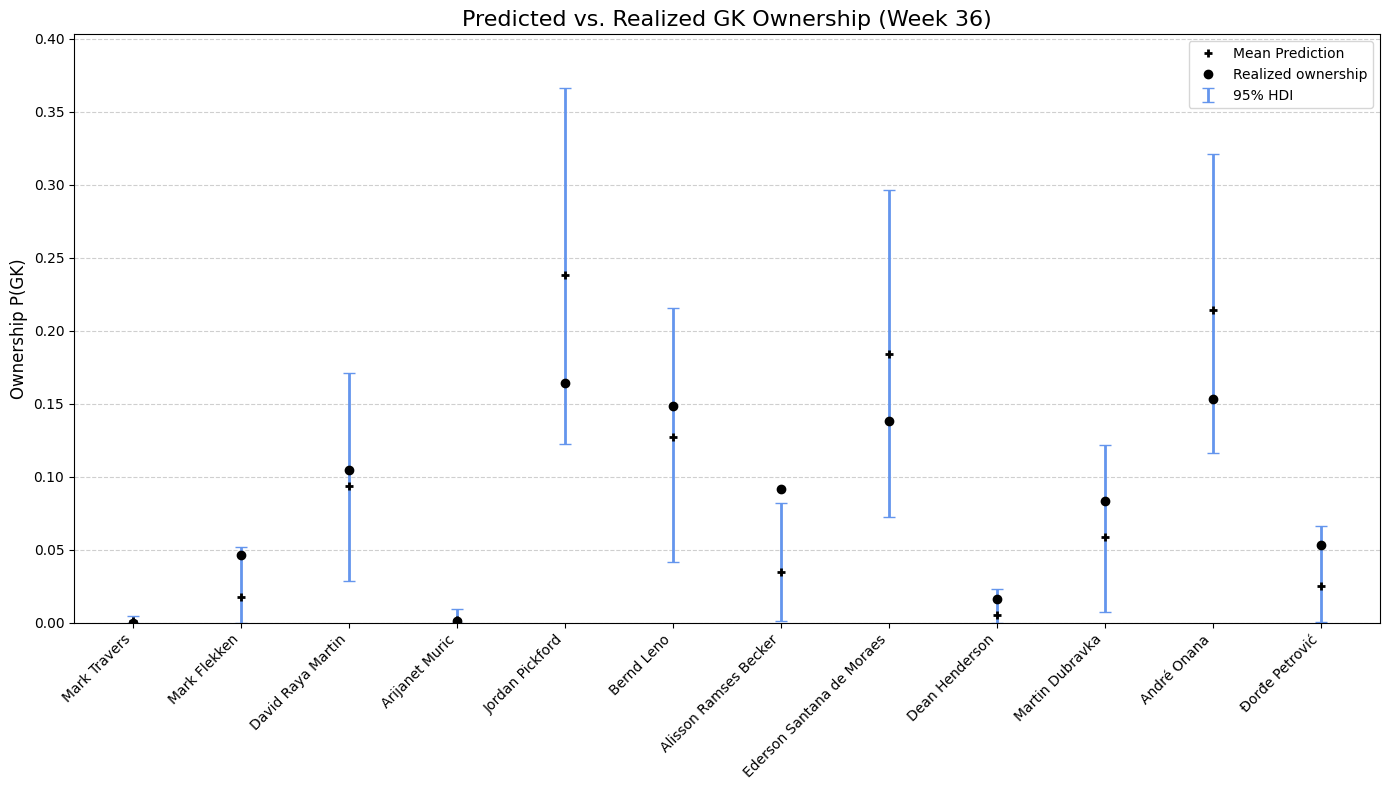

In [17]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_gk.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_gk_features = X_gk.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_gk[i]

    eta_vector = np.dot(X_gk_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=gk_names,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    gk_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    gk_names,
    gk_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized GK Ownership (Week 36)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(gk_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### DEF


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_3546/1745461626.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


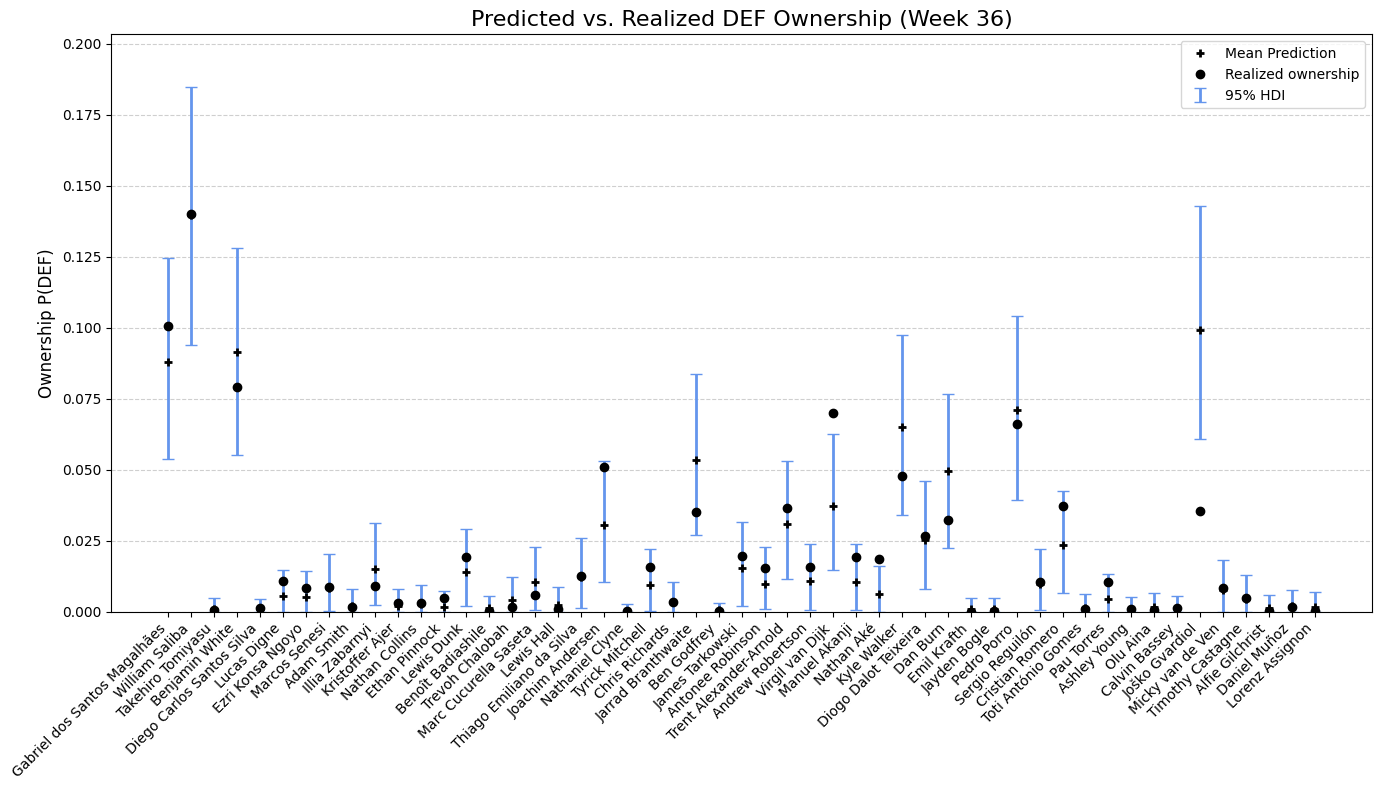

In [18]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_def.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_def_features = X_def.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_def[i]

    eta_vector = np.dot(X_def_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=def_names,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    def_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    def_names,
    def_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized DEF Ownership (Week 36)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(def_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### MID


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_3546/1168035522.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


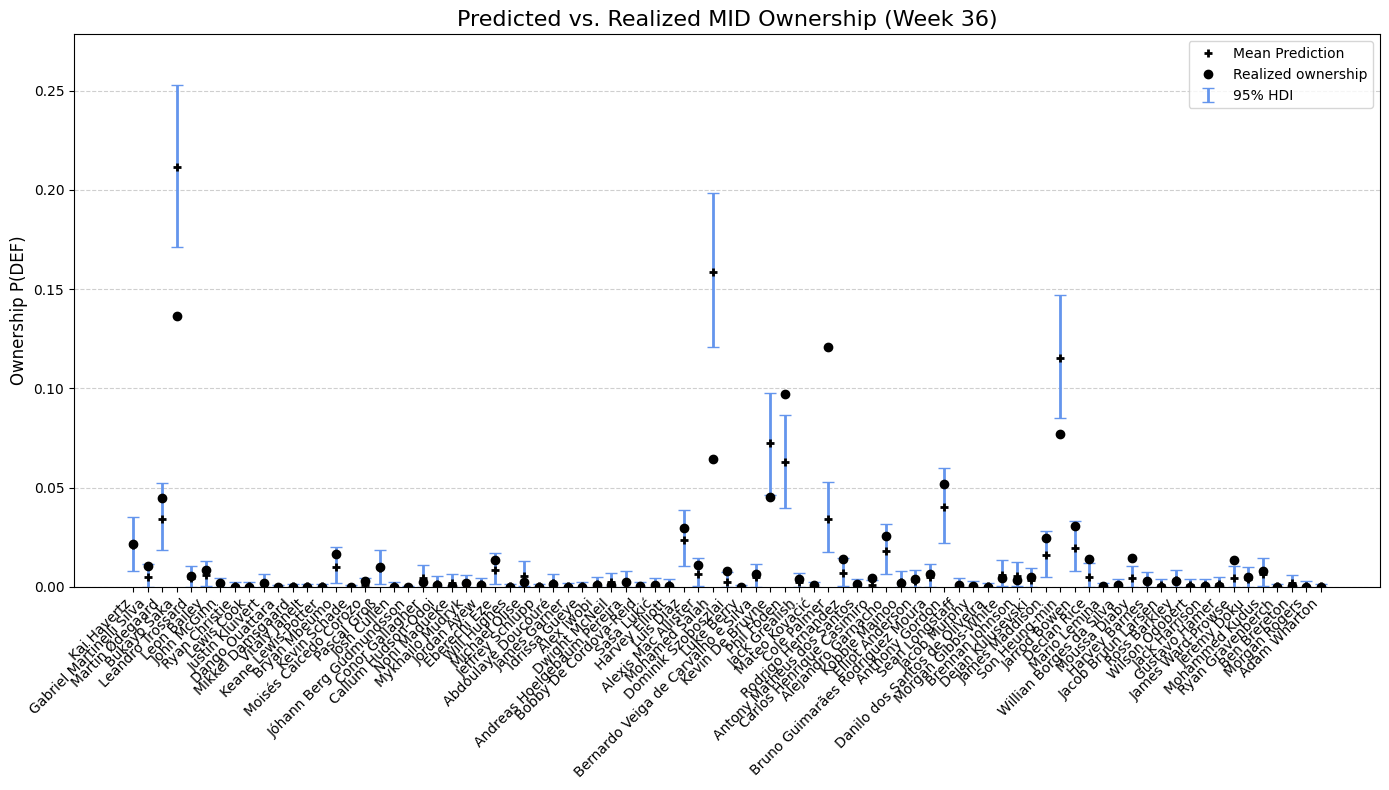

In [19]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_mid.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_mid_features = X_mid.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_mid[i]

    eta_vector = np.dot(X_mid_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=mid_names,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    mid_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    mid_names,
    mid_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized MID Ownership (Week 36)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### FWD


Extracted 8000 posterior samples for beta.


/tmp/ipykernel_3546/1238216225.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


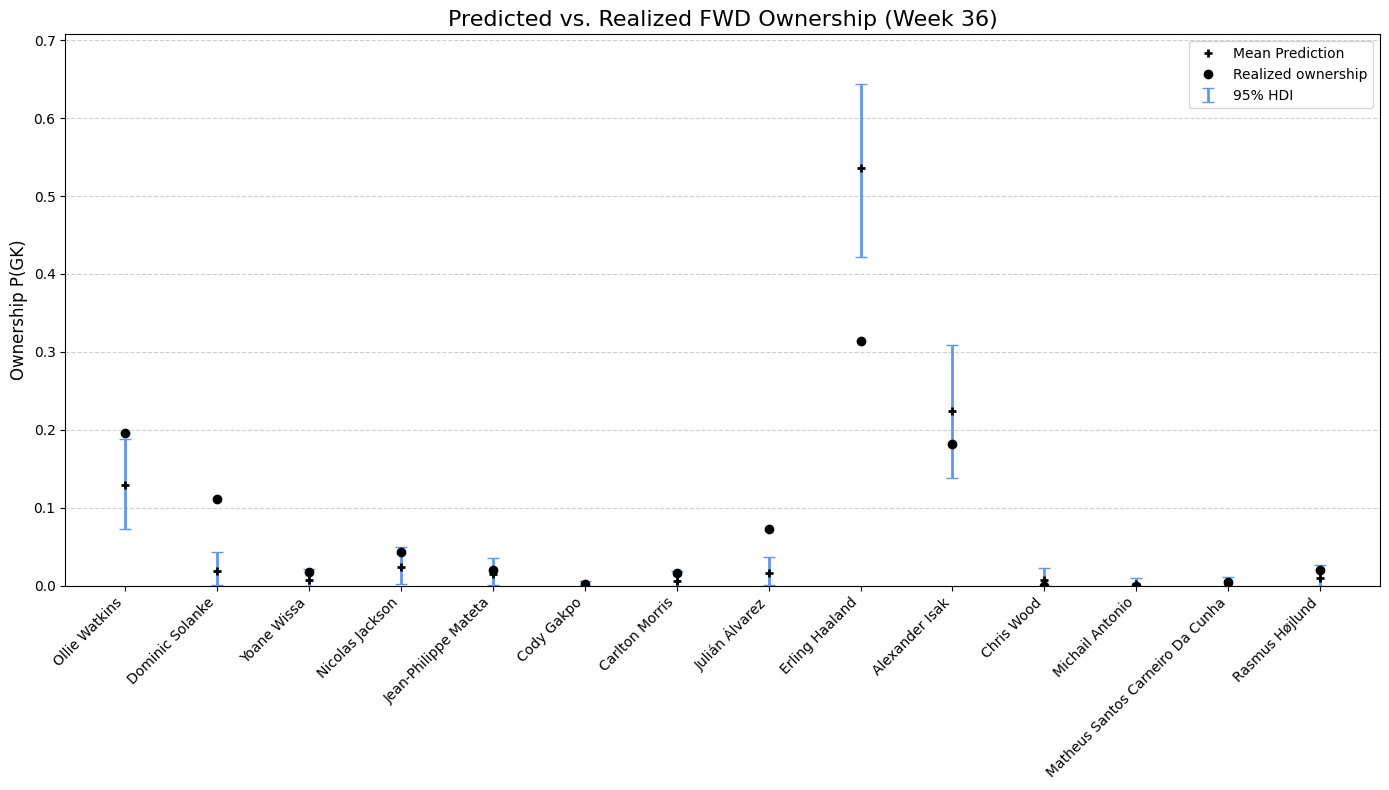

In [20]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_fwd.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_fwd_features = X_fwd.values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_fwd[i]

    eta_vector = np.dot(X_fwd_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_fwdpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=fwd_names,
    y=hdi_fwdpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    fwd_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    fwd_names,
    fwd_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized FWD Ownership (Week 36)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Generate Portfolios


In [21]:
import numpy as np

def filter_top_p(prob_dict, p=0.95):
    filtered_indices = {}

    for position, probs in prob_dict.items():
        # 1. Sort probabilities in descending order and get original indices
        # We need the indices to know which players to keep
        sorted_idx = np.argsort(probs)[::-1]
        # print(sorted_idx)
        sorted_probs = probs[sorted_idx]

        # 2. Calculate cumulative sums
        cum_sum = np.cumsum(sorted_probs)

        # 3. Find the first index where cumulative sum exceeds p
        # We use searchsorted to find the boundary
        cutoff_idx = np.searchsorted(cum_sum, p) + 1

        # 4. Extract the top indices
        top_indices = sorted_idx[:cutoff_idx]

        filtered_indices[position] = top_indices

        # (Optional) Log the results
        print(f"{position}: Kept {len(top_indices)}/{len(probs)} players "
              f"({(len(top_indices)/len(probs))*100:.1f}%)")

    return filtered_indices

# Usage with your dictionary 'probs_vector'
filtered_players = filter_top_p(p_vectors, p=0.95)
filtered_players

GK: Kept 7/12 players (58.3%)
DEF: Kept 25/51 players (49.0%)
MID: Kept 30/83 players (36.1%)
FWD: Kept 6/14 players (42.9%)


{'GK': array([ 7,  4, 10,  5,  2,  6, 11]),
 'DEF': array([ 1, 45, 37, 34, 39, 29,  0,  3, 32, 23, 33, 27, 19, 25,  9, 46, 10,
        16, 21, 15, 13, 18, 30, 28, 11]),
 'MID': array([ 3, 40, 64, 44, 45,  2, 65, 56,  0, 38, 49, 63,  5, 48, 52, 14, 17,
        39, 20, 69, 78,  1, 16, 25, 55, 33, 66, 61, 22, 60]),
 'FWD': array([ 8,  9,  0,  3, 13, 12])}

In [22]:
# [i for i in p_vectors['GK'] if i in filtered_players['GK']]
sorted_f = {}
ids_f = []
xPts_f = []
prices_f = []
teams_f = []
p_vectors_f = {}
X_data = [X_gk, X_def, X_mid, X_fwd]
X_f = []
i = 0
for pos in filtered_players:
    sorted_indices = list(np.sort(filtered_players[pos]))
    ids_f.append([ids[i][j] for j in sorted_indices])
    xPts_f.append([xPts[i][j] for j in sorted_indices])
    prices_f.append([prices[i][j] for j in sorted_indices])
    teams_f.append([teams[i][j] for j in sorted_indices])
    p_vectors_f[pos] = p_vectors[pos][sorted_indices]
    X_f.append(X_data[i].iloc[sorted_indices])

    i+= 1

In [24]:
generated_portfolios = sample_opponent_portfolios(
    O=50,
    batch_size = 10_000,
    beta_estimates=all_beta_estimates,
    feature_matrices=  X_data,
    ids = ids,
    costs=prices,
    budget=80,
    teams=teams,
    xp_preds=xPts,
    p_vectors=p_vectors
    )


Generating 50 opponent portfolios...


⚙️ Using 4 cores to generate 50 teams...
12
************* 56.0
************* 56.8
************* 59.5
************* 57.0
************* 53.2
************* 56.400000000000006
************* 68.1
************* 60.2
************* 69.0
************* 56.8
************* 58.599999999999994
************* 55.2
************* 54.6
************* 62.2
************* 57.7
************* 59.7
************* 63.8
************* 59.60000000000001
************* 58.3
************* 59.2
************* 64.3
************* 52.8
************* 61.2
************* 58.39999999999999
************* 58.300000000000004
************* 67.60000000000001
************* 61.400000000000006
************* 57.3
************* 51.699999999999996
************* 58.1
************* 64.5
************* 57.5
************* 60.4
************* 54.6
************* 65.2
************* 57.3
************* 64.4
************* 55.400000000000006
************* 55.0
************* 63.099999999999994
************* 56.1
************* 62.69999999999999
********

KeyboardInterrupt: 

In [ ]:
Wo_ = []
for i in generated_portfolios:
    # print(i)
    # Create a tuple of 0s and 1s for each player
    squad = tuple([1 if id_ in i else 0 for id_ in players_preds['FPL_ID'].tolist()])
    Wo_.append(squad)

len(Wo_)


50

In [ ]:
teams_costs = []
for team in generated_portfolios:
    cost  = players_preds.loc[list(team), "total_points"].sum()
    teams_costs.append(cost)

# teams_costs

print(len(generated_portfolios))

50


In [ ]:
[id_ for id_ in list(generated_portfolios)[0]]

[257, 163, 259, 4, 6, 133, 207, 79, 177, 150, 126]

In [ ]:
players_preds[players_preds['fpl_id'] == 259]['xP_pred']

110    4.842857
Name: xP_pred, dtype: float64

In [ ]:
G = []
for wo in generated_portfolios:
    print(wo)
    G.append(np.sum([players_preds[players_preds['fpl_id'] == id_]['xP_pred'].values for id_ in wo]))
G

frozenset({257, 163, 259, 4, 6, 133, 207, 79, 177, 150, 126})


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (11,) + inhomogeneous part.

In [ ]:
def monte_carlo_simulation(W_o: np.ndarray, mu_delta: np.ndarray, sigma_delta: np.ndarray, Y_observed: np.ndarray, X_obs: np.ndarray, num_samples: int = 500):
    """
    Generate Monte Carlo samples for player performances and opponent scores using PyMC (MCMC).

    The likelihood function (pm.Normal) is now included to update the delta prior based on
    historical observed scores (Y_observed) via the design matrix (X_obs).
    """
    num_player = len(mu_delta) # Use mu_delta size for player count

    with pm.Model() as model:
        sd_dist = pm.HalfNormal.dist(sigma_delta)

        # Assuming mu_delta is log-transformed, which needs to be exponentiated for player points
        # If mu_delta is already player points, remove the pm.math.exp()
        mu_delta_ = pm.Deterministic('mu_delta_', pm.math.exp(mu_delta) + 1e-6)

        # Priors for the Covariance Structure
        chol, corr, sigmas = pm.LKJCholeskyCov(
            'chol_cov', eta=20, n=num_player, sd_dist=sd_dist
        )
        cov = pt.dot(chol, chol.T)

        # Prior for Player Skill (delta)
        delta = pm.MvNormal("delta", mu=mu_delta_, cov=cov, shape=num_player)

        # ----------------------------------------------------------------------
        # >>> LIKELIHOOD FUNCTION: Links latent skill (delta) to observed scores (Y_observed)
        # ----------------------------------------------------------------------
        obs_sigma = pm.HalfNormal("obs_sigma", 1) # Noise term for observed scores

        # Expected scores calculation: Design matrix (X_obs) * Player skills (delta)
        # X_obs must have shape (N_observations, N_players)
        expected_scores = pt.dot(X_obs, delta)

        # Likelihood term: How probable the actual scores (Y_observed) are given the model's expectations
        pm.Normal("observed_scores", mu=expected_scores, sigma=obs_sigma, observed=Y_observed)
        # ----------------------------------------------------------------------

        # G_r calculation: 90th percentile of opponent performance (W_o @ delta)
        G_r = pm.Deterministic("G_r", pt.sort(pt.dot(W_o, delta))[-int(len(W_o) * 0.9)])

        print("Running MCMC Sampler...")
        # Note: Increase 'tune' and 'num_samples' for production use.
        trace = pm.sample(num_samples, tune=500, return_inferencedata=True, cores=2, progressbar=True)

    delta_samples = trace.posterior["delta"].values.reshape(-1, num_player)
    G_r_samples = trace.posterior["G_r"].values.flatten()

    return delta_samples, G_r_samples


In [ ]:
# MC_sim_trace = monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta)

hist_data = data_23_24[data_23_24['fpl_id'].isin(players_preds[players_preds['event'] == 36]['fpl_id'])]['total_points'].dropna()
hist_data.shape

(5010,)

In [ ]:

hist_data = data_23_24[data_23_24['fpl_id'].isin(players_preds[players_preds['event'] == 36]['fpl_id'])]['total_points'].dropna()
hist_data.shape

# Assuming total FPL players (P) is 500 for MCMC robustness, even if optimization uses 50.
P_MCMC = len(data_23_24[data_23_24['fpl_id'].isin(players_preds[players_preds['event'] == 36]['fpl_id'])]['fpl_id'].unique())
N_OBSERVATIONS = len(hist_data) # Based on your historical data shape

# MOCK DATA FOR MCMC INPUTS (Based on expected shapes)
# delta_samples_mock and G_r_samples_mock are derived from this step.
delta_samples_mock = np.random.normal(loc=1.0, scale=0.5, size=(5000, P_MCMC))
G_r_samples_mock = np.random.normal(loc=15.0, scale=3.0, size=5000)
lambdas_mock = np.linspace(0.0, 0.5, 6)

# X_obs: Shape (N_OBSERVATIONS, P_MCMC). Sparse matrix linking observation to player.
X_obs = (np.random.rand(N_OBSERVATIONS, P_MCMC) > 0.98).astype(int)
# Y_observed: Shape (N_OBSERVATIONS,). Actual historical scores (total_points).
Y_observed = np.array(hist_data) #np.random.uniform(0, 15, N_OBSERVATIONS)
# W_o: Opponent matrix for GW 36 (N_OPPONENT_MATCHES, P_MCMC)
# W_o_mock = (np.random.rand(10, P_MCMC) > 0.99).astype(float)


In [ ]:
import pytensor.sparse as pts
from scipy import sparse

In [ ]:
def monte_carlo_simulation(W_o: np.ndarray, mu_delta: np.ndarray, sigma_delta: np.ndarray, Y_observed: np.ndarray, X_obs: np.ndarray, num_samples: int = 500):
    """
    Generate Monte Carlo samples for player performances and opponent scores using PyMC (MCMC).

    The likelihood function (pm.Normal) is now included to update the delta prior based on
    historical observed scores (Y_observed) via the design matrix (X_obs).
    """
    # num_player should be the size of the full MCMC player pool (P)
    num_player = len(mu_delta)

    with pm.Model() as model:
        # Data container for better graph handling
        # X_data = pm.ConstantData("X_data", X_obs)
        delta = pm.Normal("delta", mu=mu_delta, sigma=sigma_delta, shape=num_player)

        # Y_observed should be historical total_points (11,294 observations)
        obs_sigma = pm.HalfNormal("obs_sigma", 1) # Noise term for observed scores
        expected_scores = pt.dot(X_obs, delta)

        # Likelihood term: How probable the actual scores (Y_observed) are given the model's expectations
        pm.Normal("observed_scores", mu=expected_scores, sigma=obs_sigma, observed=Y_observed)

        print("Running MCMC Sampler...")
        # Note: Increase 'tune' and 'num_samples' for production use.
        trace = pm.sample(
            draws=num_samples,
            tune=1000,
            chains=4,
            cores=4,
            target_accept=0.9,
            random_seed=42
        )

    #     # approx = pm.fit(n=2000, method='advi', progressbar=True)
    #     # trace = approx.sample(2000)

    delta_samples = trace.posterior["delta"].values.reshape(-1, num_player)

    return delta_samples #, G_r_samples


In [ ]:
delta_sample_trace

array([[ 1.61507203,  0.49132339,  0.64849165, ...,  1.25661058,
         0.31848664,  0.67761504],
       [ 1.62436323, -0.0451254 , -0.22497465, ...,  0.97748079,
         1.60181309,  0.61933651],
       [ 1.087265  ,  0.8389366 ,  1.51555305, ...,  1.80720676,
         0.34762842,  0.89841782],
       ...,
       [ 1.7756966 ,  0.24815824, -0.07060415, ...,  1.05993577,
         1.48922586,  0.39516277],
       [ 0.94460922,  0.08434503,  1.44738609, ...,  0.81015668,
         0.57542698,  0.67519447],
       [ 2.28123421, -0.20280951,  0.98994441, ...,  0.2133186 ,
         0.63876939,  0.71628377]])

Running MCMC Sampler...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [delta, obs_sigma]


Output()

Sampling 4 chains for 1_000 tune and 176 draw iterations (4_000 + 704 draws total) took 430 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
/home/ilyandho/.local/share/mamba/envs/pycaret/lib/python3.10/site-packages/arviz/data/base.py:272: UserWarning: More chains (704) than draws (176). Passed array should have shape (chains, draws, *shape)
  warnings.warn(
/home/ilyandho/.local/share/mamba/envs/pycaret/lib/python3.10/site-packages/arviz/data/base.py:272: UserWarning: More chains (704) than draws (176). Passed array should have shape (chains, draws, *shape)
  warnings.warn(


KeyError: 'var names: "[\'delta\'] are not present" in dataset'

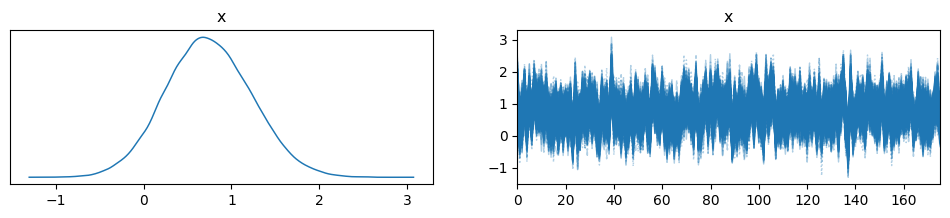

In [ ]:

delta_sample_trace = monte_carlo_simulation(Wo_, mu_delta, sigma_delta, Y_observed, X_obs, 176)# trace_gk

# Summary with R-hat, ESS, mean, sd, etc.
summary = az.summary(delta_sample_trace, var_names=["delta"], round_to=2)
summary


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
delta[0],1.31,0.42,0.44,2.01,0.01,0.02,1716.49,407.92,1.02
delta[1],0.27,0.38,-0.46,0.96,0.01,0.01,1840.53,511.56,1.01
delta[2],0.55,0.39,-0.19,1.28,0.01,0.02,1710.50,558.42,1.00
delta[3],1.18,0.39,0.56,2.06,0.01,0.02,2004.69,531.17,1.01
delta[4],0.44,0.38,-0.33,1.08,0.01,0.02,1954.03,547.53,1.01
...,...,...,...,...,...,...,...,...,...
delta[171],0.46,0.34,-0.10,1.10,0.01,0.01,2004.69,480.95,1.01
delta[172],0.64,0.28,0.15,1.18,0.01,0.01,1897.01,430.71,1.00
delta[173],1.05,0.34,0.42,1.64,0.01,0.01,2004.69,613.69,1.00
delta[174],1.12,0.36,0.47,1.83,0.01,0.01,2004.69,604.31,1.01


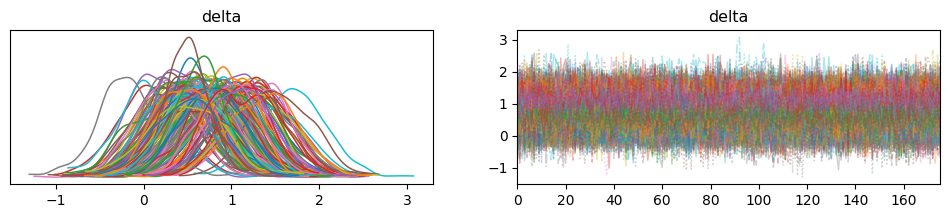

In [ ]:
# import arviz as az

# Reshape from (total_samples, num_players) to (chains, draws, players)
# Based on your function: 4 chains, draws=176 (or whatever num_samples was)
num_chains = 4
num_draws = delta_sample_trace.shape[0] // num_chains
num_players = delta_sample_trace.shape[1]

reshaped_delta = delta_sample_trace.reshape(num_chains, num_draws, num_players)

# Create an ArviZ InferenceData object
dataset = az.convert_to_dataset(
    {"delta": reshaped_delta},
    coords={"player_idx": np.arange(num_players)},
    dims={"delta": ["player_idx"]}
)

# Now your plots and summary will work!
az.plot_trace(dataset, var_names=["delta"], combined=True)
summary = az.summary(dataset, var_names=["delta"], round_to=2)
summary

In [ ]:
Wo_array = np.array(Wo_)

In [ ]:
# 1. Calculate Opponent Strength (90th percentile)
# Wo_ is your matrix of which players are opponents in which games
Wo_array = np.array(Wo_)
opponent_scores = np.dot(delta_sample_trace, Wo_array.T)
Gr_samples = np.percentile(opponent_scores, 90, axis=1) # The "Bar" to clear


     Skill_Mean  VoR_Prob
138        1.34  0.002841
39         1.70  0.002841
5          1.14  0.001420
7          1.31  0.001420
30         1.12  0.001420
106        1.31  0.001420
60         1.13  0.001420
0          1.31  0.000000
121        0.98  0.000000
116        0.74  0.000000


In [ ]:
Gr_samples

array([2.41840794, 4.44442845, 4.2385222 , 2.84682475, 3.78175335,
       3.39002862, 4.12628883, 3.60401899, 3.6184327 , 3.4698638 ,
       3.77698638, 3.93631148, 3.06155716, 4.02098216, 2.81337713,
       4.6325205 , 3.19215585, 3.64002139, 4.34483642, 3.37996708,
       3.50461233, 4.05127043, 3.31201564, 3.57101251, 3.84102627,
       3.20615702, 3.70998002, 3.24921545, 3.35114736, 2.96398541,
       4.22708286, 3.10165569, 3.78673151, 2.95752083, 3.7150775 ,
       3.56256559, 4.07849046, 4.20923734, 3.4501009 , 3.53299038,
       3.73726334, 3.32395777, 3.96884292, 3.22673529, 2.97062826,
       4.06590324, 4.6575026 , 2.76353787, 3.88300751, 3.38173134,
       3.81528789, 3.76266401, 3.5158266 , 3.94799964, 3.33814865,
       4.38185926, 3.05597315, 4.2793946 , 3.62068579, 3.69983942,
       3.76273652, 3.94545547, 3.66667863, 3.24271002, 3.88292018,
       3.54197752, 2.8333483 , 3.64495675, 2.74041582, 3.30048727,
       3.11009658, 4.46735842, 3.13858487, 3.80975998, 3.48068

In [ ]:
delta_samples = delta_sample_trace[0]

# After sampling
# delta_samples shape: (draws, players)
opp_perf = np.dot(delta_samples, Wo_array.T) # (draws, num_opponents)
G_r_samples = np.percentile(opp_perf, 90, axis=1)
G_r_samples #= MC_sim_trace[1]

AxisError: axis 1 is out of bounds for array of dimension 1

In [ ]:
# delta_samples = MC_sim_trace.posterior['delta'].stack(sample=("chain", "draw")).values.T  # shape (N_samples, 226)
# G_r_samples   = MC_sim_trace.posterior['G_r'].stack(sample=("chain", "draw")).values.T    # shape (N_samples, 200)

G_r_scalar = np.percentile(Gr_samples, 90)  # shape (N_samples,)

mu_delta, cov_delta, mu_G, var_G, cov_delta_G, sigma_G = generate_cov_delta(delta_samples, Gr_samples)

# mu_delta, cov_delta, mu_G, var_G, cov_delta_G, sigma_G
# G_r_scalar.shape

(176,) (704,)


IndexError: tuple index out of range

In [ ]:
lambdas = np.linspace(0.0, 0.5, 6)
best_lambda, best_w, best_prob = optimize_portfolio(add_fantasy_constraints, mu_delta, cov_delta, mu_G, var_G, cov_delta_G, lambdas, delta_samples, G_r_scalar, players_preds)
print(f"Best λ: {best_lambda}, Best Probability of Outperforming: {best_prob}")

selected, player_names, total_points, team_cost, formation = selected_info(best_w, fpl_teams_ids, players_preds, fg_managers_36)
print('fpl_ids: ', selected, '\nfpl_names: ', player_names, '\ntotal_points: ', total_points, '\nteam_cost: ', team_cost, '\nformation: ', formation)

DEBUG: Found players - GK: 15, DEF: 71, MID: 71, FWD: 19
costs------------------ 176
Checking feasibility...
Best λ: 0.0, Best Probability of Outperforming: 1.0
[13.  6. 42.  5.  2.  3.  2.  5.  7.  0.  1.] ---------> [2.16751788 5.948      6.68399764 5.02593302 2.93761293 3.44265488
 1.18279357 4.49571344 5.41347098 6.22742124 2.04672115]
Your predicted player’s total of 86.0 points would rank:
→ Position: 88 out of 229 managers
→ Percentile: Top 61.57%

Closest scores around you:
   points prize
0    86.5   NaN
1    86.5   NaN
2    86.0   NaN
3    85.5   NaN
4    85.0   NaN
fpl_ids:  [307, 152, 355, 6, 349, 14, 60, 353, 516, 290, 313] 
fpl_names:  ['Andrew Robertson', 'Bart Verbruggen', 'Erling Haaland', 'Kai Havertz', 'Kevin De Bruyne', 'Martin Ødegaard', 'Ollie Watkins', 'Phil Foden', 'Son Heung-min', 'Trent Alexander-Arnold', 'Virgil van Dijk'] 
total_points:  86.0 
team_cost:  94.00000000000001 
formation:  [1, 3, 5, 2]


In [ ]:
players_preds[players_preds['fpl_id'].isin(selected)][['fpl_name', 'team', 'position', 'xP_preds', 'total_points', 'value']]

,fpl_name,team,position,xP_preds,total_points,value
12,Andrew Robertson,Liverpool,DEF,2.167518,13,6.5
25,Bart Verbruggen,Brighton and Hove Albion,GK,5.948000,6,4.4
64,Erling Haaland,Manchester City,FWD,6.683998,21,14.1
98,Kai Havertz,Arsenal,MID,5.025933,5,7.5
99,Kevin De Bruyne,Manchester City,MID,2.937613,2,10.5
119,Martin Ødegaard,Arsenal,MID,3.442655,3,8.6
139,Ollie Watkins,Aston Villa,FWD,1.182794,2,9.0
144,Phil Foden,Manchester City,MID,4.495713,5,8.4
157,Son Heung-min,Tottenham Hotspur,MID,5.413471,7,9.9
163,Trent Alexander-Arnold,Liverpool,DEF,6.227421,0,8.4


In [ ]:
def calculate_portfolio_metrics(w, delta_samples, G_r_samples):
    """
    Calculates advanced evaluation metrics for a selected team (w).
    """
    # 1. Calculate the raw score distribution for My Team
    my_score_dist = np.dot(delta_samples, w)

    # 2. Calculate the "Active Return" (My Score - Target Score)
    excess_dist = my_score_dist - G_r_samples

    # --- METRIC: Win Probability ---
    prob_win = np.mean(excess_dist > 0)

    # --- METRIC: Expected Score & Excess ---
    mean_score = np.mean(my_score_dist)
    mean_excess = np.mean(excess_dist)

    # --- METRIC: Volatility (Risk) ---
    std_excess = np.std(excess_dist)

    # --- METRIC: Sharpe Ratio (Efficiency) ---
    # Measures return per unit of risk. Higher is better.
    sharpe = mean_excess / std_excess if std_excess > 0 else 0

    # --- METRIC: Information Ratio (IR) ---
    # In this context, similar to Sharpe, but conceptually focuses on tracking error.
    ir = mean_excess / std_excess if std_excess > 0 else 0

    # --- METRIC: Value at Risk (VaR 5%) ---
    # The score you will exceed 95% of the time. (Worst case scenario safety net).
    var_5 = np.percentile(my_score_dist, 5)

    return {
        "prob_win": prob_win,
        "mean_score": mean_score,
        "mean_excess": mean_excess,
        "sharpe": sharpe,
        "ir": ir,
        "var_5": var_5
    }


all_ids = np.concatenate(ids)
selected_ind = [1 if i in selected else 0 for i in all_ids]
calculate_portfolio_metrics(selected_ind, delta_samples, G_r_samples)

{'prob_win': 0.9935,
 'mean_score': 4.240782653307257,
 'mean_excess': 2.6382435760848484,
 'sharpe': 2.3847384582879343,
 'ir': 2.3847384582879343,
 'var_5': 2.6263207062559744}

# GW 37


In [ ]:
players_preds = pd.read_csv(f'../FPL predictors/Fantasy Go/fantasyGo_preds_37.csv', index_col=0)
# players_preds = pd.read_csv('./../FPL predictors/with new features/models/preds/players_preds_37.csv', index_col=0)

# Check if teams match
players_preds = players_preds[players_preds['player_team'].isin(FPL_teams_23_24)]

players_preds['xP_cost'] = round(players_preds['xP']/players_preds['value'], 2)

data_23_24['xP_cost'] = round(data_23_24['xP']/data_23_24['value'], 2)
data_23_24_37 = data_23_24[data_23_24['event'] < 37]

# # Add fpl_id to player_preds
players_preds = players_preds.merge(fpl_teams_ids, left_on='fpl_name', right_on='FPL_Name', how='left')

# Cater for transfers
players_preds['player_team'] = players_preds['team']
# players_preds[players_preds['player_team'] != players_preds['team']][['fpl_name', 'player_team', 'team']]

## Generate Cov_Mat


In [ ]:
mu_delta, sigma_delta, cov_mat, valid_player_ids = generate_cov_mat(players_preds, data_23_24_37)
# cov_mat
players_preds = players_preds[players_preds['fpl_id'].isin(valid_player_ids)]

Starting to optimize team selection...
(186, 190)
(5133, 181)
(186,) (186,) (186, 186)


## Data Preparations


In [ ]:
data_cols.append('fpl_id')
data_cols_gk.append('fpl_id')

data_23_24_37 = data_23_24_37[data_23_24_37['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
players_preds = players_preds[players_preds['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
data, prices, xPts, positions , teams, ids, X_pca, names, probs = clean_data(players_preds, valid_player_ids)

starting to clean data...
data successfully cleaned...


In [ ]:
# ownership_gk = players_preds[players_preds['position'] == 'GK']['ownership_percent']
# gk_names = players_preds[players_preds['position'] == 'GK']['FPL_Name']
# gk_probs_obs = ownership_gk / ownership_gk.sum()

# ownership_def = players_preds[players_preds['position'] == 'DEF']['ownership_percent']
# def_names = players_preds[players_preds['position'] == 'DEF']['FPL_Name']
# def_probs_obs = ownership_def / ownership_def.sum()

# cols = data_cols.copy()
# cols.append('ownership_percent')
# cols.append('FPL_Name')

# mids = players_preds[players_preds['position'] == 'MID'][cols].dropna()
# ownership_mid = mids['ownership_percent']
# mid_names = mids['FPL_Name']
# mid_probs_obs = ownership_mid / ownership_mid.sum()


# cols = feats_cols_fwd.copy()
# cols.append('FPL_Name')
# fwds = players_preds[players_preds['position'] == 'FWD'][cols].dropna()
# ownership_fwds = fwds['ownership_percent']
# fwd_names = fwds['FPL_Name']
# fwd_probs_obs = ownership_fwds / ownership_fwds.sum()

In [ ]:
alphas = {
        'GK': np.exp(X_pca[0] @ beta_gk.T).mean(axis=1),
        'DEF': np.exp(X_pca[1] @ beta_def.T).mean(axis=1),
        'MID': np.exp(X_pca[2] @ beta_mid.T).mean(axis=1),
        'FWD': np.exp(X_pca[3] @ beta_fwd.T).mean(axis=1)
    }


p_vectors = {pos: np.random.dirichlet(alpha) for pos, alpha in alphas.items()}
p_vectors

{'GK': array([2.11075589e-07, 1.33503863e-03, 2.35785184e-03, 6.15197415e-03,
        7.26016408e-01, 8.29498116e-06, 1.88065860e-06, 4.97070519e-07,
        3.68724454e-06, 3.17000060e-07, 3.64594030e-05, 1.82854056e-07,
        2.64083575e-01, 1.90158339e-07, 2.38171218e-06, 1.05020862e-06]),
 'DEF': array([7.11429600e-06, 3.85554017e-11, 3.20210485e-08, 3.35093575e-09,
        9.22022070e-06, 1.76336315e-11, 3.48598936e-10, 3.73604175e-08,
        1.80228638e-08, 6.27994619e-06, 2.00321132e-07, 1.50504932e-07,
        1.39141893e-04, 1.19964612e-10, 3.13904666e-05, 1.03132840e-07,
        4.92520061e-07, 6.85155592e-11, 3.40958907e-11, 3.27456031e-11,
        7.52454931e-09, 8.42377201e-11, 4.26893951e-04, 2.24260097e-10,
        2.58123522e-10, 1.56190829e-11, 2.61608368e-10, 1.21955098e-09,
        6.11704155e-09, 4.80580615e-06, 1.26237664e-04, 5.42239286e-09,
        3.28104128e-07, 8.99069649e-08, 1.00731378e-11, 9.06261083e-11,
        4.62239579e-10, 1.77083234e-08, 2.9617805

## Plots


In [ ]:
gk_names = names[0]
def_names = names[1]
mid_names = names[2]
fwd_names = names[3]

gk_probs_obs = probs[0]
def_probs_obs = probs[1]
mid_probs_obs = probs[2]
fwd_probs_obs = probs[3]


### GK


Extracted 2000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_13552\4096672833.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


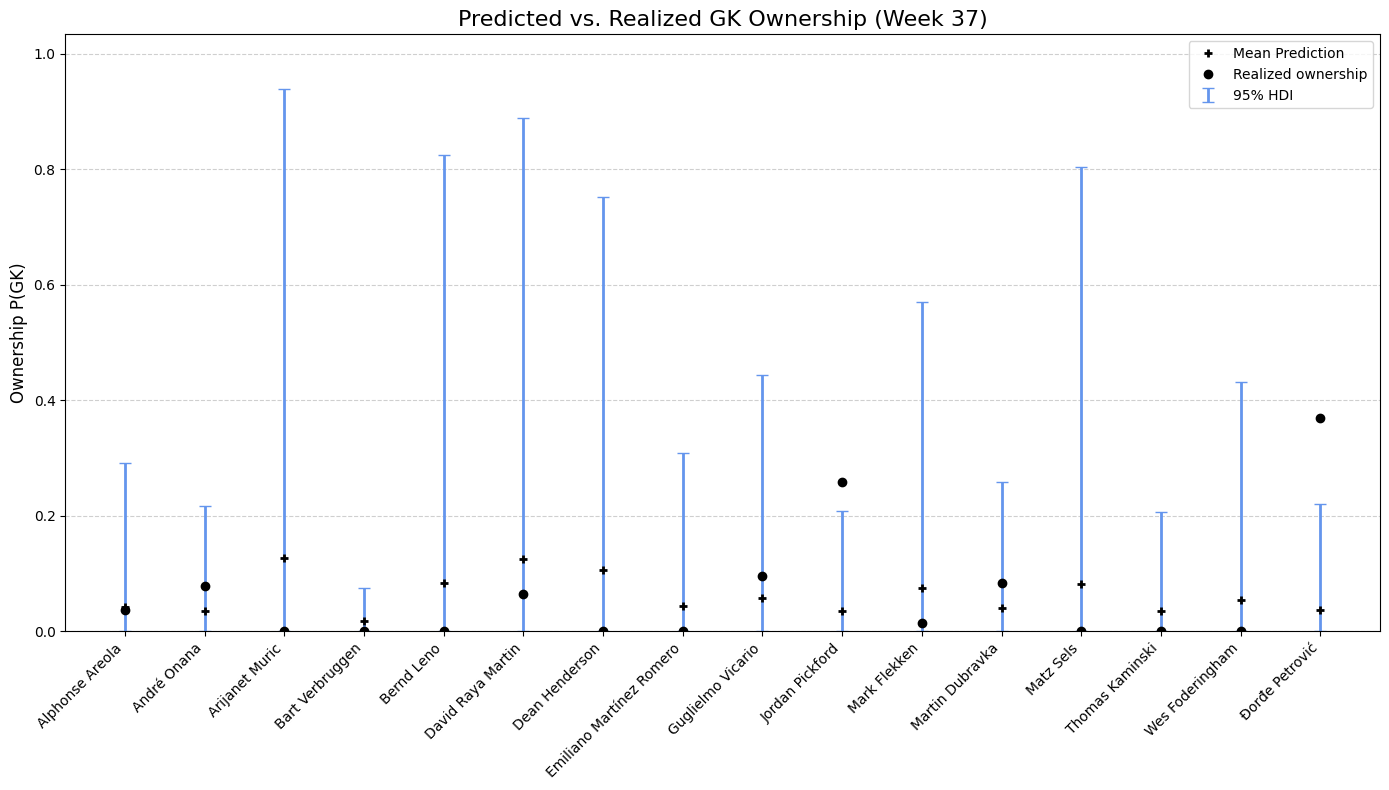

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_gk.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_gk_features = X_pca[0].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_gk[i]

    eta_vector = np.dot(X_gk_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=gk_names,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    gk_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    gk_names,
    gk_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized GK Ownership (Week 37)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(gk_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### DEF


Extracted 2000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_13552\2654067066.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


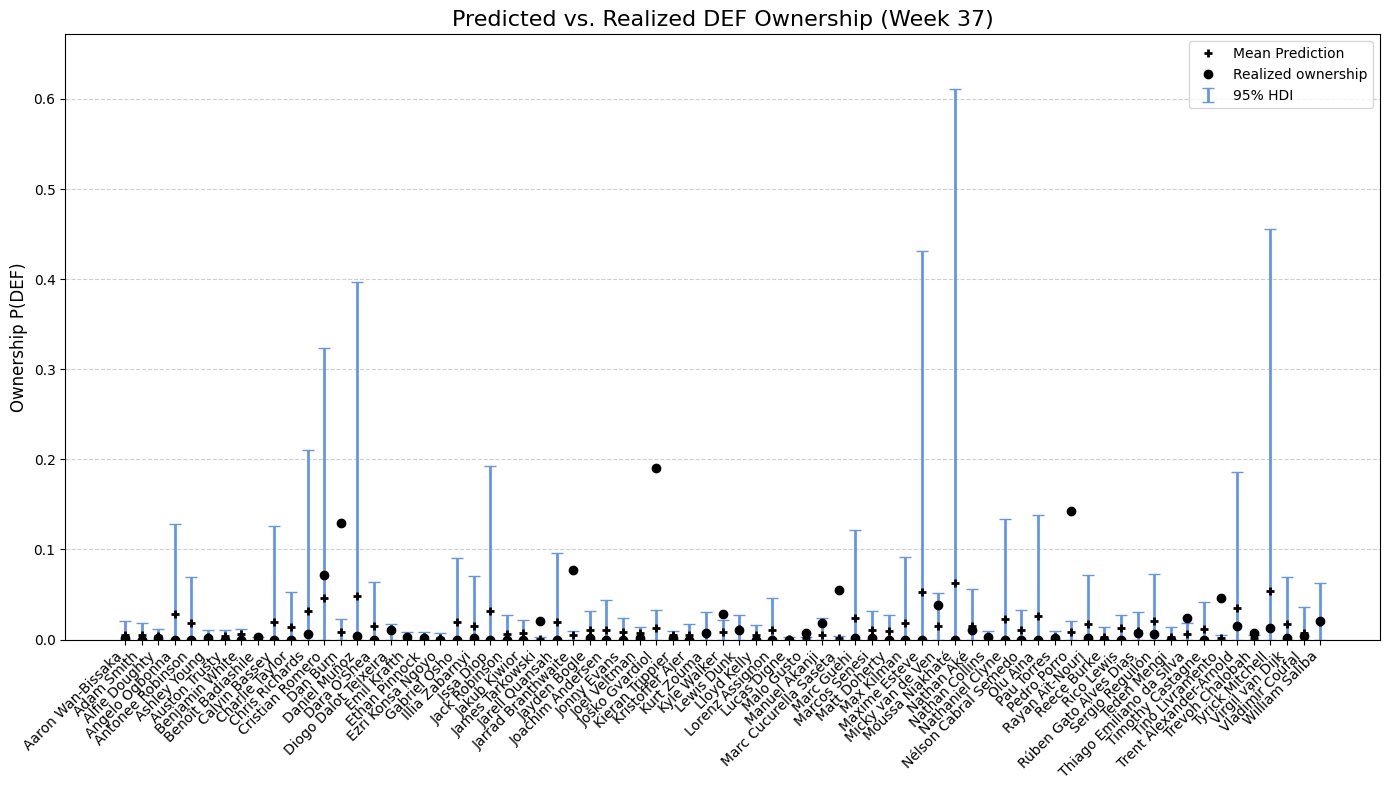

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_def.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_def_features = X_pca[1].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_def[i]

    eta_vector = np.dot(X_def_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=def_names,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    def_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    def_names,
    def_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized DEF Ownership (Week 37)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(def_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### MID


Extracted 2000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_13552\180272595.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


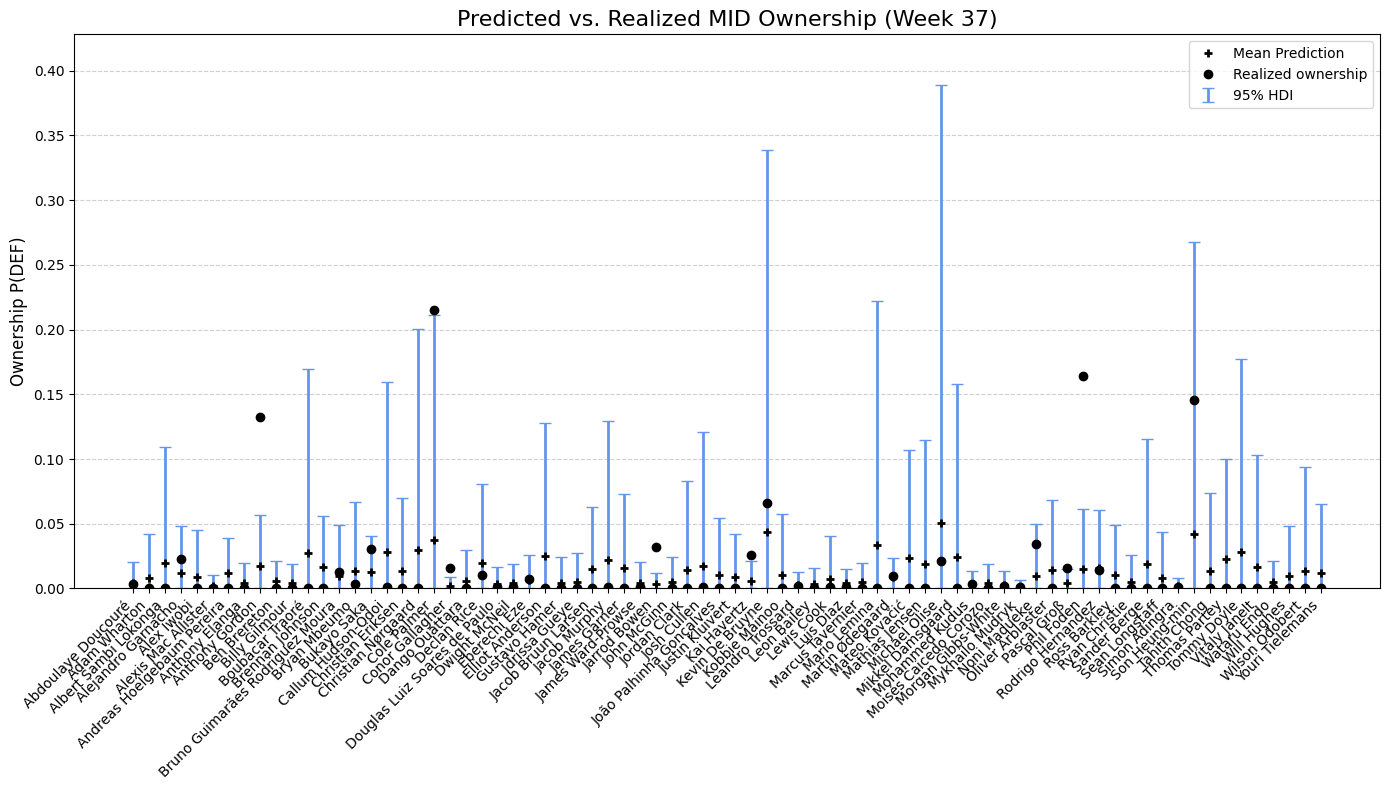

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_mid.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_mid_features = X_pca[2].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_mid[i]

    eta_vector = np.dot(X_mid_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=mid_names,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    mid_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    mid_names,
    mid_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized MID Ownership (Week 37)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### FWD


Extracted 2000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_13552\4259362983.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


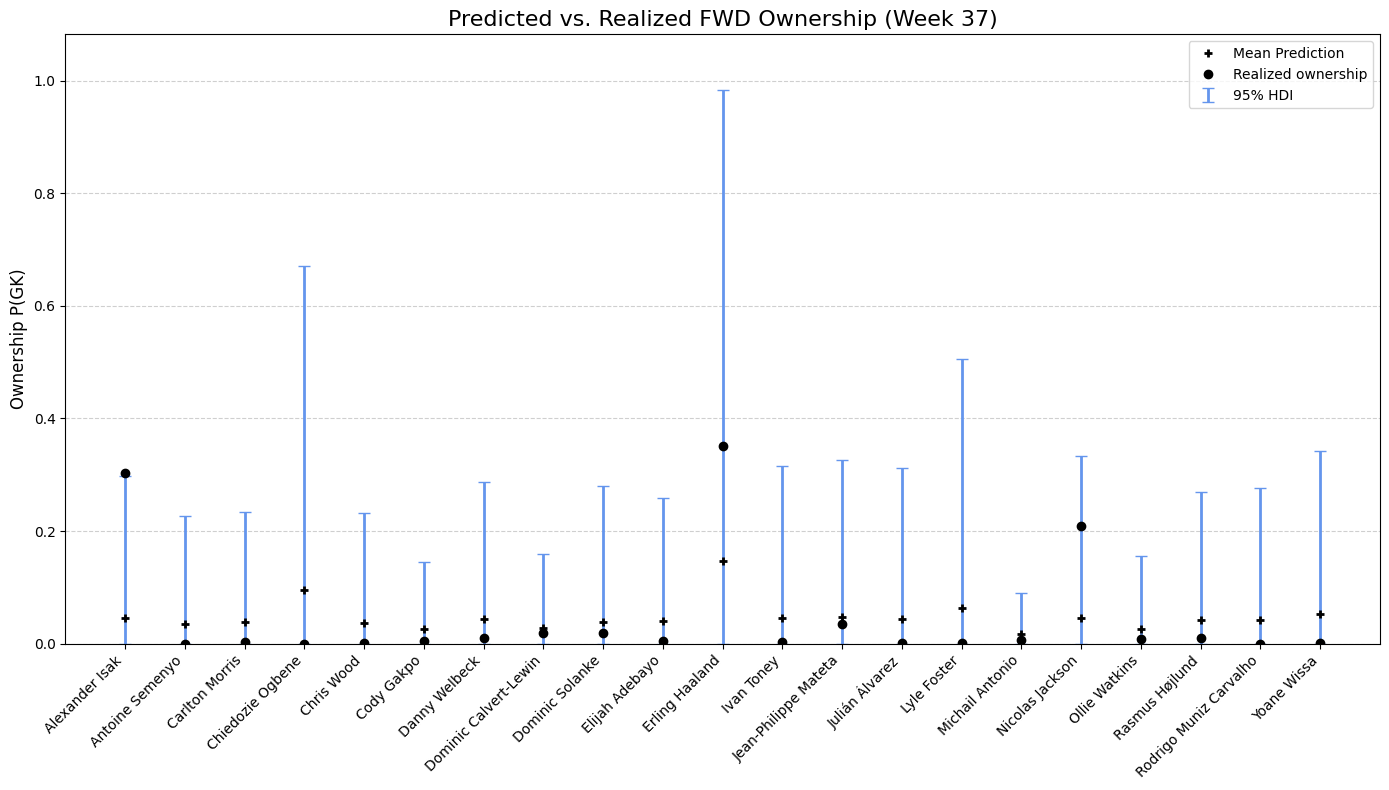

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_fwd.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_fwd_features = X_pca[3].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_fwd[i]

    eta_vector = np.dot(X_fwd_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_fwdpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=fwd_names,
    y=hdi_fwdpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    fwd_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    fwd_names,
    fwd_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized FWD Ownership (Week 37)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Generate Portfolios


In [ ]:
generated_portfolios = sample_opponent_portfolios(
    O=50,
    batch_size = 100_000,
    beta_estimates=all_beta_estimates,
    feature_matrices=X_pca,
    ids = ids,
    costs=prices,
    budget=80,
    teams=teams,
    xp_preds=xPts,
    p_vectors=p_vectors
    )


Generating 50 opponent portfolios...
⚙️ Using 4 cores to generate 50 teams...
✅ Collected 0 valid teams after 100000 attempts...: 50
🎯 Done! Generated 50 unique portfolios.


In [ ]:
Wo_ = []
for i in generated_portfolios:
    # print(i)
    # Create a tuple of 0s and 1s for each player
    squad = tuple([1 if id_ in i else 0 for id_ in players_preds['FPL_ID'].tolist()])
    Wo_.append(squad)

np.sum(Wo_[0])


1

In [ ]:
teams_costs = []
for team in generated_portfolios:
    cost  = players_preds.loc[list(team), "total_points"].sum()
    teams_costs.append(cost)

# teams_costs

print(len(mu_delta))

186


In [ ]:
# def monte_carlo_simulation(W_o: np.ndarray, mu_delta: np.ndarray, sigma_delta: np.ndarray, Y_observed: np.ndarray, X_obs: np.ndarray, num_samples: int = 500) -> Tuple[np.ndarray, np.ndarray]:
#     """
#     Generate Monte Carlo samples for player performances and opponent scores using PyMC (MCMC).

#     The likelihood function (pm.Normal) is now included to update the delta prior based on
#     historical observed scores (Y_observed) via the design matrix (X_obs).
#     """
#     num_player = len(mu_delta) # Use mu_delta size for player count

#     with pm.Model() as model:
#         sd_dist = pm.HalfNormal.dist(sigma_delta)

#         # Assuming mu_delta is log-transformed, which needs to be exponentiated for player points
#         # If mu_delta is already player points, remove the pm.math.exp()
#         mu_delta_ = pm.Deterministic('mu_delta_', pm.math.exp(mu_delta) + 1e-6)

#         # Priors for the Covariance Structure
#         chol, corr, sigmas = pm.LKJCholeskyCov(
#             'chol_cov', eta=20, n=num_player, sd_dist=sd_dist
#         )
#         cov = pt.dot(chol, chol.T)

#         # Prior for Player Skill (delta)
#         delta = pm.MvNormal("delta", mu=mu_delta_, cov=cov, shape=num_player)

#         # ----------------------------------------------------------------------
#         # >>> LIKELIHOOD FUNCTION: Links latent skill (delta) to observed scores (Y_observed)
#         # ----------------------------------------------------------------------
#         obs_sigma = pm.HalfNormal("obs_sigma", 1) # Noise term for observed scores

#         # Expected scores calculation: Design matrix (X_obs) * Player skills (delta)
#         # X_obs must have shape (N_observations, N_players)
#         expected_scores = pt.dot(X_obs, delta)

#         # Likelihood term: How probable the actual scores (Y_observed) are given the model's expectations
#         pm.Normal("observed_scores", mu=expected_scores, sigma=obs_sigma, observed=Y_observed)
#         # ----------------------------------------------------------------------

#         # G_r calculation: 90th percentile of opponent performance (W_o @ delta)
#         G_r = pm.Deterministic("G_r", pt.sort(pt.dot(W_o, delta))[-int(len(W_o) * 0.9)])

#         print("Running MCMC Sampler...")
#         # Note: Increase 'tune' and 'num_samples' for production use.
#         trace = pm.sample(num_samples, tune=500, return_inferencedata=True, cores=2, progressbar=True)

#     delta_samples = trace.posterior["delta"].values.reshape(-1, num_player)
#     G_r_samples = trace.posterior["G_r"].values.flatten()

#     return delta_samples, G_r_samples


In [ ]:
# MC_sim_trace = monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta)

hist_data = data_23_24[data_23_24['fpl_id'].isin(players_preds[players_preds['event'] == 37]['fpl_id'])]['total_points'].dropna()
hist_data.shape

(5479,)

In [ ]:

hist_data = data_23_24[data_23_24['fpl_id'].isin(players_preds[players_preds['event'] == 37]['fpl_id'])]['total_points'].dropna()
hist_data.shape

# Assuming total FPL players (P) is 500 for MCMC robustness, even if optimization uses 50.
P_MCMC = len(data_23_24[data_23_24['fpl_id'].isin(players_preds[players_preds['event'] == 37]['fpl_id'])]['fpl_id'].unique())
N_OBSERVATIONS = len(hist_data) # Based on your historical data shape

# MOCK DATA FOR MCMC INPUTS (Based on expected shapes)
# delta_samples_mock and G_r_samples_mock are derived from this step.
delta_samples_mock = np.random.normal(loc=1.0, scale=0.5, size=(5000, P_MCMC))
G_r_samples_mock = np.random.normal(loc=15.0, scale=3.0, size=5000)
lambdas_mock = np.linspace(0.0, 0.5, 6)

# X_obs: Shape (N_OBSERVATIONS, P_MCMC). Sparse matrix linking observation to player.
X_obs = (np.random.rand(N_OBSERVATIONS, P_MCMC) > 0.98).astype(int)
# Y_observed: Shape (N_OBSERVATIONS,). Actual historical scores (total_points).
Y_observed = np.array(hist_data) #np.random.uniform(0, 15, N_OBSERVATIONS)
# W_o: Opponent matrix for GW 37 (N_OPPONENT_MATCHES, P_MCMC)
# W_o_mock = (np.random.rand(10, P_MCMC) > 0.99).astype(float)


In [ ]:
def monte_carlo_simulation(W_o: np.ndarray, mu_delta: np.ndarray, sigma_delta: np.ndarray, Y_observed: np.ndarray, X_obs: np.ndarray):
    """
    Generate Monte Carlo samples for player performances and opponent scores using PyMC (MCMC).

    The likelihood function (pm.Normal) is now included to update the delta prior based on
    historical observed scores (Y_observed) via the design matrix (X_obs).
    """
    # num_player should be the size of the full MCMC player pool (P)
    num_samples = len(mu_delta)
    num_player = len(mu_delta)

    with pm.Model() as model:
        # Prior for standard deviations, derived from the historical xP variance
        sd_dist = pm.HalfNormal.dist(sigma_delta)

        # Assuming mu_delta is linear expected points, use it directly as the mean skill level.
        mu_delta_ = mu_delta #pm.Deterministic('mu_delta_', mu_delta + 1e-6)

        # Priors for the Covariance Structure
        chol, corr, sigmas = pm.LKJCholeskyCov(
            'chol_cov', eta=20, n=num_player, sd_dist=sd_dist
        )
        cov = pt.dot(chol, chol.T)

        # Prior for Player Skill (delta)
        delta = pm.MvNormal("delta", mu=mu_delta_, cov=cov, shape=num_player)

        # ----------------------------------------------------------------------
        # >>> LIKELIHOOD FUNCTION: Links latent skill (delta) to observed scores (Y_observed)
        # ----------------------------------------------------------------------
        # Y_observed should be historical total_points (11,294 observations)
        obs_sigma = pm.HalfNormal("obs_sigma", 1) # Noise term for observed scores

        # Expected scores calculation: Design matrix (X_obs) * Player skills (delta)
        expected_scores = pt.dot(X_obs, delta)

        # Likelihood term: How probable the actual scores (Y_observed) are given the model's expectations
        pm.Normal("observed_scores", mu=expected_scores, sigma=obs_sigma, observed=Y_observed)
        # ----------------------------------------------------------------------

        # G_r calculation: 90th percentile of opponent performance (W_o @ delta)
        G_r = pm.Deterministic("G_r", pt.sort(pt.dot(W_o, delta))[-int(len(W_o) * 0.9)])

        print("Running MCMC Sampler...")
        # Note: Increase 'tune' and 'num_samples' for production use.
        # trace = pm.sample(num_samples, tune=500, return_inferencedata=True, cores=2, progressbar=True)

        approx = pm.fit(n=2000, method='advi', progressbar=True)
        trace = approx.sample(2000)


    delta_samples = trace.posterior["delta"].values.reshape(-1, num_player)
    G_r_samples = trace.posterior["G_r"].values.flatten()

    return delta_samples, G_r_samples


In [ ]:
MC_sim_trace = monte_carlo_simulation(Wo_, mu_delta, sigma_delta, Y_observed, X_obs)


Running MCMC Sampler...


Output()

Finished [100%]: Average Loss = 1.7164e+43


In [ ]:
delta_samples = MC_sim_trace[0]
G_r_samples = MC_sim_trace[1]

In [ ]:

# def make_positive_definite(cov_mat, epsilon=1e-6):
#     # Ensure symmetry
#     cov_mat = (cov_mat + cov_mat.T) / 2

#     # Add jitter to diagonal
#     jitter = epsilon * np.eye(cov_mat.shape[0])
#     return cov_mat + jitter


# def monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta):
#     num_player = len(Wo_[0])

#     cov_mat = make_positive_definite(cov_mat)
#     L = np.linalg.cholesky(cov_mat)

#     with pm.Model() as model:
#         # Define the Multivariate Normal distribution for delta
#         delta = pm.MvNormal("delta", mu=mu_delta, chol=L, shape=num_player)

#         pm.Normal("observed_scores", mu=expected_scores, sigma=obs_sigma, observed=Y_observed)
#         # Inference using MCMC (NUTS sampler)
#         # trace = pm.sample(draws=2000, tune=1000, chains=4, target_accept=0.99, random_seed=42)
#         print("Running ADVI Optimization...")
#         # Using ADVI (Variational Inference) instead of NUTS (MCMC)
#         # n=30000 gives the optimizer time to converge
#         approx = pm.fit(n=30000, method='advi', random_seed=42)

#         print("Sampling from Posterior Approximation...")
#         # Draw samples from the approximated distribution
#         trace = approx.sample(draws=1000, random_seed=42)
#         # print("Running NUTS Sampler...")
#         # trace = pm.sample(draws=2000, chains=4, tune=1000, cores=4,  progressbar=True)

#     return trace

# MC_sim_trace = monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta)


Running ADVI Optimization...


Output()

Finished [100%]: Average Loss = 746.58


Sampling from Posterior Approximation...


In [ ]:
# # --- STEP 2: FAST POST-PROCESSING ---
# # Calculate G_r using optimized NumPy operations on the results
# print("Post-processing G_r...")

# # Extract delta samples: Shape (chains, draws, n_players)
# delta_samples = MC_sim_trace.posterior["delta"].values

# # Compute dot product via broadcasting:
# # (chains, draws, n_players) @ (n_players, n_items) -> (chains, draws, n_items)
# dot_products = np.dot(delta_samples, np.array(Wo_, dtype=float).T)

# # Compute 90th percentile across the items axis (last axis)
# # NumPy sort is much faster than PyTensor sort inside the loop
# g_r_samples = np.percentile(dot_products, 90, axis=-1)

# # --- STEP 3: UPDATE TRACE ---
# # Add G_r back into the MC_sim_trace object so az.summary() works as expected
# MC_sim_trace.posterior["G_r"] = (("chain", "draw"), g_r_samples)


# # return trace

# az.plot_trace(MC_sim_trace, var_names=["delta", "G_r"])
# az.summary(MC_sim_trace, var_names=["delta", "G_r"])

In [ ]:
# delta_samples = MC_sim_trace.posterior['delta'].stack(sample=("chain", "draw")).values.T  # shape (N_samples, 226)
# G_r_samples   = MC_sim_trace.posterior['G_r'].stack(sample=("chain", "draw")).values.T    # shape (N_samples, 200)

G_r_scalar = np.percentile(G_r_samples, 90)  # shape (N_samples,)

mu_delta, cov_delta, mu_G, var_G, cov_delta_G, sigma_G = generate_cov_delta(delta_samples, G_r_samples)

# mu_delta, cov_delta, mu_G, var_G, cov_delta_G, sigma_G
# G_r_scalar.shape

(2000, 186) (2000,)


In [ ]:
lambdas = np.linspace(0.0, 0.5, 6)
best_lambda, best_w, best_prob = optimize_portfolio(add_fantasy_constraints, mu_delta, cov_delta, mu_G, var_G, cov_delta_G, lambdas, delta_samples, G_r_scalar, players_preds)
print(f"Best λ: {best_lambda}, Best Probability of Outperforming: {best_prob}")

selected, player_names, total_points, team_cost, formation = selected_info(best_w, fpl_teams_ids, players_preds, fg_managers_37)
print('fpl_ids: ', selected, '\nfpl_names: ', player_names, '\ntotal_points: ', total_points, '\nteam_cost: ', team_cost, '\nformation: ', formation)

DEBUG: Found players - GK: 16, DEF: 73, MID: 76, FWD: 21
costs------------------ 176


ValueError: Mismatching inner dimensions 186 vs. 176

In [ ]:
players_preds[players_preds['fpl_id'].isin(selected)][['fpl_name', 'team', 'position', 'xP_preds', 'total_points', 'value']]

,fpl_name,team,position,xP_preds,total_points,value
7,Alexander Isak,Newcastle United,FWD,2.183478,2,8.4
12,André Onana,Manchester United,GK,2.768000,3,5.0
31,Bukayo Saka,Arsenal,MID,3.748822,2,8.9
63,Erling Haaland,Manchester City,FWD,3.023958,2,14.2
97,Kevin De Bruyne,Manchester City,MID,4.434766,6,10.6
98,Kieran Trippier,Newcastle United,DEF,1.712000,1,6.6
102,Kyle Walker,Manchester City,DEF,1.688000,6,5.5
110,Luis Díaz,Liverpool,MID,2.683015,2,7.6
144,Ollie Watkins,Aston Villa,FWD,2.545888,5,8.9
163,Son Heung-min,Tottenham Hotspur,MID,3.883822,2,9.9


In [ ]:
def calculate_portfolio_metrics(w, delta_samples, G_r_samples):
    """
    Calculates advanced evaluation metrics for a selected team (w).
    """
    # 1. Calculate the raw score distribution for My Team
    my_score_dist = np.dot(delta_samples, w)

    # 2. Calculate the "Active Return" (My Score - Target Score)
    excess_dist = my_score_dist - G_r_samples

    # --- METRIC: Win Probability ---
    prob_win = np.mean(excess_dist > 0)

    # --- METRIC: Expected Score & Excess ---
    mean_score = np.mean(my_score_dist)
    mean_excess = np.mean(excess_dist)

    # --- METRIC: Volatility (Risk) ---
    std_excess = np.std(excess_dist)

    # --- METRIC: Sharpe Ratio (Efficiency) ---
    # Measures return per unit of risk. Higher is better.
    sharpe = mean_excess / std_excess if std_excess > 0 else 0

    # --- METRIC: Information Ratio (IR) ---
    # In this context, similar to Sharpe, but conceptually focuses on tracking error.
    ir = mean_excess / std_excess if std_excess > 0 else 0

    # --- METRIC: Value at Risk (VaR 5%) ---
    # The score you will exceed 95% of the time. (Worst case scenario safety net).
    var_5 = np.percentile(my_score_dist, 5)

    return {
        "prob_win": prob_win,
        "mean_score": mean_score,
        "mean_excess": mean_excess,
        "sharpe": sharpe,
        "ir": ir,
        "var_5": var_5
    }


all_ids = np.concatenate(ids)
selected_ind = [1 if i in selected else 0 for i in all_ids]
calculate_portfolio_metrics(selected_ind, delta_samples, G_r_samples)

{'prob_win': 1.0,
 'mean_score': 3.573691183219592,
 'mean_excess': 3.5833937334808925,
 'sharpe': 3.6439918608589745,
 'ir': 3.6439918608589745,
 'var_5': 1.9965519015159232}

# GW 38


In [ ]:
players_preds = pd.read_csv(f'../FPL predictors/Fantasy Go/fantasyGo_preds_38.csv', index_col=0)
# players_preds = pd.read_csv('./../FPL predictors/with new features/models/preds/players_preds_38.csv', index_col=0)

# Check if teams match
players_preds = players_preds[players_preds['player_team'].isin(FPL_teams_23_24)]

players_preds['xP_cost'] = round(players_preds['xP']/players_preds['value'], 2)

data_23_24['xP_cost'] = round(data_23_24['xP']/data_23_24['value'], 2)
data_23_24_38 = data_23_24[data_23_24['event'] < 38]

# # Add fpl_id to player_preds
players_preds = players_preds.merge(fpl_teams_ids, left_on='fpl_name', right_on='FPL_Name', how='left')

# Cater for transfers
players_preds['player_team'] = players_preds['team']
# players_preds[players_preds['player_team'] != players_preds['team']][['fpl_name', 'player_team', 'team']]

In [ ]:
players_preds

,Unnamed: 0.1,Unnamed: 0,assists_x,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,...,xG_preds,xA_preds,y_preds,cs_preds,xP_preds,player_name,ownership_percent,xP_cost,FPL_ID,FPL_Name
0,65,65,0,0,12,0,16.6,401,0.05,0.05,...,-1.637719e-10,5.005254e-02,0,0.0,1.333158,Wan-Bissaka,0.44,0.23,401,Aaron Wan-Bissaka
1,98,98,0,0,4,0,0.8,249,0.01,0.05,...,1.058270e-02,8.659702e-10,1,0.0,1.052913,A.Doucoure,0.87,0.60,249,Abdoulaye Doucouré
2,161,161,0,0,7,0,1.7,84,0.01,0.01,...,-1.637719e-10,1.575353e-10,0,0.0,1.246000,Smith,0.44,0.41,84,Adam Smith
3,191,191,0,0,11,1,12.8,807,0.07,0.07,...,3.830811e-10,5.501505e-02,1,0.0,1.165045,NaN,0.00,0.72,807,Adam Wharton
4,225,225,1,1,25,0,16.6,21,0.09,0.09,...,3.172698e-02,6.072577e-02,1,0.0,1.340812,NaN,0.00,0.35,21,Albert Sambi Lokonga
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,10961,11011,0,0,7,1,2.1,229,0.01,0.06,...,5.105586e-02,8.659702e-10,1,0.0,1.255279,NaN,0.00,0.78,229,Will Hughes
172,11019,11069,0,0,26,1,11.6,20,0.01,0.12,...,1.089980e-01,4.913085e-02,0,0.0,2.465380,Saliba,13.97,0.92,20,William Saliba
173,11076,11126,0,0,2,0,4.3,660,0.02,0.05,...,5.438222e-02,8.659702e-10,1,0.0,1.271911,NaN,0.00,0.40,660,Wilson Odobert
174,11154,11206,0,0,2,0,4.7,119,0.05,0.05,...,9.313053e-02,8.744570e-10,1,NaN,1.372522,Wissa,4.37,0.79,119,Yoane Wissa


## Generate Cov_Mat


In [ ]:
mu_delta, sigma_delta, cov_mat, valid_player_ids = generate_cov_mat(players_preds, data_23_24_38)
# cov_mat
players_preds = players_preds[players_preds['fpl_id'].isin(valid_player_ids)]

Starting to optimize team selection...
(176, 190)
(5039, 181)
(176,) (176,) (176, 176)


## Data Preparations


In [ ]:
data_cols.append('fpl_id')
data_cols_gk.append('fpl_id')

data_23_24_37 = data_23_24_37[data_23_24_37['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
players_preds = players_preds[players_preds['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
data, prices, xPts, positions , teams, ids, X_pca, names, probs = clean_data(players_preds, valid_player_ids)

starting to clean data...
data successfully cleaned...


In [ ]:
# ownership_gk = players_preds[players_preds['position'] == 'GK']['ownership_percent']
# gk_names = players_preds[players_preds['position'] == 'GK']['FPL_Name']
# gk_probs_obs = ownership_gk / ownership_gk.sum()

# ownership_def = players_preds[players_preds['position'] == 'DEF']['ownership_percent']
# def_names = players_preds[players_preds['position'] == 'DEF']['FPL_Name']
# def_probs_obs = ownership_def / ownership_def.sum()

# cols = data_cols.copy()
# cols.append('ownership_percent')
# cols.append('FPL_Name')

# mids = players_preds[players_preds['position'] == 'MID'][cols].dropna()
# ownership_mid = mids['ownership_percent']
# mid_names = mids['FPL_Name']
# mid_probs_obs = ownership_mid / ownership_mid.sum()


# cols = feats_cols_fwd.copy()
# cols.append('FPL_Name')
# fwds = players_preds[players_preds['position'] == 'FWD'][cols].dropna()
# ownership_fwds = fwds['ownership_percent']
# fwd_names = fwds['FPL_Name']
# fwd_probs_obs = ownership_fwds / ownership_fwds.sum()

In [ ]:
alphas = {
        'GK': np.exp(X_pca[0] @ beta_gk.T).mean(axis=1),
        'DEF': np.exp(X_pca[1] @ beta_def.T).mean(axis=1),
        'MID': np.exp(X_pca[2] @ beta_mid.T).mean(axis=1),
        'FWD': np.exp(X_pca[3] @ beta_fwd.T).mean(axis=1)
    }


p_vectors = {pos: np.random.dirichlet(alpha) for pos, alpha in alphas.items()}
p_vectors

{'GK': array([3.52799744e-04, 1.17478677e-07, 9.99631656e-01, 2.77617716e-09,
        2.08904665e-09, 1.53469129e-06, 8.34417600e-09, 3.68411918e-08,
        4.17019003e-06, 1.12136064e-09, 1.63189974e-08, 4.51765467e-08,
        3.41822949e-06, 5.71697553e-06, 4.73864265e-07]),
 'DEF': array([3.38343417e-07, 1.04014089e-05, 4.09733999e-05, 1.65258536e-01,
        1.19247858e-05, 1.98629895e-02, 5.22165671e-08, 9.04120715e-08,
        9.82167204e-06, 9.61676589e-04, 9.26801201e-07, 1.95364179e-02,
        5.32274023e-06, 1.70517989e-07, 9.52505851e-08, 6.08741268e-02,
        1.87525278e-06, 2.64053517e-06, 1.83398749e-02, 5.25303142e-04,
        9.95798137e-06, 1.11329322e-07, 2.92806944e-06, 2.24588321e-04,
        2.26971974e-05, 1.54858422e-06, 1.51915250e-04, 1.93991891e-07,
        1.29850775e-06, 1.03467536e-05, 1.14285892e-04, 4.82030109e-04,
        1.49463741e-04, 4.50239698e-07, 5.01586416e-02, 6.11524080e-06,
        9.99225496e-04, 1.27977624e-03, 1.20213398e-07, 5.9313201

## Plots


In [ ]:
gk_names = names[0]
def_names = names[1]
mid_names = names[2]
fwd_names = names[3]

gk_probs_obs = probs[0]
def_probs_obs = probs[1]
mid_probs_obs = probs[2]
fwd_probs_obs = probs[3]


### GK


Extracted 2000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_13552\1823924027.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


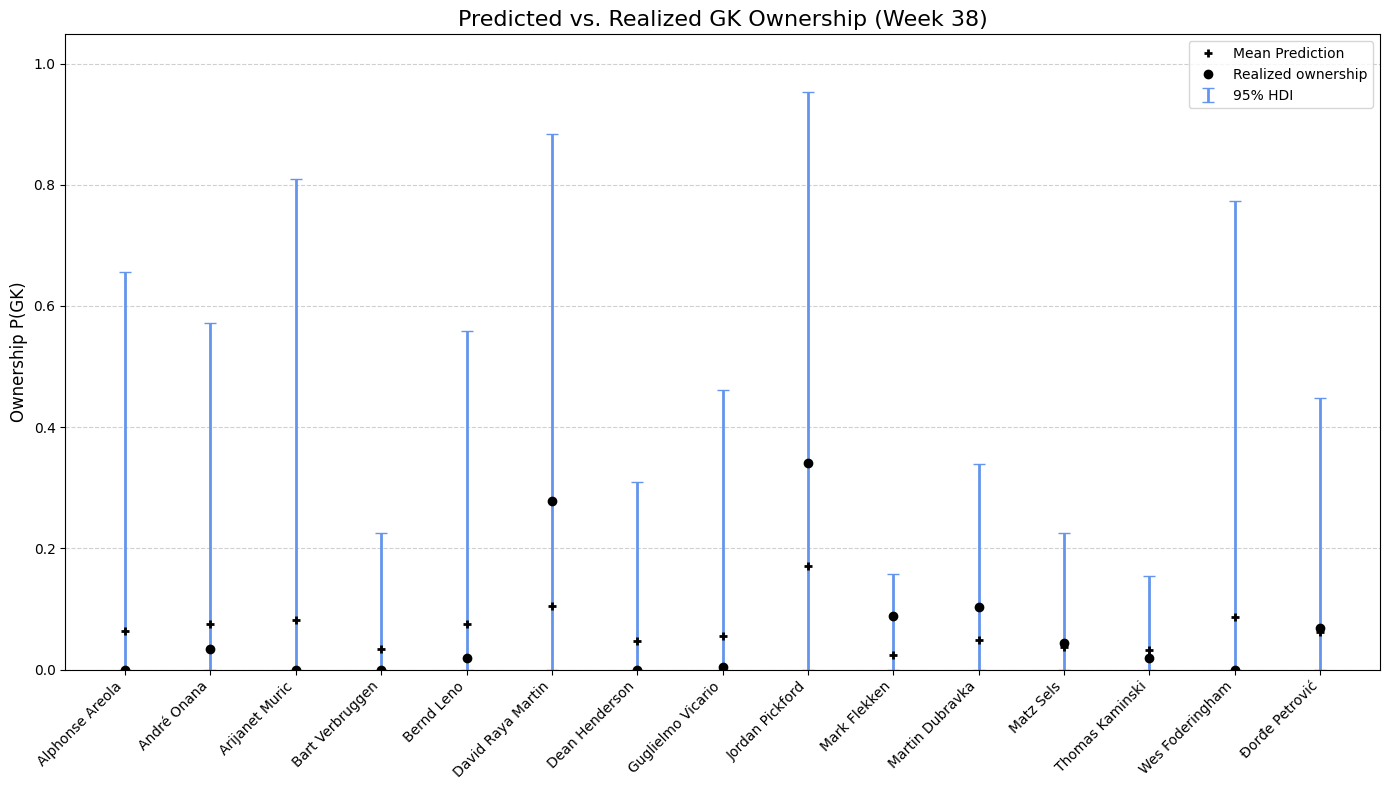

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_gk.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_gk_features = X_pca[0].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_gk[i]

    eta_vector = np.dot(X_gk_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=gk_names,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    gk_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    gk_names,
    gk_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized GK Ownership (Week 38)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(gk_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### DEF


Extracted 2000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_13552\1352292211.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


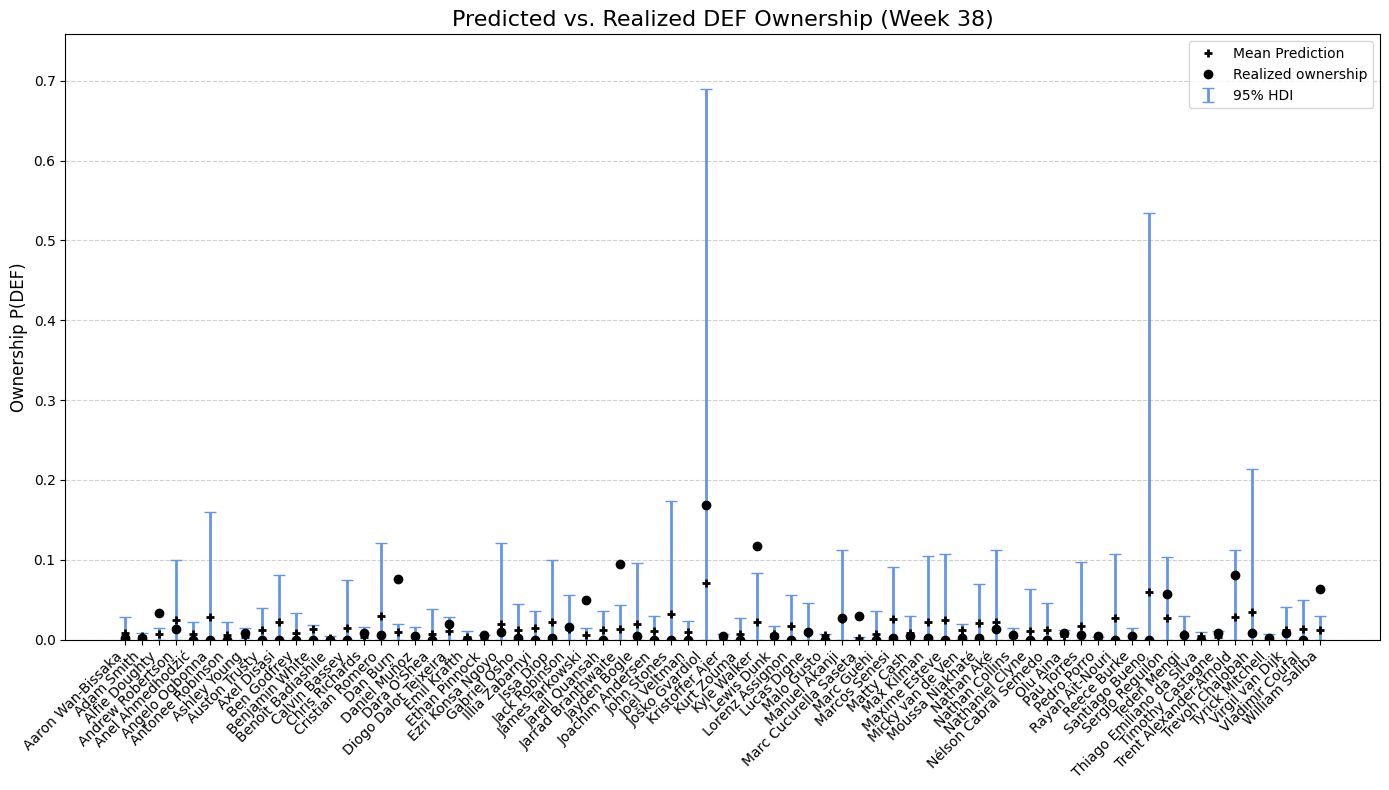

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_def.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_def_features = X_pca[1].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_def[i]

    eta_vector = np.dot(X_def_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=def_names,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    def_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    def_names,
    def_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized DEF Ownership (Week 38)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(def_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### MID


Extracted 2000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_13552\3998312701.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


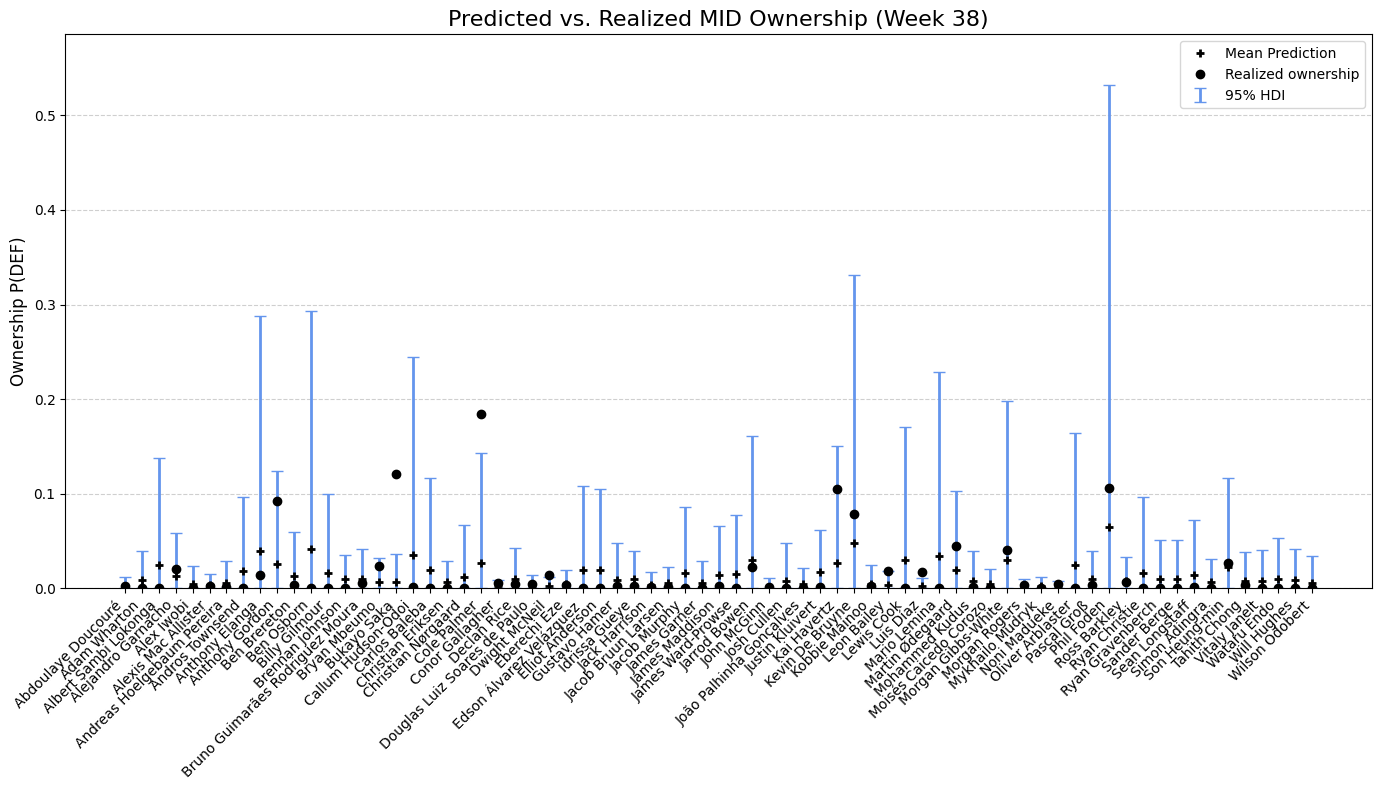

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_mid.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_mid_features = X_pca[2].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_mid[i]

    eta_vector = np.dot(X_mid_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=mid_names,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    mid_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    mid_names,
    mid_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized MID Ownership (Week 38)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### FWD


Extracted 2000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_13552\2704232548.py:29: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


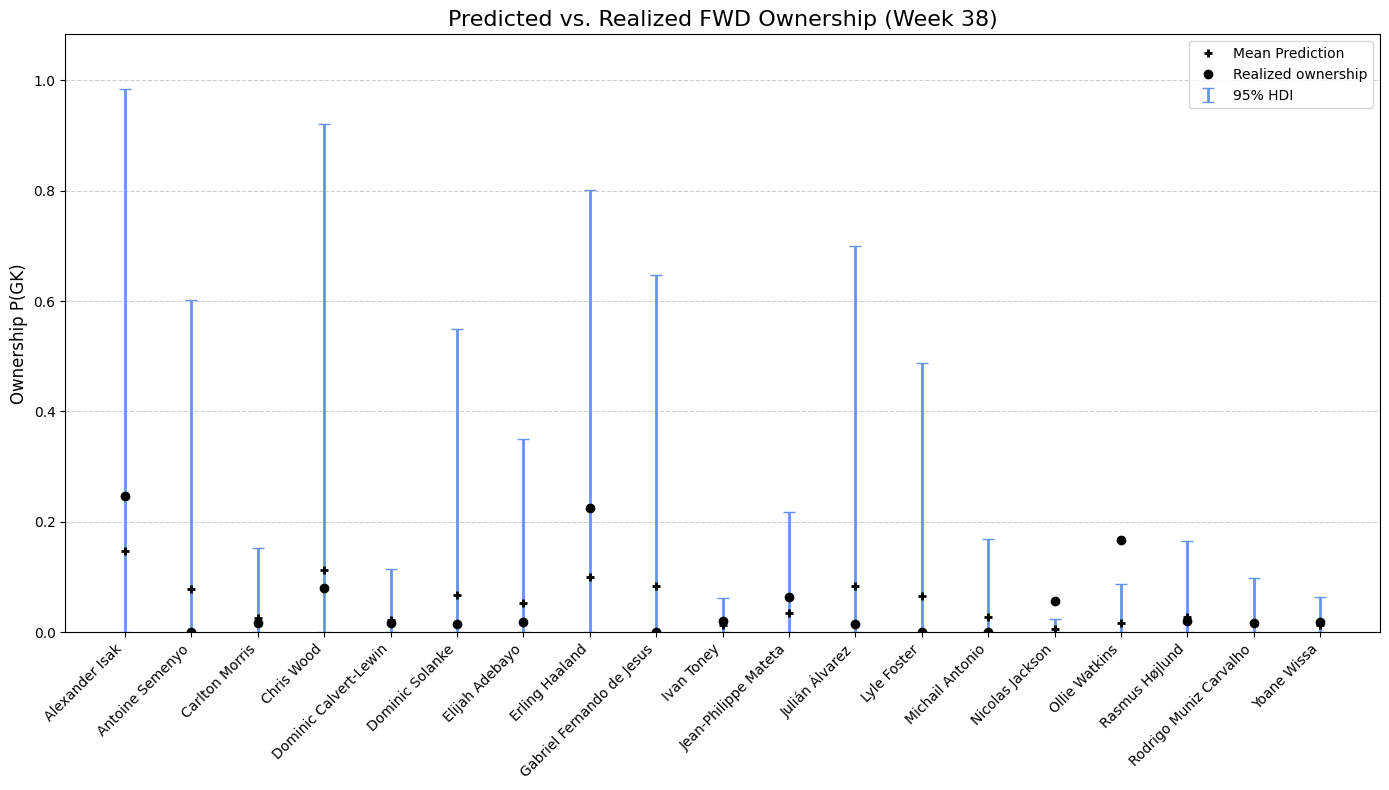

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_fwd.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_fwd_features = X_pca[3].values  # <-- Use .values to get the numpy array

# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_fwd[i]

    eta_vector = np.dot(X_fwd_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_fwdpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=fwd_names,
    y=hdi_fwdpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    fwd_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    fwd_names,
    fwd_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized FWD Ownership (Week 38)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Generate Portfolios


In [ ]:
generated_portfolios = sample_opponent_portfolios(
    O=50,
    batch_size = 100_000,
    beta_estimates=all_beta_estimates,
    feature_matrices=X_pca,
    ids = ids,
    costs=prices,
    budget=80,
    teams=teams,
    xp_preds=xPts,
    p_vectors=p_vectors
    )


Generating 50 opponent portfolios...


⚙️ Using 4 cores to generate 50 teams...
✅ Collected 0 valid teams after 100000 attempts...: 50
🎯 Done! Generated 50 unique portfolios.


In [ ]:
Wo_ = []
for i in generated_portfolios:
    # print(i)
    # Create a tuple of 0s and 1s for each player
    squad = tuple([1 if id_ in i else 0 for id_ in players_preds['FPL_ID'].tolist()])
    Wo_.append(squad)

np.sum(Wo_[0])


4

In [ ]:
teams_costs = []
for team in generated_portfolios:
    cost  = players_preds.loc[list(team), "total_points"].sum()
    teams_costs.append(cost)

# teams_costs

print(len(mu_delta))

176


In [ ]:
# def monte_carlo_simulation(W_o: np.ndarray, mu_delta: np.ndarray, sigma_delta: np.ndarray, Y_observed: np.ndarray, X_obs: np.ndarray, num_samples: int = 500) -> Tuple[np.ndarray, np.ndarray]:
#     """
#     Generate Monte Carlo samples for player performances and opponent scores using PyMC (MCMC).

#     The likelihood function (pm.Normal) is now included to update the delta prior based on
#     historical observed scores (Y_observed) via the design matrix (X_obs).
#     """
#     num_player = len(mu_delta) # Use mu_delta size for player count

#     with pm.Model() as model:
#         sd_dist = pm.HalfNormal.dist(sigma_delta)

#         # Assuming mu_delta is log-transformed, which needs to be exponentiated for player points
#         # If mu_delta is already player points, remove the pm.math.exp()
#         mu_delta_ = pm.Deterministic('mu_delta_', pm.math.exp(mu_delta) + 1e-6)

#         # Priors for the Covariance Structure
#         chol, corr, sigmas = pm.LKJCholeskyCov(
#             'chol_cov', eta=20, n=num_player, sd_dist=sd_dist
#         )
#         cov = pt.dot(chol, chol.T)

#         # Prior for Player Skill (delta)
#         delta = pm.MvNormal("delta", mu=mu_delta_, cov=cov, shape=num_player)

#         # ----------------------------------------------------------------------
#         # >>> LIKELIHOOD FUNCTION: Links latent skill (delta) to observed scores (Y_observed)
#         # ----------------------------------------------------------------------
#         obs_sigma = pm.HalfNormal("obs_sigma", 1) # Noise term for observed scores

#         # Expected scores calculation: Design matrix (X_obs) * Player skills (delta)
#         # X_obs must have shape (N_observations, N_players)
#         expected_scores = pt.dot(X_obs, delta)

#         # Likelihood term: How probable the actual scores (Y_observed) are given the model's expectations
#         pm.Normal("observed_scores", mu=expected_scores, sigma=obs_sigma, observed=Y_observed)
#         # ----------------------------------------------------------------------

#         # G_r calculation: 90th percentile of opponent performance (W_o @ delta)
#         G_r = pm.Deterministic("G_r", pt.sort(pt.dot(W_o, delta))[-int(len(W_o) * 0.9)])

#         print("Running MCMC Sampler...")
#         # Note: Increase 'tune' and 'num_samples' for production use.
#         trace = pm.sample(num_samples, tune=500, return_inferencedata=True, cores=2, progressbar=True)

#     delta_samples = trace.posterior["delta"].values.reshape(-1, num_player)
#     G_r_samples = trace.posterior["G_r"].values.flatten()

#     return delta_samples, G_r_samples


In [ ]:
# MC_sim_trace = monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta)

hist_data = data_23_24[data_23_24['fpl_id'].isin(players_preds[players_preds['event'] == 38]['fpl_id'])]['total_points'].dropna()
hist_data.shape

(0,)

In [ ]:

hist_data = data_23_24[data_23_24['fpl_id'].isin(players_preds[players_preds['event'] == 38]['fpl_id'])]['total_points'].dropna()
hist_data.shape

# Assuming total FPL players (P) is 500 for MCMC robustness, even if optimization uses 50.
P_MCMC = len(data_23_24[data_23_24['fpl_id'].isin(players_preds[players_preds['event'] == 38]['fpl_id'])]['fpl_id'].unique())
N_OBSERVATIONS = len(hist_data) # Based on your historical data shape

# MOCK DATA FOR MCMC INPUTS (Based on expected shapes)
# delta_samples_mock and G_r_samples_mock are derived from this step.
delta_samples_mock = np.random.normal(loc=1.0, scale=0.5, size=(5000, P_MCMC))
G_r_samples_mock = np.random.normal(loc=15.0, scale=3.0, size=5000)
lambdas_mock = np.linspace(0.0, 0.5, 6)

# X_obs: Shape (N_OBSERVATIONS, P_MCMC). Sparse matrix linking observation to player.
X_obs = (np.random.rand(N_OBSERVATIONS, P_MCMC) > 0.98).astype(int)
# Y_observed: Shape (N_OBSERVATIONS,). Actual historical scores (total_points).
Y_observed = np.array(hist_data) #np.random.uniform(0, 15, N_OBSERVATIONS)
# W_o: Opponent matrix for GW 38 (N_OPPONENT_MATCHES, P_MCMC)
# W_o_mock = (np.random.rand(10, P_MCMC) > 0.99).astype(float)


In [ ]:
def monte_carlo_simulation(W_o: np.ndarray, mu_delta: np.ndarray, sigma_delta: np.ndarray, Y_observed: np.ndarray, X_obs: np.ndarray):
    """
    Generate Monte Carlo samples for player performances and opponent scores using PyMC (MCMC).

    The likelihood function (pm.Normal) is now included to update the delta prior based on
    historical observed scores (Y_observed) via the design matrix (X_obs).
    """
    # num_player should be the size of the full MCMC player pool (P)
    num_samples = len(mu_delta)
    num_player = len(mu_delta)

    with pm.Model() as model:
        # Prior for standard deviations, derived from the historical xP variance
        sd_dist = pm.HalfNormal.dist(sigma_delta)

        # Assuming mu_delta is linear expected points, use it directly as the mean skill level.
        mu_delta_ = mu_delta #pm.Deterministic('mu_delta_', mu_delta + 1e-6)

        # Priors for the Covariance Structure
        chol, corr, sigmas = pm.LKJCholeskyCov(
            'chol_cov', eta=20, n=num_player, sd_dist=sd_dist
        )
        cov = pt.dot(chol, chol.T)

        # Prior for Player Skill (delta)
        delta = pm.MvNormal("delta", mu=mu_delta_, cov=cov, shape=num_player)

        # ----------------------------------------------------------------------
        # >>> LIKELIHOOD FUNCTION: Links latent skill (delta) to observed scores (Y_observed)
        # ----------------------------------------------------------------------
        # Y_observed should be historical total_points (11,294 observations)
        obs_sigma = pm.HalfNormal("obs_sigma", 1) # Noise term for observed scores

        # Expected scores calculation: Design matrix (X_obs) * Player skills (delta)
        expected_scores = pt.dot(X_obs, delta)

        # Likelihood term: How probable the actual scores (Y_observed) are given the model's expectations
        pm.Normal("observed_scores", mu=expected_scores, sigma=obs_sigma, observed=Y_observed)
        # ----------------------------------------------------------------------

        # G_r calculation: 90th percentile of opponent performance (W_o @ delta)
        G_r = pm.Deterministic("G_r", pt.sort(pt.dot(W_o, delta))[-int(len(W_o) * 0.9)])

        print("Running MCMC Sampler...")
        # Note: Increase 'tune' and 'num_samples' for production use.
        # trace = pm.sample(num_samples, tune=500, return_inferencedata=True, cores=2, progressbar=True)

        approx = pm.fit(n=2000, method='advi', progressbar=True)
        trace = approx.sample(2000)


    delta_samples = trace.posterior["delta"].values.reshape(-1, num_player)
    G_r_samples = trace.posterior["G_r"].values.flatten()

    return delta_samples, G_r_samples


In [ ]:
MC_sim_trace = monte_carlo_simulation(Wo_, mu_delta, sigma_delta, Y_observed, X_obs)


Running MCMC Sampler...


ValueError: Incompatible Elemwise input shapes [(0,), (176,)]

In [ ]:
delta_samples = MC_sim_trace[0]
G_r_samples = MC_sim_trace[1]

In [ ]:

# def make_positive_definite(cov_mat, epsilon=1e-6):
#     # Ensure symmetry
#     cov_mat = (cov_mat + cov_mat.T) / 2

#     # Add jitter to diagonal
#     jitter = epsilon * np.eye(cov_mat.shape[0])
#     return cov_mat + jitter


# def monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta):
#     num_player = len(Wo_[0])

#     cov_mat = make_positive_definite(cov_mat)
#     L = np.linalg.cholesky(cov_mat)

#     with pm.Model() as model:
#         # Define the Multivariate Normal distribution for delta
#         delta = pm.MvNormal("delta", mu=mu_delta, chol=L, shape=num_player)

#         pm.Normal("observed_scores", mu=expected_scores, sigma=obs_sigma, observed=Y_observed)
#         # Inference using MCMC (NUTS sampler)
#         # trace = pm.sample(draws=2000, tune=1000, chains=4, target_accept=0.99, random_seed=42)
#         print("Running ADVI Optimization...")
#         # Using ADVI (Variational Inference) instead of NUTS (MCMC)
#         # n=30000 gives the optimizer time to converge
#         approx = pm.fit(n=30000, method='advi', random_seed=42)

#         print("Sampling from Posterior Approximation...")
#         # Draw samples from the approximated distribution
#         trace = approx.sample(draws=1000, random_seed=42)
#         # print("Running NUTS Sampler...")
#         # trace = pm.sample(draws=2000, chains=4, tune=1000, cores=4,  progressbar=True)

#     return trace

# MC_sim_trace = monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta)


Running ADVI Optimization...


Output()

Finished [100%]: Average Loss = 746.58


Sampling from Posterior Approximation...


In [ ]:
# # --- STEP 2: FAST POST-PROCESSING ---
# # Calculate G_r using optimized NumPy operations on the results
# print("Post-processing G_r...")

# # Extract delta samples: Shape (chains, draws, n_players)
# delta_samples = MC_sim_trace.posterior["delta"].values

# # Compute dot product via broadcasting:
# # (chains, draws, n_players) @ (n_players, n_items) -> (chains, draws, n_items)
# dot_products = np.dot(delta_samples, np.array(Wo_, dtype=float).T)

# # Compute 90th percentile across the items axis (last axis)
# # NumPy sort is much faster than PyTensor sort inside the loop
# g_r_samples = np.percentile(dot_products, 90, axis=-1)

# # --- STEP 3: UPDATE TRACE ---
# # Add G_r back into the MC_sim_trace object so az.summary() works as expected
# MC_sim_trace.posterior["G_r"] = (("chain", "draw"), g_r_samples)


# # return trace

# az.plot_trace(MC_sim_trace, var_names=["delta", "G_r"])
# az.summary(MC_sim_trace, var_names=["delta", "G_r"])

In [ ]:
# delta_samples = MC_sim_trace.posterior['delta'].stack(sample=("chain", "draw")).values.T  # shape (N_samples, 226)
# G_r_samples   = MC_sim_trace.posterior['G_r'].stack(sample=("chain", "draw")).values.T    # shape (N_samples, 200)

G_r_scalar = np.percentile(G_r_samples, 90)  # shape (N_samples,)

mu_delta, cov_delta, mu_G, var_G, cov_delta_G, sigma_G = generate_cov_delta(delta_samples, G_r_samples)

# mu_delta, cov_delta, mu_G, var_G, cov_delta_G, sigma_G
# G_r_scalar.shape

(2000, 186) (2000,)


In [ ]:
lambdas = np.linspace(0.0, 0.5, 6)
best_lambda, best_w, best_prob = optimize_portfolio(add_fantasy_constraints, mu_delta, cov_delta, mu_G, var_G, cov_delta_G, lambdas, delta_samples, G_r_scalar, players_preds)
print(f"Best λ: {best_lambda}, Best Probability of Outperforming: {best_prob}")

selected, player_names, total_points, team_cost, formation = selected_info(best_w, fpl_teams_ids, players_preds, fg_managers_38)
print('fpl_ids: ', selected, '\nfpl_names: ', player_names, '\ntotal_points: ', total_points, '\nteam_cost: ', team_cost, '\nformation: ', formation)

DEBUG: Found players - GK: 16, DEF: 73, MID: 76, FWD: 21
costs------------------ 186
Checking feasibility...
Best λ: 0.0, Best Probability of Outperforming: 1.0
[ 2.  3.  2.  2. 12.  1.  6.  2.  5.  3.  1.] ---------> [2.18347788 2.768      3.74882179 3.02395807 4.4347657  1.712
 1.688      2.68301466 2.54588769 3.8838224  0.52230045]
Your predicted player’s total of 39.0 points would rank:
→ Position: 226 out of 229 managers
→ Percentile: Top 1.31%

Closest scores around you:
   points prize
0    44.0   NaN
1    39.5   NaN
2    39.0   NaN
3    35.0   NaN
4    34.0   NaN
fpl_ids:  [415, 597, 19, 355, 349, 430, 369, 303, 60, 516, 290] 
fpl_names:  ['Alexander Isak', 'André Onana', 'Bukayo Saka', 'Erling Haaland', 'Kevin De Bruyne', 'Kieran Trippier', 'Kyle Walker', 'Luis Díaz', 'Ollie Watkins', 'Son Heung-min', 'Trent Alexander-Arnold'] 
total_points:  39.0 
team_cost:  94.00000000000001 
formation:  [1, 3, 4, 3]


In [ ]:
players_preds[players_preds['fpl_id'].isin(selected)][['fpl_name', 'team', 'position', 'xP_preds', 'total_points', 'value']]

,fpl_name,team,position,xP_preds,total_points,value
7,Alexander Isak,Newcastle United,FWD,2.183478,2,8.4
12,André Onana,Manchester United,GK,2.768000,3,5.0
31,Bukayo Saka,Arsenal,MID,3.748822,2,8.9
63,Erling Haaland,Manchester City,FWD,3.023958,2,14.2
97,Kevin De Bruyne,Manchester City,MID,4.434766,6,10.6
98,Kieran Trippier,Newcastle United,DEF,1.712000,1,6.6
102,Kyle Walker,Manchester City,DEF,1.688000,6,5.5
110,Luis Díaz,Liverpool,MID,2.683015,2,7.6
144,Ollie Watkins,Aston Villa,FWD,2.545888,5,8.9
163,Son Heung-min,Tottenham Hotspur,MID,3.883822,2,9.9


In [ ]:
def calculate_portfolio_metrics(w, delta_samples, G_r_samples):
    """
    Calculates advanced evaluation metrics for a selected team (w).
    """
    # 1. Calculate the raw score distribution for My Team
    my_score_dist = np.dot(delta_samples, w)

    # 2. Calculate the "Active Return" (My Score - Target Score)
    excess_dist = my_score_dist - G_r_samples

    # --- METRIC: Win Probability ---
    prob_win = np.mean(excess_dist > 0)

    # --- METRIC: Expected Score & Excess ---
    mean_score = np.mean(my_score_dist)
    mean_excess = np.mean(excess_dist)

    # --- METRIC: Volatility (Risk) ---
    std_excess = np.std(excess_dist)

    # --- METRIC: Sharpe Ratio (Efficiency) ---
    # Measures return per unit of risk. Higher is better.
    sharpe = mean_excess / std_excess if std_excess > 0 else 0

    # --- METRIC: Information Ratio (IR) ---
    # In this context, similar to Sharpe, but conceptually focuses on tracking error.
    ir = mean_excess / std_excess if std_excess > 0 else 0

    # --- METRIC: Value at Risk (VaR 5%) ---
    # The score you will exceed 95% of the time. (Worst case scenario safety net).
    var_5 = np.percentile(my_score_dist, 5)

    return {
        "prob_win": prob_win,
        "mean_score": mean_score,
        "mean_excess": mean_excess,
        "sharpe": sharpe,
        "ir": ir,
        "var_5": var_5
    }


all_ids = np.concatenate(ids)
selected_ind = [1 if i in selected else 0 for i in all_ids]
calculate_portfolio_metrics(selected_ind, delta_samples, G_r_samples)

{'prob_win': 1.0,
 'mean_score': 3.573691183219592,
 'mean_excess': 3.5833937334808925,
 'sharpe': 3.6439918608589745,
 'ir': 3.6439918608589745,
 'var_5': 1.9965519015159232}

# GW 37\*


In [ ]:
players_preds = pd.read_csv(f'../FPL predictors/Fantasy Go/fantasyGo_preds_37.csv', index_col=0)
# Check if teams match
players_preds = players_preds[players_preds['player_team'].isin(FPL_teams_23_24)]

players_preds['xP_cost'] = round(players_preds['xP']/players_preds['value'], 2)

data_23_24['xP_cost'] = round(data_23_24['xP']/data_23_24['value'], 2)
data_23_24_37 = data_23_24[data_23_24['event'] < 36]

# # Add fpl_id to player_preds
players_preds = players_preds.merge(fpl_teams_ids, left_on='fpl_name', right_on='FPL_Name', how='left')

## Generate Cov_Mat


In [ ]:
mu_delta, sigma_delta, cov_mat, valid_player_ids = generate_cov_mat(players_preds, data_23_24_37)
# cov_mat
players_preds = players_preds[players_preds['fpl_id'].isin(valid_player_ids)]

Starting to optimize team selection...
(204, 189)
(5058, 180)
(204,) (204,) (204, 204)


## Data Preparations


In [ ]:
data_cols.append('fpl_id')
data_cols_gk.append('fpl_id')

data_23_24_37 = data_23_24_37[data_23_24_37['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
players_preds = players_preds[players_preds['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
data, prices, xPts, positions , teams, ids, X_pca = clean_data(players_preds, valid_player_ids)

starting to clean data...
data successfully cleaned...


In [ ]:
ownership_gk = players_preds[players_preds['position'] == 'GK']['ownership_percent']
gk_names = players_preds[players_preds['position'] == 'GK']['FPL_Name']
gk_probs_obs = ownership_gk / ownership_gk.sum()

ownership_def = players_preds[players_preds['position'] == 'DEF']['ownership_percent']
def_names = players_preds[players_preds['position'] == 'DEF']['FPL_Name']
def_probs_obs = ownership_def / ownership_def.sum()

cols = data_cols.copy()
cols.append('ownership_percent')
cols.append('FPL_Name')

# mids = players_preds[players_preds['position'] == 'MID'][cols].dropna()
# ownership_mid = mids['ownership_percent']
# mid_names = mids['FPL_Name']
# mid_probs_obs = ownership_mid / ownership_mid.sum()

ownership_mid = players_preds[players_preds['position'] == 'MID']['ownership_percent']
mid_names = players_preds[players_preds['position'] == 'MID']['FPL_Name']
mid_probs_obs = ownership_mid / ownership_mid.sum()


cols = feats_cols_fwd.copy()
cols.append('FPL_Name')
fwds = players_preds[players_preds['position'] == 'FWD'][cols].dropna()
ownership_fwds = fwds['ownership_percent']
fwd_names = fwds['FPL_Name']
fwd_probs_obs = ownership_fwds / ownership_fwds.sum()

In [ ]:
print(X_pca[0].shape, X_pca[1].shape, X_pca[2].shape)
print(beta_gk.shape, beta_def.shape, beta_mid.shape)

(14, 12) (66, 13) (93, 11)
(12000, 12) (12000, 13) (12000, 11)


In [ ]:
alphas = {
        'GK': np.exp(X_pca[0] @ beta_gk.T).mean(axis=1),
        'DEF': np.exp(X_pca[1] @ beta_def.T).mean(axis=1),
        'MID': np.exp(X_pca[2] @ beta_mid.T).mean(axis=1),
        'FWD': np.exp(X_pca[3] @ beta_fwd.T).mean(axis=1)
    }


p_vectors = {pos: np.random.dirichlet(alpha) for pos, alpha in alphas.items()}
p_vectors

{'GK': array([4.31281860e-02, 8.10981000e-02, 2.22770443e-02, 3.73466018e-06,
        2.69240961e-04, 5.65661920e-04, 1.12726784e-05, 1.83464371e-01,
        5.92210959e-01, 6.02797762e-03, 8.69223305e-04, 6.98321325e-02,
        7.73326671e-05, 1.64763897e-04]),
 'DEF': array([5.54119597e-04, 3.33390332e-04, 1.62047880e-04, 2.84935334e-05,
        1.13194869e-03, 5.95434233e-13, 2.73250063e-03, 2.47202082e-03,
        2.26324192e-05, 4.78746110e-05, 1.81647797e-04, 2.31318641e-06,
        1.76249772e-02, 1.16557943e-01, 3.13913767e-01, 4.26977652e-04,
        2.59482025e-03, 3.16569141e-06, 6.03409570e-05, 5.88425019e-06,
        2.26806262e-04, 8.18831715e-05, 6.07553883e-07, 1.30659587e-04,
        8.93668805e-03, 2.51626539e-03, 9.69928329e-02, 6.82180878e-04,
        2.70622696e-04, 7.48891567e-06, 3.36874578e-04, 1.64721247e-03,
        4.86480296e-08, 7.86356165e-03, 3.21546443e-02, 6.55211207e-03,
        4.49374116e-03, 1.47960615e-05, 1.06263053e-03, 1.70299882e-03,
        9

## Plots


### GK


Extracted 12000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_7896\4096672833.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


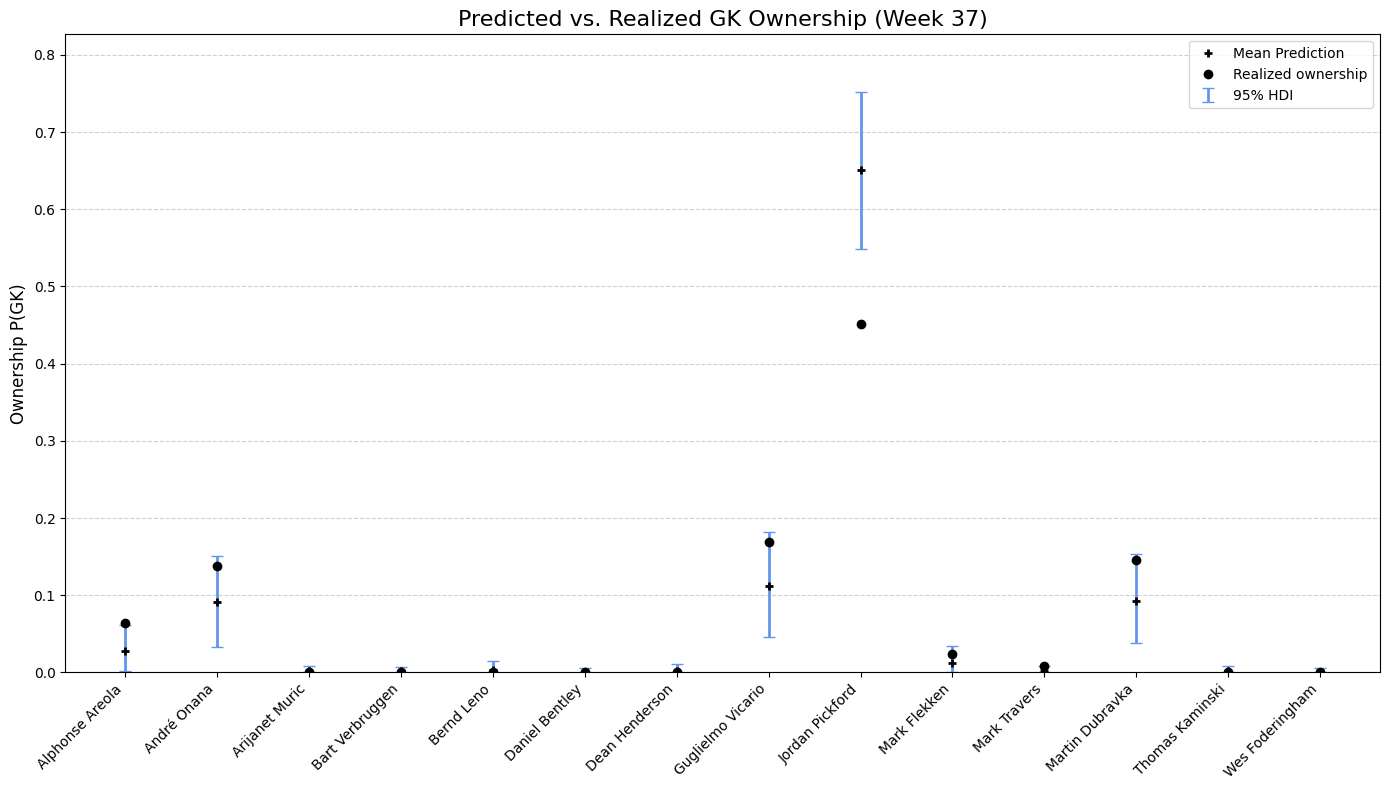

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_gk.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_gk_features = X_pca[0].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_gk[i]

    eta_vector = np.dot(X_gk_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=gk_names,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    gk_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    gk_names,
    gk_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized GK Ownership (Week 37)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(gk_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### DEF


Extracted 12000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_7896\2654067066.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


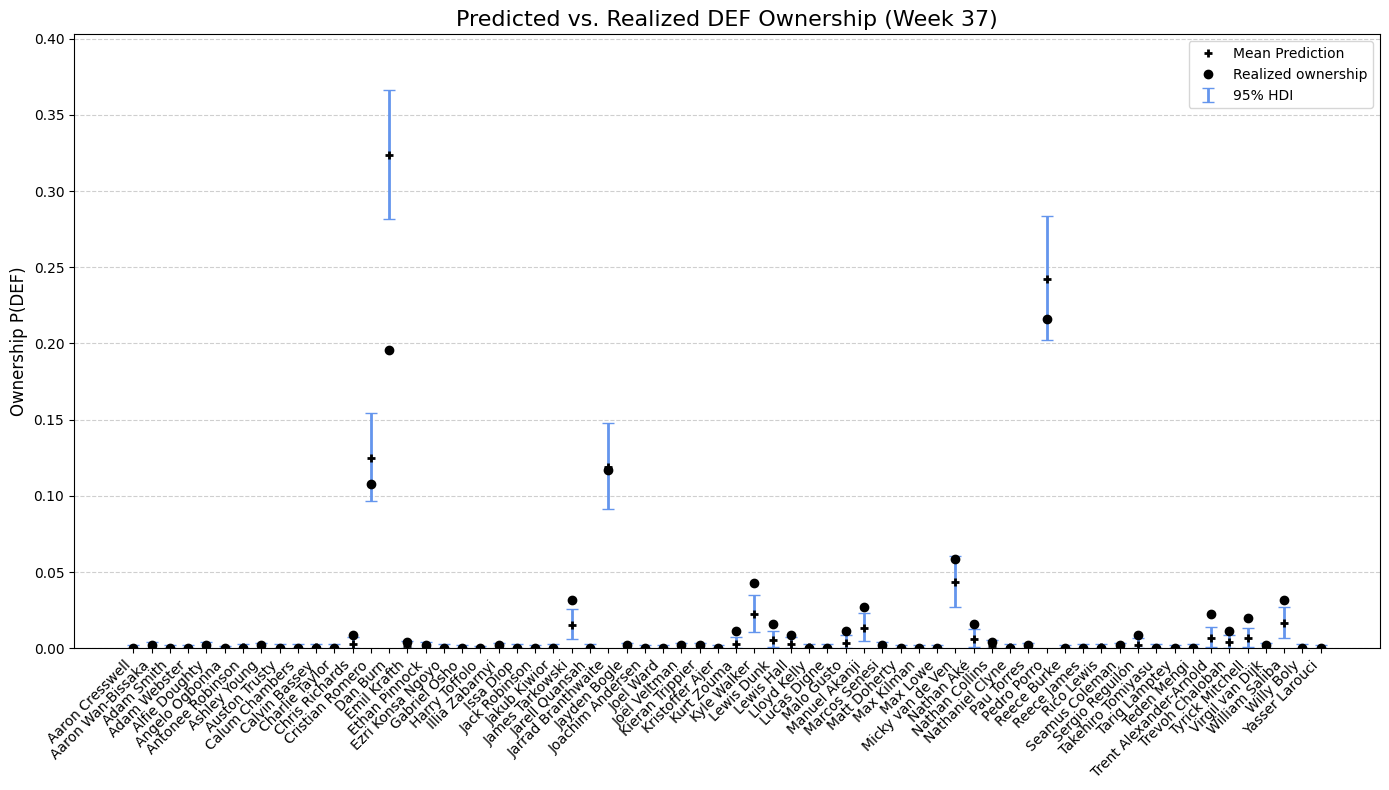

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_def.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_def_features = X_pca[1].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_def[i]

    eta_vector = np.dot(X_def_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=def_names,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    def_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    def_names,
    def_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized DEF Ownership (Week 37)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(def_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### MID


Extracted 12000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_7896\3360249588.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


(93,) 93


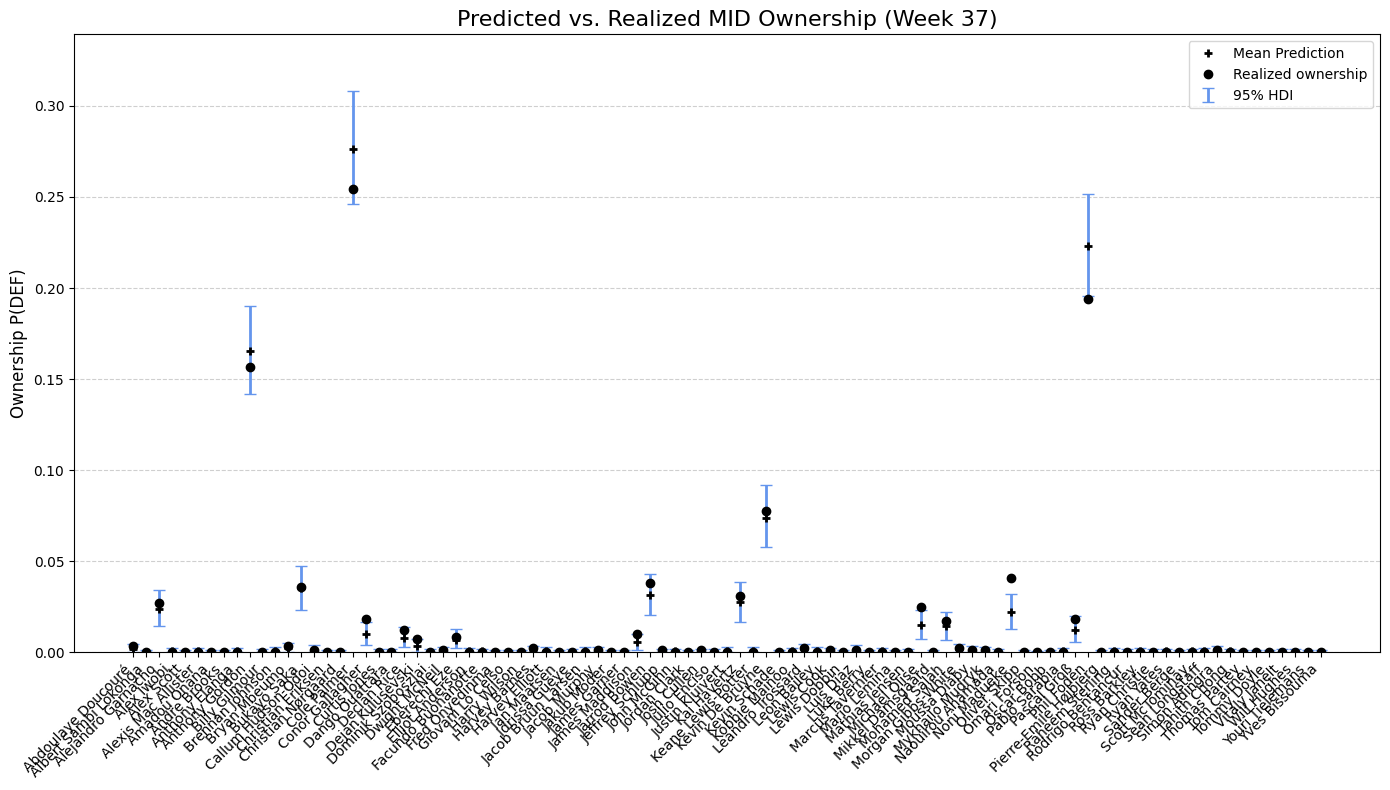

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_mid.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_mid_features = X_pca[2].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_mid[i]

    eta_vector = np.dot(X_mid_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))

print(mid_names.shape, len(hdi_midpoint))

# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=mid_names,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    mid_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    mid_names,
    mid_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized MID Ownership (Week 37)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### FWD


Extracted 12000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_7896\4259362983.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


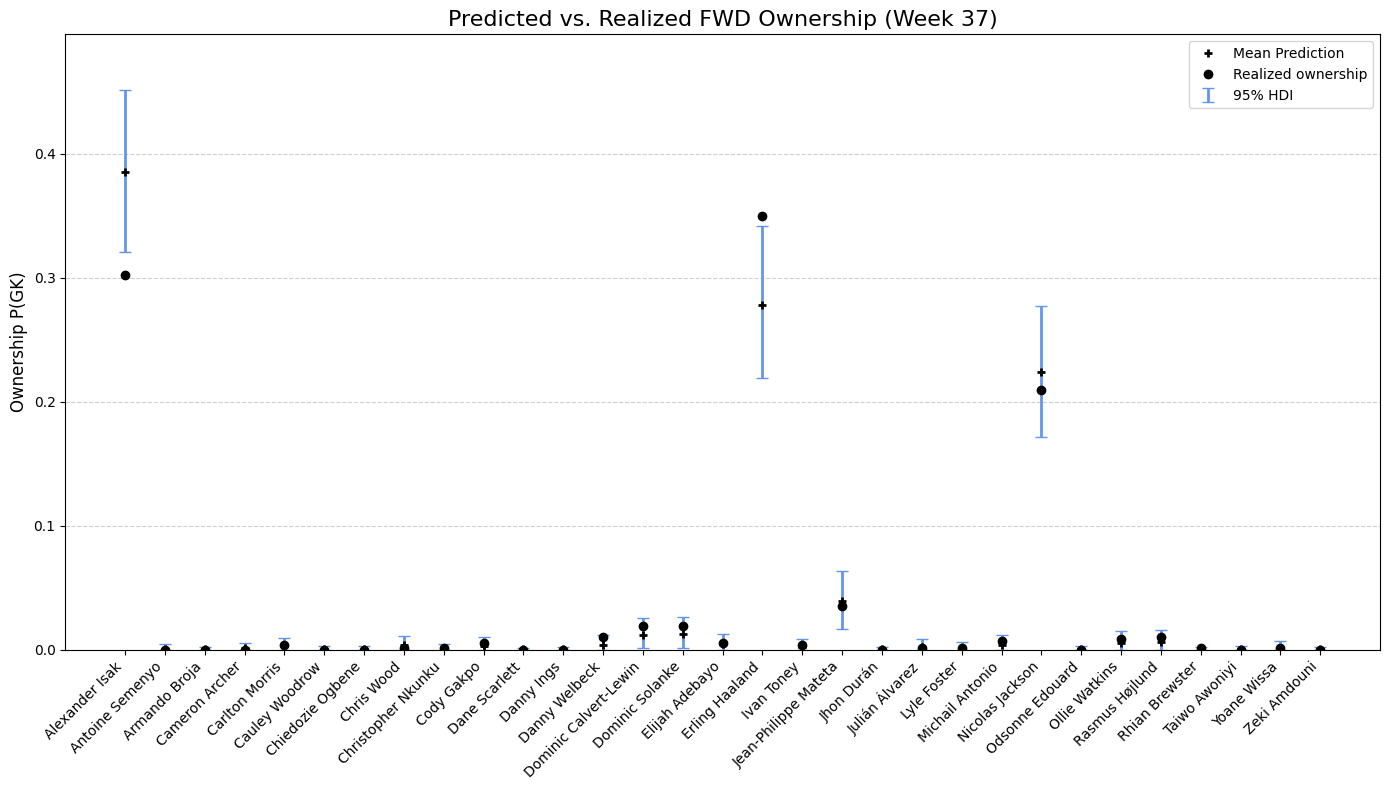

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_fwd.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_fwd_features = X_pca[3].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_fwd[i]

    eta_vector = np.dot(X_fwd_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_fwdpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=fwd_names,
    y=hdi_fwdpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    fwd_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    fwd_names,
    fwd_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized FWD Ownership (Week 37)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Generate Portfolios


In [ ]:
generated_portfolios = sample_opponent_portfolios(
    O=200,
    batch_size = 2000,
    beta_estimates=all_beta_estimates,
    feature_matrices=X_pca,
    ids = ids,
    costs=prices,
    budget=100,
    teams=teams,
    xp_preds=xPts,
    p_vectors=p_vectors)


Generating 200 opponent portfolios...
⚙️ Using 4 cores to generate 200 teams...
✅ Collected 0 valid teams after 2000 attempts...: 0
✅ Collected 0 valid teams after 4000 attempts...: 1
✅ Collected 0 valid teams after 6000 attempts...: 1
✅ Collected 0 valid teams after 8000 attempts...: 1
✅ Collected 0 valid teams after 10000 attempts...: 1
✅ Collected 0 valid teams after 12000 attempts...: 1
✅ Collected 0 valid teams after 14000 attempts...: 1
✅ Collected 0 valid teams after 16000 attempts...: 1
✅ Collected 0 valid teams after 18000 attempts...: 1
✅ Collected 0 valid teams after 20000 attempts...: 1
✅ Collected 0 valid teams after 22000 attempts...: 1
✅ Collected 0 valid teams after 24000 attempts...: 2
✅ Collected 0 valid teams after 26000 attempts...: 2
✅ Collected 0 valid teams after 28000 attempts...: 2
✅ Collected 0 valid teams after 30000 attempts...: 2
✅ Collected 0 valid teams after 32000 attempts...: 2
✅ Collected 0 valid teams after 34000 attempts...: 2
✅ Collected 0 valid te

In [ ]:
Wo_ = []
for i in generated_portfolios:
    # Create a tuple of 0s and 1s for each player
    squad = tuple([1 if id_ in i else 0 for id_ in valid_player_ids])
    Wo_.append(squad)

Output()

Finished [100%]: Average Loss = 17,810
arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
delta[0],4.853,0.021,4.814,4.894,0.001,0.000,1026.0,983.0,NaN
delta[1],1.664,0.021,1.627,1.704,0.001,0.000,896.0,942.0,NaN
delta[2],0.731,0.018,0.700,0.767,0.001,0.000,1028.0,941.0,NaN
delta[3],5.837,0.022,5.793,5.877,0.001,0.000,1086.0,984.0,NaN
delta[4],5.099,0.019,5.065,5.134,0.001,0.000,1053.0,1021.0,NaN
...,...,...,...,...,...,...,...,...,...
G_r[195],47.231,0.076,47.086,47.358,0.002,0.002,993.0,1020.0,NaN
G_r[196],42.505,0.071,42.376,42.643,0.002,0.002,854.0,914.0,NaN
G_r[197],50.053,0.074,49.907,50.181,0.002,0.002,1013.0,835.0,NaN
G_r[198],46.430,0.077,46.294,46.583,0.002,0.002,963.0,872.0,NaN


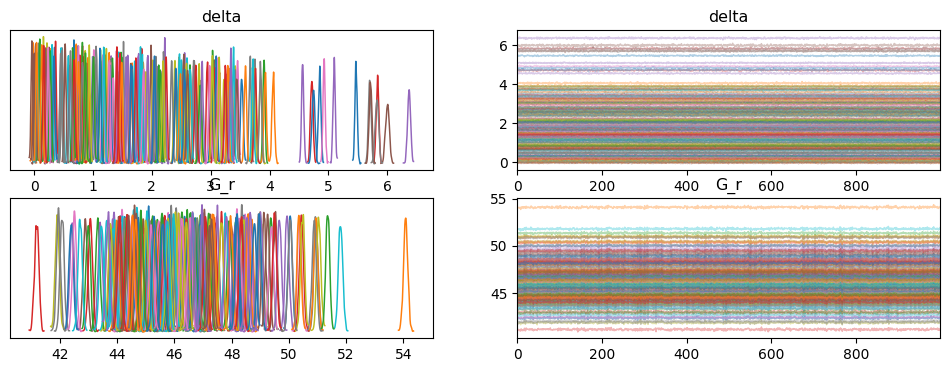

In [ ]:
def make_positive_definite(cov_mat, epsilon=1e-6):
    # Ensure symmetry
    cov_mat = (cov_mat + cov_mat.T) / 2

    # Add jitter to diagonal
    jitter = epsilon * np.eye(cov_mat.shape[0])
    return cov_mat + jitter


def monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta):
    num_player = len(Wo_[0])

    cov_mat = make_positive_definite(cov_mat)

    with pm.Model() as model:
        L = np.linalg.cholesky(make_positive_definite(cov_mat))
        delta = pm.MvNormal("delta", mu=mu_delta, chol=L, shape=num_player)
        # delta = pm.MvNormal("delta", mu=mu_delta, cov=cov_mat, shape=num_player)

        # Compute 90th percentile of performance
        dot_product = pt.dot(Wo_, delta)
        G_r = pm.Deterministic("G_r",  np.percentile(dot_product, 90)) # pt.sort(dot_product)[-int(len(Wo_) * 0.9)])

        approx = pm.fit(method='advi', n=20000)

        trace = approx.sample(1000)
        # trace = pm.sample(
        #     3000,
        #     return_inferencedata=True,
        #     cores=2,
        #     chains=10,
        #     progressbar=True,
        #     target_accept=0.95
        # )

        # G_r_90 = np.percentile(pt.dot(trace.posterior['delta'].values, Wo_), 90)

    return trace
MC_sim_trace = monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta)

az.plot_trace(MC_sim_trace, var_names=["delta", "G_r"])
az.summary(MC_sim_trace, var_names=["delta", "G_r"])

In [ ]:
delta_samples = MC_sim_trace.posterior['delta'].stack(sample=("chain", "draw")).values.T  # shape (N_samples, 226)
G_r_samples   = MC_sim_trace.posterior['G_r'].stack(sample=("chain", "draw")).values.T    # shape (N_samples, 200)

G_r_scalar = np.percentile(G_r_samples, 90, axis=1)  # shape (N_samples,)
print(G_r_scalar.shape, delta_samples.shape)

mu_delta, cov_delta, mu_G, var_G, cov_delta_G, sigma_G = generate_cov_delta(delta_samples, G_r_scalar)


(1000,) (1000, 204)
(1000, 204) (1000,)


In [ ]:
lambdas = np.linspace(0.0, 0.5, 6)
best_lambda, best_w, best_prob = optimize_portfolio(W_constraints, mu_delta, cov_delta, mu_G, var_G, cov_delta_G, lambdas, delta_samples, G_r_scalar, players_preds)
print(f"Best λ: {best_lambda}, Best Probability of Outperforming: {best_prob}")
selected, player_names, total_points = selected_info(best_w, fpl_teams_ids, players_preds, fg_managers_37)
selected, player_names, total_points

204 204
204 204 {'Fulham', 'Brighton and Hove Albion', 'Sheffield United', 'Crystal Palace', 'Newcastle United', 'Nottingham Forest', 'Manchester United', 'Arsenal', 'Manchester City', 'Liverpool', 'Bournemouth', 'Luton', 'Tottenham Hotspur', 'Everton', 'Chelsea', 'West Ham United', 'Burnley', 'Aston Villa', 'Brentford', 'Wolverhampton Wanderers'}
Fulham [20, 26, 33, 75, 81, 188] 6 204
Brighton and Hove Albion [4, 25, 27, 54, 69, 87, 104, 105, 121, 160, 180, 184] 12 204
Sheffield United [14, 24, 83, 94, 139, 169, 195, 199] 8 204
Crystal Palace [39, 55, 62, 95, 96, 98, 99, 140, 148, 151, 154, 192, 196] 13 204
Newcastle United [9, 18, 49, 64, 65, 76, 85, 112, 122, 135, 178] 11 204
Nottingham Forest [17, 28, 31, 40, 74, 145, 174, 182, 198] 9 204
Manchester United [1, 6, 15, 41, 113, 157, 166, 176, 179] 9 204
Arsenal [30, 56, 86, 108, 117, 183, 187, 197] 8 204
Manchester City [45, 66, 106, 110, 116, 129, 149, 158, 163, 170] 10 204
Liverpool [10, 44, 48, 60, 77, 91, 125, 144, 190, 193] 10 2

([19, 20, 60, 263, 308, 313, 343, 353, 355, 362, 369],
 ['Bukayo Saka',
  'William Saliba',
  'Ollie Watkins',
  'Jordan Pickford',
  'Mohamed Salah',
  'Virgil van Dijk',
  'Julián Álvarez',
  'Phil Foden',
  'Erling Haaland',
  'Cole Palmer',
  'Kyle Walker'],
 65.0)

In [ ]:
selected, player_names, total_points = selected_info(best_w, fpl_teams_ids, players_preds, fg_managers_37)
selected, player_names, total_points

[ 3.  6.  2.  8.  5.  6.  2.  5. 18.  1.  9.] ---------> [4.00510161 3.41600723 3.20246962 1.906      2.76811747 1.80099999
 2.90345529 3.5959465  4.91468495 1.21157122 0.58862385]
Your predicted player’s total of 65.0 points would rank:
→ Position: 238 out of 243 managers
→ Percentile: Top 2.06%

Closest scores around you:
   points prize
0    69.5   NaN
1    67.0   NaN
2    63.5   NaN
3    60.0   NaN
4    57.5   NaN


([19, 20, 60, 263, 308, 313, 343, 353, 355, 362, 369],
 ['Bukayo Saka',
  'William Saliba',
  'Ollie Watkins',
  'Jordan Pickford',
  'Mohamed Salah',
  'Virgil van Dijk',
  'Julián Álvarez',
  'Phil Foden',
  'Erling Haaland',
  'Cole Palmer',
  'Kyle Walker'],
 65.0)

# GW 38\*


In [ ]:
players_preds = pd.read_csv(f'../FPL predictors/Fantasy Go/fantasyGo_preds_38.csv', index_col=0)
# Check if teams match
players_preds = players_preds[players_preds['player_team'].isin(FPL_teams_23_24)]

players_preds['xP_cost'] = round(players_preds['xP']/players_preds['value'], 2)

data_23_24['xP_cost'] = round(data_23_24['xP']/data_23_24['value'], 2)
data_23_24_38 = data_23_24[data_23_24['event'] < 36]

# # Add fpl_id to player_preds
players_preds = players_preds.merge(fpl_teams_ids, left_on='fpl_name', right_on='FPL_Name', how='left')

## Generate Cov_Mat


In [ ]:
mu_delta, sigma_delta, cov_mat, valid_player_ids = generate_cov_mat(players_preds, data_23_24_38)
# cov_mat
players_preds = players_preds[players_preds['fpl_id'].isin(valid_player_ids)]

Starting to optimize team selection...
(196, 189)
(4866, 180)
(195,) (195,) (195, 195)


## Data Preparations


In [ ]:
data_cols.append('fpl_id')
data_cols_gk.append('fpl_id')

data_23_24_38 = data_23_24_38[data_23_24_38['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
players_preds = players_preds[players_preds['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
data, prices, xPts, positions , teams, ids, X_pca = clean_data(players_preds, valid_player_ids)

starting to clean data...
data successfully cleaned...


In [ ]:
ownership_gk = players_preds[players_preds['position'] == 'GK']['ownership_percent']
gk_names = players_preds[players_preds['position'] == 'GK']['FPL_Name']
gk_probs_obs = ownership_gk / ownership_gk.sum()

ownership_def = players_preds[players_preds['position'] == 'DEF']['ownership_percent']
def_names = players_preds[players_preds['position'] == 'DEF']['FPL_Name']
def_probs_obs = ownership_def / ownership_def.sum()

cols = data_cols.copy()
cols.append('ownership_percent')
cols.append('FPL_Name')

# mids = players_preds[players_preds['position'] == 'MID'][cols].dropna()
# ownership_mid = mids['ownership_percent']
# mid_names = mids['FPL_Name']
# mid_probs_obs = ownership_mid / ownership_mid.sum()

ownership_mid = players_preds[players_preds['position'] == 'MID']['ownership_percent']
mid_names = players_preds[players_preds['position'] == 'MID']['FPL_Name']
mid_probs_obs = ownership_mid / ownership_mid.sum()


cols = feats_cols_fwd.copy()
cols.append('FPL_Name')
fwds = players_preds[players_preds['position'] == 'FWD'][cols].dropna()
ownership_fwds = fwds['ownership_percent']
fwd_names = fwds['FPL_Name']
fwd_probs_obs = ownership_fwds / ownership_fwds.sum()

In [ ]:
print(X_pca[0].shape, X_pca[1].shape, X_pca[2].shape)
print(beta_gk.shape, beta_def.shape, beta_mid.shape)

(14, 12) (61, 13) (89, 11)
(12000, 12) (12000, 13) (12000, 11)


In [ ]:
alphas = {
        'GK': np.exp(X_pca[0] @ beta_gk.T).mean(axis=1),
        'DEF': np.exp(X_pca[1] @ beta_def.T).mean(axis=1),
        'MID': np.exp(X_pca[2] @ beta_mid.T).mean(axis=1),
        'FWD': np.exp(X_pca[3] @ beta_fwd.T).mean(axis=1)
    }


p_vectors = {pos: np.random.dirichlet(alpha) for pos, alpha in alphas.items()}
p_vectors

{'GK': array([6.03445760e-08, 6.98279416e-02, 4.65996412e-04, 1.28161330e-06,
        1.04145554e-02, 1.05846827e-03, 3.66883293e-03, 6.82311080e-01,
        4.26744479e-02, 1.13589053e-03, 1.56967463e-01, 1.22338791e-03,
        3.02505946e-02, 9.29085714e-16]),
 'DEF': array([3.30712402e-05, 1.01894239e-03, 1.08873253e-03, 3.44235724e-05,
        2.21978089e-02, 2.94428973e-03, 5.18312922e-04, 9.17282561e-04,
        1.85262528e-03, 2.32708692e-03, 2.86927960e-06, 2.87978642e-05,
        4.13289962e-04, 6.67850689e-06, 4.33147189e-03, 3.77951979e-03,
        1.72551212e-01, 1.61402737e-04, 3.44594698e-03, 6.22978236e-03,
        2.32080257e-04, 1.23634831e-09, 1.49815358e-04, 8.62606042e-04,
        7.07377041e-04, 8.98883229e-03, 5.92857339e-02, 4.35297157e-07,
        2.13826784e-01, 4.21911796e-03, 1.21770040e-04, 1.24226359e-04,
        4.56685170e-05, 1.55290116e-03, 1.59809394e-03, 1.72583344e-01,
        7.25895309e-04, 2.03790059e-04, 1.16538692e-02, 1.85336297e-04,
        1

## Plots


### GK


Extracted 12000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_7896\1823924027.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


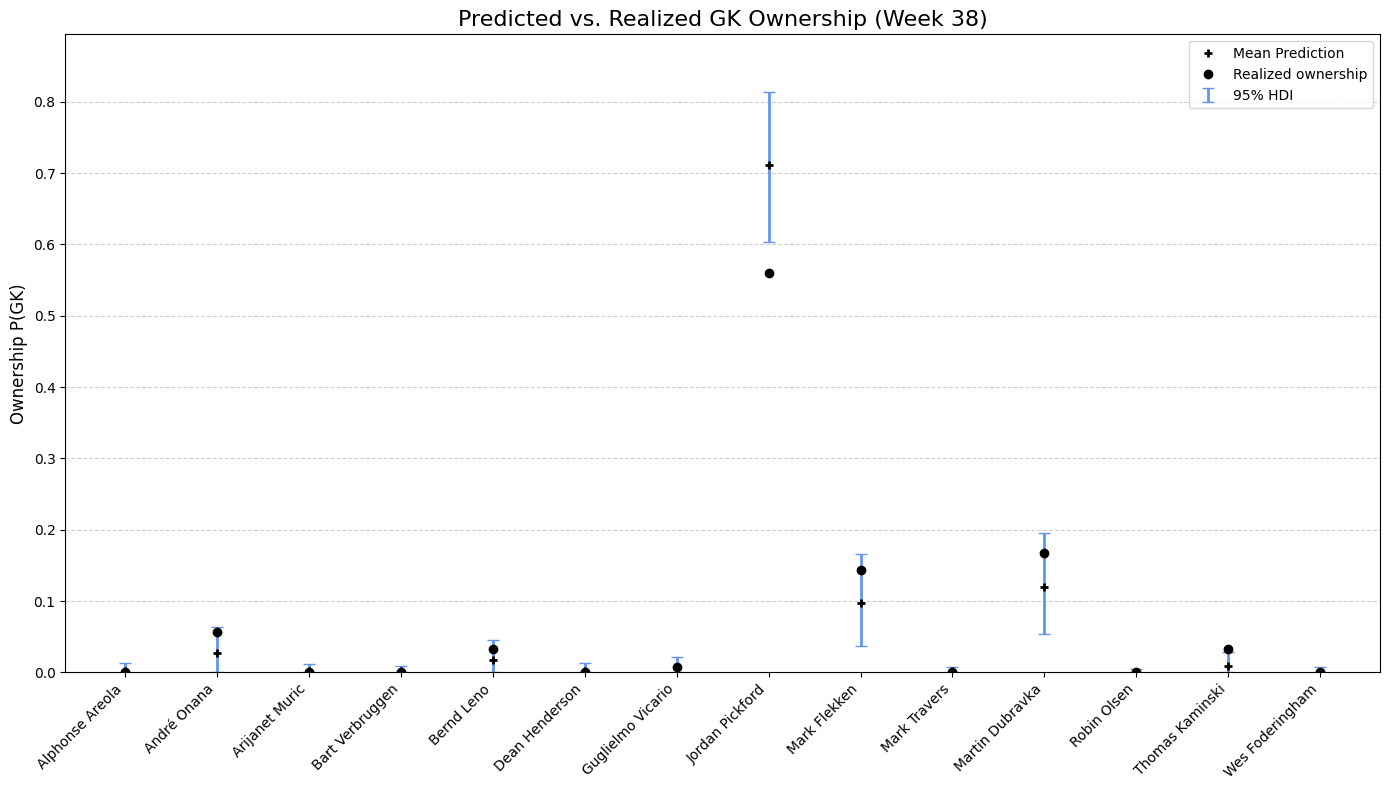

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_gk.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_gk_features = X_pca[0].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_gk[i]

    eta_vector = np.dot(X_gk_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=gk_names,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    gk_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    gk_names,
    gk_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized GK Ownership (Week 38)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(gk_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### DEF


Extracted 12000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_7896\1461560486.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


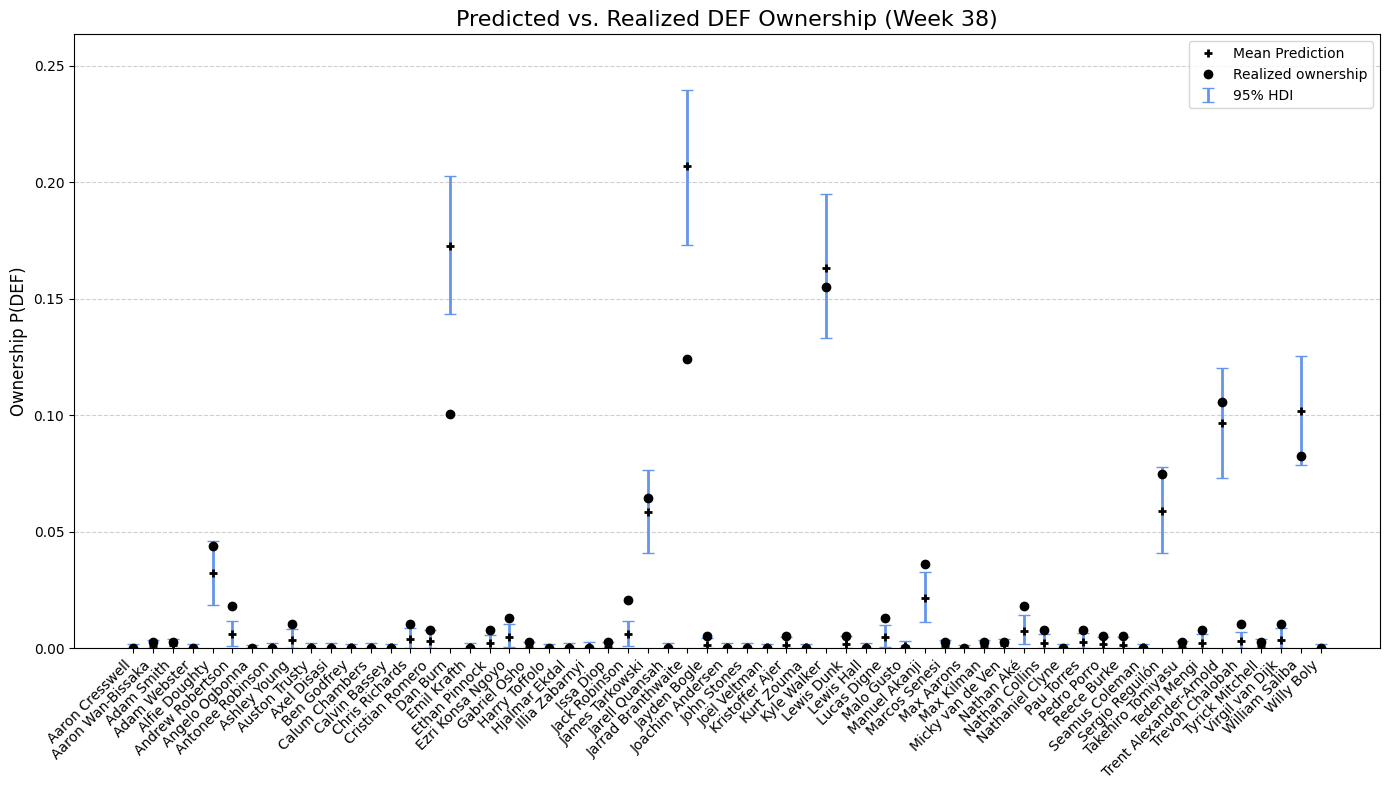

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_def.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_def_features = X_pca[1].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_def[i]

    eta_vector = np.dot(X_def_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))

# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=def_names,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    def_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    def_names,
    def_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized DEF Ownership (Week 38)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(def_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### MID


Extracted 12000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_7896\3562037642.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


(89,) 89


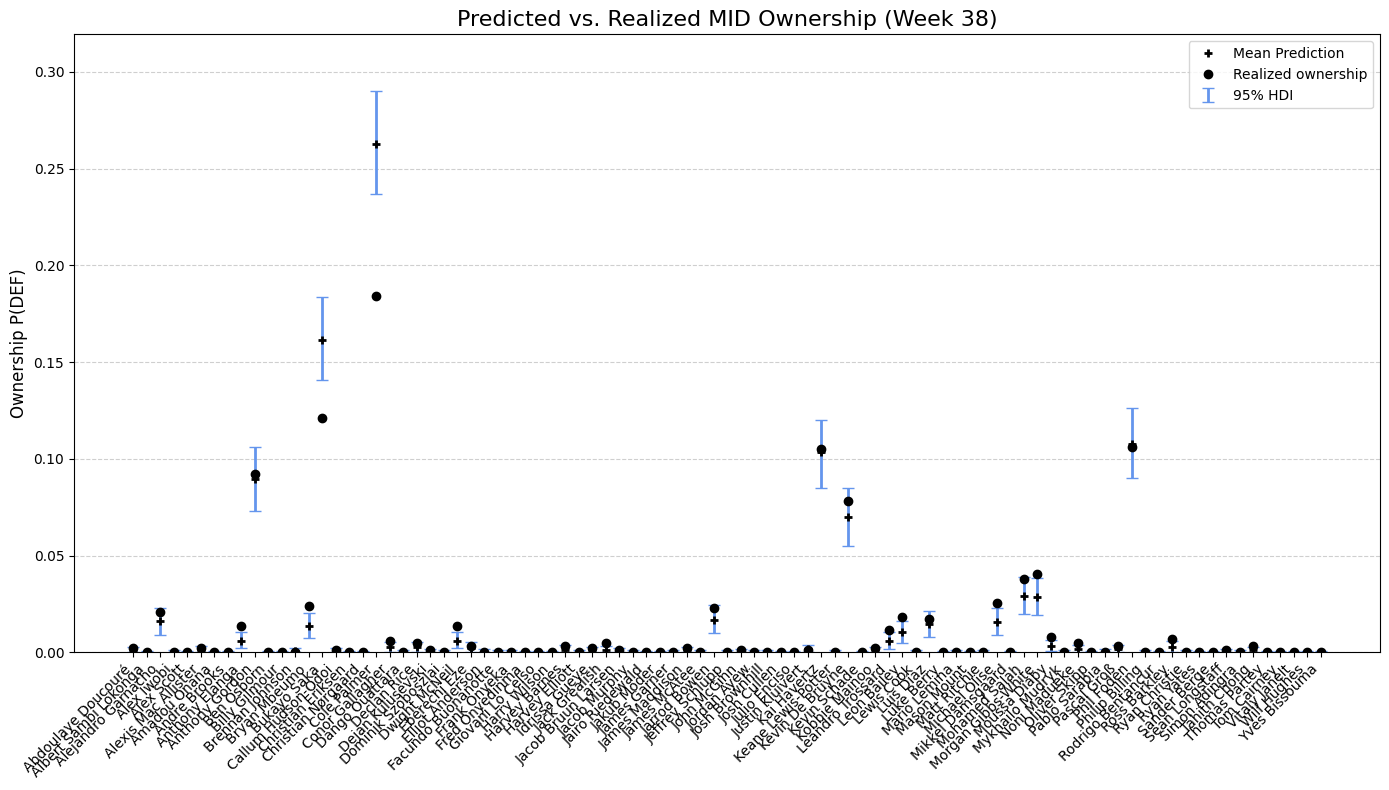

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_mid.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_mid_features = X_pca[2].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_mid[i]

    eta_vector = np.dot(X_mid_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))

print(mid_names.shape, len(hdi_midpoint))

# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=mid_names,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    mid_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    mid_names,
    mid_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized MID Ownership (Week 38)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### FWD


Extracted 12000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_7896\45277678.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


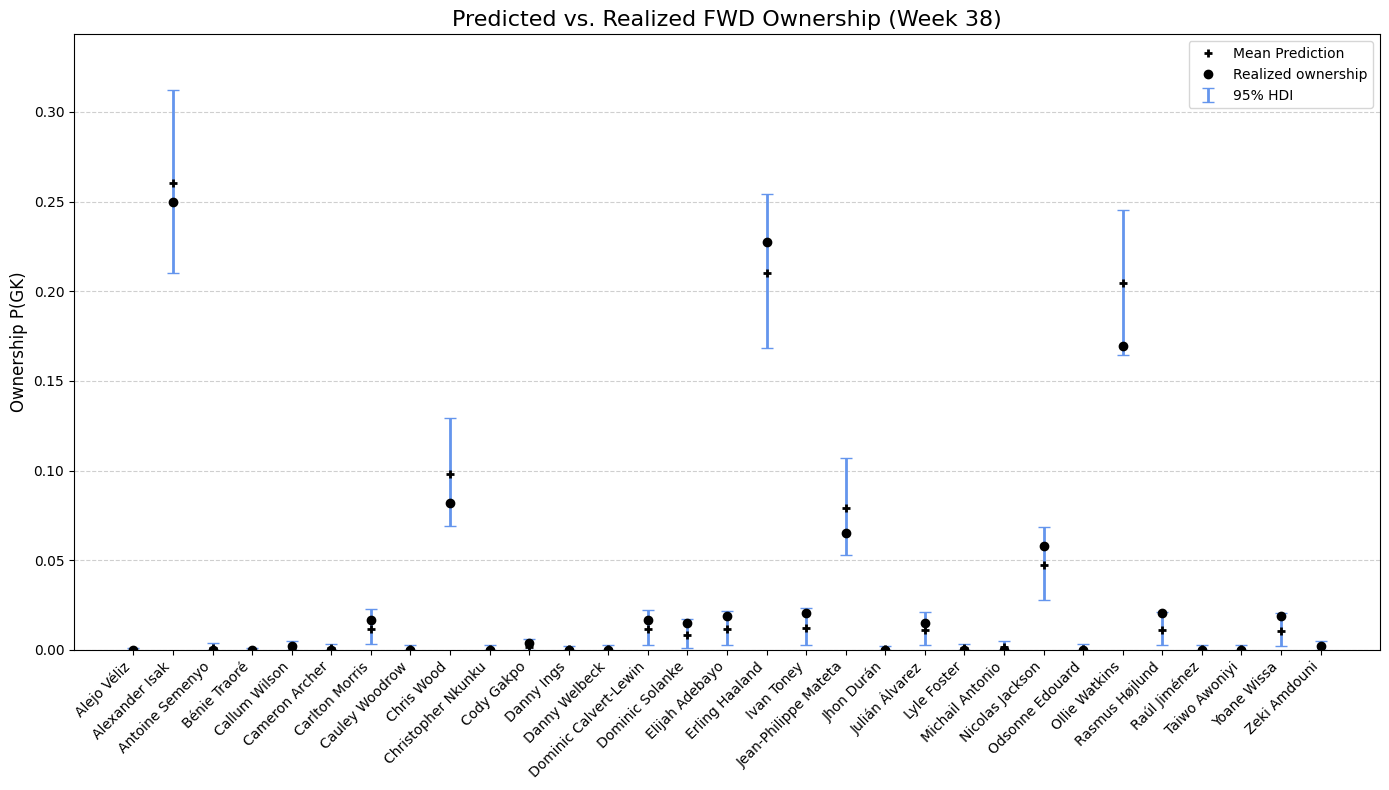

In [ ]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_fwd.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_fwd_features = X_pca[3].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_fwd[i]

    eta_vector = np.dot(X_fwd_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_fwdpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=fwd_names,
    y=hdi_fwdpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    fwd_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    fwd_names,
    fwd_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized FWD Ownership (Week 38)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Generate Portfolios


In [ ]:
generated_portfolios = sample_opponent_portfolios(
    O=200,
    batch_size = 2000,
    beta_estimates=all_beta_estimates,
    feature_matrices=X_pca,
    ids = ids,
    costs=prices,
    budget=100,
    teams=teams,
    xp_preds=xPts,
    p_vectors=p_vectors)


Generating 200 opponent portfolios...
⚙️ Using 4 cores to generate 200 teams...
✅ Collected 0 valid teams after 2000 attempts...: 0
✅ Collected 0 valid teams after 4000 attempts...: 1
✅ Collected 0 valid teams after 6000 attempts...: 2
✅ Collected 0 valid teams after 8000 attempts...: 4
✅ Collected 0 valid teams after 10000 attempts...: 5
✅ Collected 0 valid teams after 12000 attempts...: 5
✅ Collected 0 valid teams after 14000 attempts...: 7
✅ Collected 0 valid teams after 16000 attempts...: 7
✅ Collected 0 valid teams after 18000 attempts...: 8
✅ Collected 0 valid teams after 20000 attempts...: 9
✅ Collected 0 valid teams after 22000 attempts...: 10
✅ Collected 0 valid teams after 24000 attempts...: 12
✅ Collected 0 valid teams after 26000 attempts...: 15
✅ Collected 0 valid teams after 28000 attempts...: 16
✅ Collected 0 valid teams after 30000 attempts...: 16
✅ Collected 0 valid teams after 32000 attempts...: 17
✅ Collected 0 valid teams after 34000 attempts...: 19
✅ Collected 0 v

In [ ]:
Wo_ = []
for i in generated_portfolios:
    # Create a tuple of 0s and 1s for each player
    squad = tuple([1 if id_ in i else 0 for id_ in valid_player_ids])
    Wo_.append(squad)

Output()

Finished [100%]: Average Loss = 17,049
arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
delta[0],4.855,0.021,4.813,4.896,0.001,0.000,970.0,831.0,NaN
delta[1],0.732,0.019,0.700,0.769,0.001,0.000,879.0,942.0,NaN
delta[2],5.839,0.023,5.793,5.878,0.001,0.001,891.0,936.0,NaN
delta[3],5.092,0.020,5.053,5.128,0.001,0.001,761.0,851.0,NaN
delta[4],0.453,0.017,0.420,0.483,0.001,0.000,977.0,1025.0,NaN
...,...,...,...,...,...,...,...,...,...
G_r[195],53.848,0.076,53.708,53.985,0.002,0.002,999.0,1035.0,NaN
G_r[196],47.178,0.078,47.033,47.320,0.003,0.002,853.0,898.0,NaN
G_r[197],46.701,0.078,46.566,46.859,0.003,0.002,778.0,781.0,NaN
G_r[198],47.634,0.077,47.476,47.770,0.003,0.002,704.0,877.0,NaN


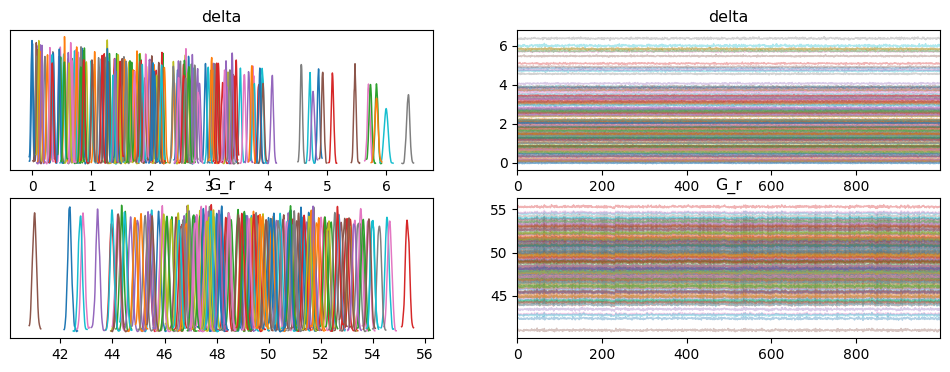

In [ ]:
def make_positive_definite(cov_mat, epsilon=1e-6):
    # Ensure symmetry
    cov_mat = (cov_mat + cov_mat.T) / 2

    # Add jitter to diagonal
    jitter = epsilon * np.eye(cov_mat.shape[0])
    return cov_mat + jitter


def monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta):
    num_player = len(Wo_[0])

    cov_mat = make_positive_definite(cov_mat)

    with pm.Model() as model:
        L = np.linalg.cholesky(make_positive_definite(cov_mat))
        delta = pm.MvNormal("delta", mu=mu_delta, chol=L, shape=num_player)
        # delta = pm.MvNormal("delta", mu=mu_delta, cov=cov_mat, shape=num_player)

        # Compute 90th percentile of performance
        dot_product = pt.dot(Wo_, delta)
        G_r = pm.Deterministic("G_r",  np.percentile(dot_product, 90)) # pt.sort(dot_product)[-int(len(Wo_) * 0.9)])

        approx = pm.fit(method='advi', n=20000)

        trace = approx.sample(1000)
        # trace = pm.sample(
        #     3000,
        #     return_inferencedata=True,
        #     cores=2,
        #     chains=10,
        #     progressbar=True,
        #     target_accept=0.95
        # )

        # G_r_90 = np.percentile(pt.dot(trace.posterior['delta'].values, Wo_), 90)

    return trace
MC_sim_trace = monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta)

az.plot_trace(MC_sim_trace, var_names=["delta", "G_r"])
az.summary(MC_sim_trace, var_names=["delta", "G_r"])

In [ ]:
delta_samples = MC_sim_trace.posterior['delta'].stack(sample=("chain", "draw")).values.T  # shape (N_samples, 226)
G_r_samples   = MC_sim_trace.posterior['G_r'].stack(sample=("chain", "draw")).values.T    # shape (N_samples, 200)

G_r_scalar = np.percentile(G_r_samples, 90, axis=1)  # shape (N_samples,)
print(G_r_scalar.shape, delta_samples.shape)

mu_delta, cov_delta, mu_G, var_G, cov_delta_G, sigma_G = generate_cov_delta(delta_samples, G_r_scalar)


(1000,) (1000, 195)
(1000, 195) (1000,)


In [ ]:
lambdas = np.linspace(0.0, 0.5, 6)
best_lambda, best_w, best_prob = optimize_portfolio(W_constraints, mu_delta, cov_delta, mu_G, var_G, cov_delta_G, lambdas, delta_samples, G_r_scalar, players_preds)
print(f"Best λ: {best_lambda}, Best Probability of Outperforming: {best_prob}")
selected, player_names, total_points = selected_info(best_w, fpl_teams_ids, players_preds, fg_managers_38)
selected, player_names, total_points

195 195
195 195 {'Fulham', 'Brighton and Hove Albion', 'Sheffield United', 'Crystal Palace', 'Newcastle United', 'Nottingham Forest', 'Manchester United', 'Arsenal', 'Manchester City', 'Liverpool', 'Bournemouth', 'Luton', 'Tottenham Hotspur', 'Everton', 'Chelsea', 'West Ham United', 'Burnley', 'Aston Villa', 'Brentford', 'Wolverhampton Wanderers'}
Fulham [22, 30, 39, 77, 83, 164, 182] 7 195
Brighton and Hove Albion [4, 27, 31, 55, 70, 90, 109, 110, 124, 158, 175] 11 195
Sheffield United [15, 25, 29, 35, 86, 98, 188] 7 195
Crystal Palace [43, 56, 63, 89, 99, 100, 102, 105, 141, 151, 154, 185, 189] 13 195
Newcastle United [10, 20, 37, 52, 65, 66, 78, 88, 125, 136, 138, 173] 12 195
Nottingham Forest [19, 32, 36, 44, 76, 146, 170, 177, 191] 9 195
Manchester United [1, 6, 17, 45, 117, 137, 163, 174] 8 195
Arsenal [34, 57, 113, 121, 178, 181, 190] 7 195
Manchester City [49, 67, 85, 93, 104, 111, 115, 120, 131, 149, 161] 11 195
Liverpool [11, 16, 48, 61, 79, 95, 127, 145, 183, 186] 10 195
Bou

([19, 20, 60, 263, 308, 313, 343, 353, 355, 362, 369],
 ['Bukayo Saka',
  'William Saliba',
  'Ollie Watkins',
  'Jordan Pickford',
  'Mohamed Salah',
  'Virgil van Dijk',
  'Julián Álvarez',
  'Phil Foden',
  'Erling Haaland',
  'Cole Palmer',
  'Kyle Walker'],
 102.0)

In [ ]:
selected, player_names, total_points = selected_info(best_w, fpl_teams_ids, players_preds, fg_managers_38)
selected, player_names, total_points

[15.  8. 42.  3.  5.  2. 13.  2.  5.  1.  6.] ---------> [8.42857821 5.75904691 9.66969921 2.348      2.83085205 5.88199999
 4.82644648 2.12951213 3.48122268 1.42490824 5.19414667]
Your predicted player’s total of 102.0 points would rank:
→ Position: 9 out of 256 managers
→ Percentile: Top 96.48%

Closest scores around you:
   points     prize
0   104.0  R 199.50
1   104.0  R 199.50
2   102.0   R 99.75
3   102.0   R 99.75
4   100.5   R 20.32


([19, 20, 60, 263, 308, 313, 343, 353, 355, 362, 369],
 ['Bukayo Saka',
  'William Saliba',
  'Ollie Watkins',
  'Jordan Pickford',
  'Mohamed Salah',
  'Virgil van Dijk',
  'Julián Álvarez',
  'Phil Foden',
  'Erling Haaland',
  'Cole Palmer',
  'Kyle Walker'],
 102.0)